# Task 2 — Season Classification

**Status:** execution in progress. The protocol and notebook story are fixed; G0, B0, B1, G1, G2-P, G2-A, and G2-T now have measured, hash-linked evidence.

**How to finish this notebook:** implement reusable logic under `src/fashion/`; fill each code cell; run it; keep its output; then replace the prompt text after the bold Interpretation marker with a short evidence-based finding.

**Structural rule:** every leaf `###` subsection owns exactly one code cell. A broader `###` owns no direct code cell; divide it into `####` subsubsections, with one code cell per `####` leaf.

**Frozen boundaries:** teacher images only; `data/processed/splits.csv` is the only split; all submitted models are trained from scratch; all runs go through `fashion.train.registry` to `results/runs.csv`; holdout remains sealed until Notebook 06.

**Core risks:** weak-visual-signal labels, article-type shortcut learning, class imbalance, acquisition artifacts, and calibration failure.

**Primary development metric:** pooled out-of-fold macro-F1 over `Fall`, `Spring`, `Summer`, and `Winter`.

## 1. Task contract and reproducibility

Freeze the decision, labels, paths, seed, and execution environment before any result is viewed.

### 1.1 Frozen task configuration

This cell creates the single configuration object used by every later cell.

In [1]:
import hashlib
import json

import pandas as pd
from IPython.display import display

from fashion.config import (
    CV_FOLD_SUMMARY_JSON,
    RANDOM_SEED,
    ROOT,
    TASK2_CHECKPOINT_DIR,
    TASK2_EVIDENCE_DIR,
    TASK2_FIGURE_DIR,
    TASK2_MODEL_PATH,
    TASK2_SELECTION_FREEZE_JSON,
)
from fashion.data.dataset import load_label_maps

TASK2_TARGET = "season"
SEASON_MASK = "has_season_label"
SEASON_LABELS = tuple(load_label_maps()[TASK2_TARGET]["classes"])
assert SEASON_LABELS == ("Fall", "Spring", "Summer", "Winter")

with CV_FOLD_SUMMARY_JSON.open(encoding="utf-8") as handle:
    cv_summary = json.load(handle)
for directory in (TASK2_EVIDENCE_DIR, TASK2_FIGURE_DIR, TASK2_CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

task_contract = pd.DataFrame(
    [{
        "target": TASK2_TARGET,
        "labels": " | ".join(SEASON_LABELS),
        "seed": RANDOM_SEED,
        "cv_folds": cv_summary["fold_count"],
        "cv_assignment_sha256": cv_summary["cv_assignment_sha256"],
        "evidence_directory": TASK2_EVIDENCE_DIR.relative_to(ROOT).as_posix(),
        "figure_directory": TASK2_FIGURE_DIR.relative_to(ROOT).as_posix(),
        "checkpoint_directory": TASK2_CHECKPOINT_DIR.relative_to(ROOT).as_posix(),
        "freeze_manifest": TASK2_SELECTION_FREEZE_JSON.relative_to(ROOT).as_posix(),
        "final_model": TASK2_MODEL_PATH.relative_to(ROOT).as_posix(),
    }]
)
assert task_contract.loc[0, "cv_folds"] == 5
display(task_contract)

,target,labels,seed,cv_folds,cv_assignment_sha256,evidence_directory,figure_directory,checkpoint_directory,freeze_manifest,final_model
0,season,Fall | Spring | Summer | Winter,2753,5,bad7bc4ae65fbbfd815567f4ccfa308d6e57dc650bc15c...,results/evidence/task2,results/figures/task2,tmp/task2/checkpoints,results/evidence/task2/selection_freeze.json,models/task2_season.pt


> **Interpretation to write after running:** Confirm that the output matches the assignment contract. Explain that inference is image-only and that the official CSV must always contain one Season label.

### 1.2 Environment and deterministic execution

Package versions, hardware, and random state must be recorded so runs can be reproduced.

In [2]:
from pathlib import Path

from fashion.train.artifacts import atomic_write_json
from fashion.train.reproducibility import (
    capture_git_state,
    capture_runtime,
    seed_everything,
)

seed_everything(RANDOM_SEED, deterministic=True)
runtime = capture_runtime()
runtime["executable_name"] = Path(runtime.pop("executable")).name
environment_record = {
    "schema_version": "1.0.0",
    "seed": RANDOM_SEED,
    "deterministic_algorithms": True,
    "mixed_precision_policy": "torch.amp on CUDA; disabled on CPU",
    "git": capture_git_state(),
    "runtime": runtime,
}
environment_path = TASK2_EVIDENCE_DIR / "environment.json"
atomic_write_json(environment_path, environment_record)
environment_table = (
    pd.json_normalize(environment_record, sep=".")
    .transpose()
    .rename_axis("field")
    .reset_index()
    .rename(columns={0: "value"})
)
display(environment_table)

,field,value
0,schema_version,1.0.0
1,seed,2753
2,deterministic_algorithms,True
3,mixed_precision_policy,torch.amp on CUDA; disabled on CPU
4,git.commit,2a3353192cb43adbecfec4118bb858bacd9c558b
5,git.dirty,False
6,runtime.python,3.12.13
7,runtime.python_implementation,CPython
8,runtime.platform,Windows-11-10.0.26200-SP0
9,runtime.processor,"Intel64 Family 6 Model 183 Stepping 1, Genuine..."


> **Interpretation to write after running:** State the actual machine and software used. Note any deterministic-operation limitation rather than hiding it.

### 1.3 How Task 2 files affect one another

This map separates inputs that create a model from evidence that only explains it. The direction of every arrow is part of the leakage and deployment contract.

#### 1.3.1 Declare and audit the impact edges

In [3]:
from fashion.task2.evidence import (
    build_file_impact_edges,
    validate_file_impact_edges,
)

file_impact_edges = build_file_impact_edges()
validate_file_impact_edges(file_impact_edges)
file_impact_edges

,producer,artifact,consumer,effect,phase
0,data/processed/splits.csv,canonical partitions and cv_fold,fashion.data.torch,Changing membership or folds invalidates every...,inputs
1,data/processed/label_maps.json,"Fall, Spring, Summer, Winter class order",fashion.data.torch,"Changing class indices invalidates models, met...",inputs
2,fashion.data.torch,fold-fitted tensors and loaders,Task 2 runner,Transform changes create a new implementation ...,training
3,configs/task2/*.json,immutable experiment choices,Task 2 runner,A changed scientific choice creates a new conf...,training
4,fashion.models.season,scratch logits and feature maps,Task 2 runner,Architecture changes invalidate checkpoints an...,training
5,fashion.train.engine,"best checkpoint, OOF predictions, and history",Task 2 runner,Optimisation changes invalidate the implementa...,training
6,Task 2 runner,run lifecycle and provenance row,results/runs.csv,"Every physical run is retained as completed, f...",artifacts
7,Task 2 runner,"checkpoint, OOF, and history files",tmp/task2 artifacts,Bytes are reused only when their declared SHA-...,artifacts
8,results/runs.csv,"run IDs, hashes, metrics, and status",results/evidence/task2,Registry changes rebuild evidence but do not a...,evidence
9,tmp/task2 artifacts,verified OOF and histories,results/evidence/task2,Only hash-verified outputs may support a measu...,evidence


> **Interpretation:** **Result —** the audited table declares every producer, artifact, consumer, and effect used by Task 2. **Meaning —** canonical data and source code can change training; a config change creates a new experiment identity; evidence can describe a trained model but cannot modify it. **Decision —** trace every report claim back to a registered run ID, and let holdout, prediction, and app code consume only the frozen bundle. **Limitation —** this table verifies the declared dependency contract, not model quality. **Trace —** `results/evidence/task2/file_impact_edges.csv` and its SHA-256 manifest.

#### 1.3.2 Render the file-impact flow

findfont: Failed to find font weight semibold, now using 700.


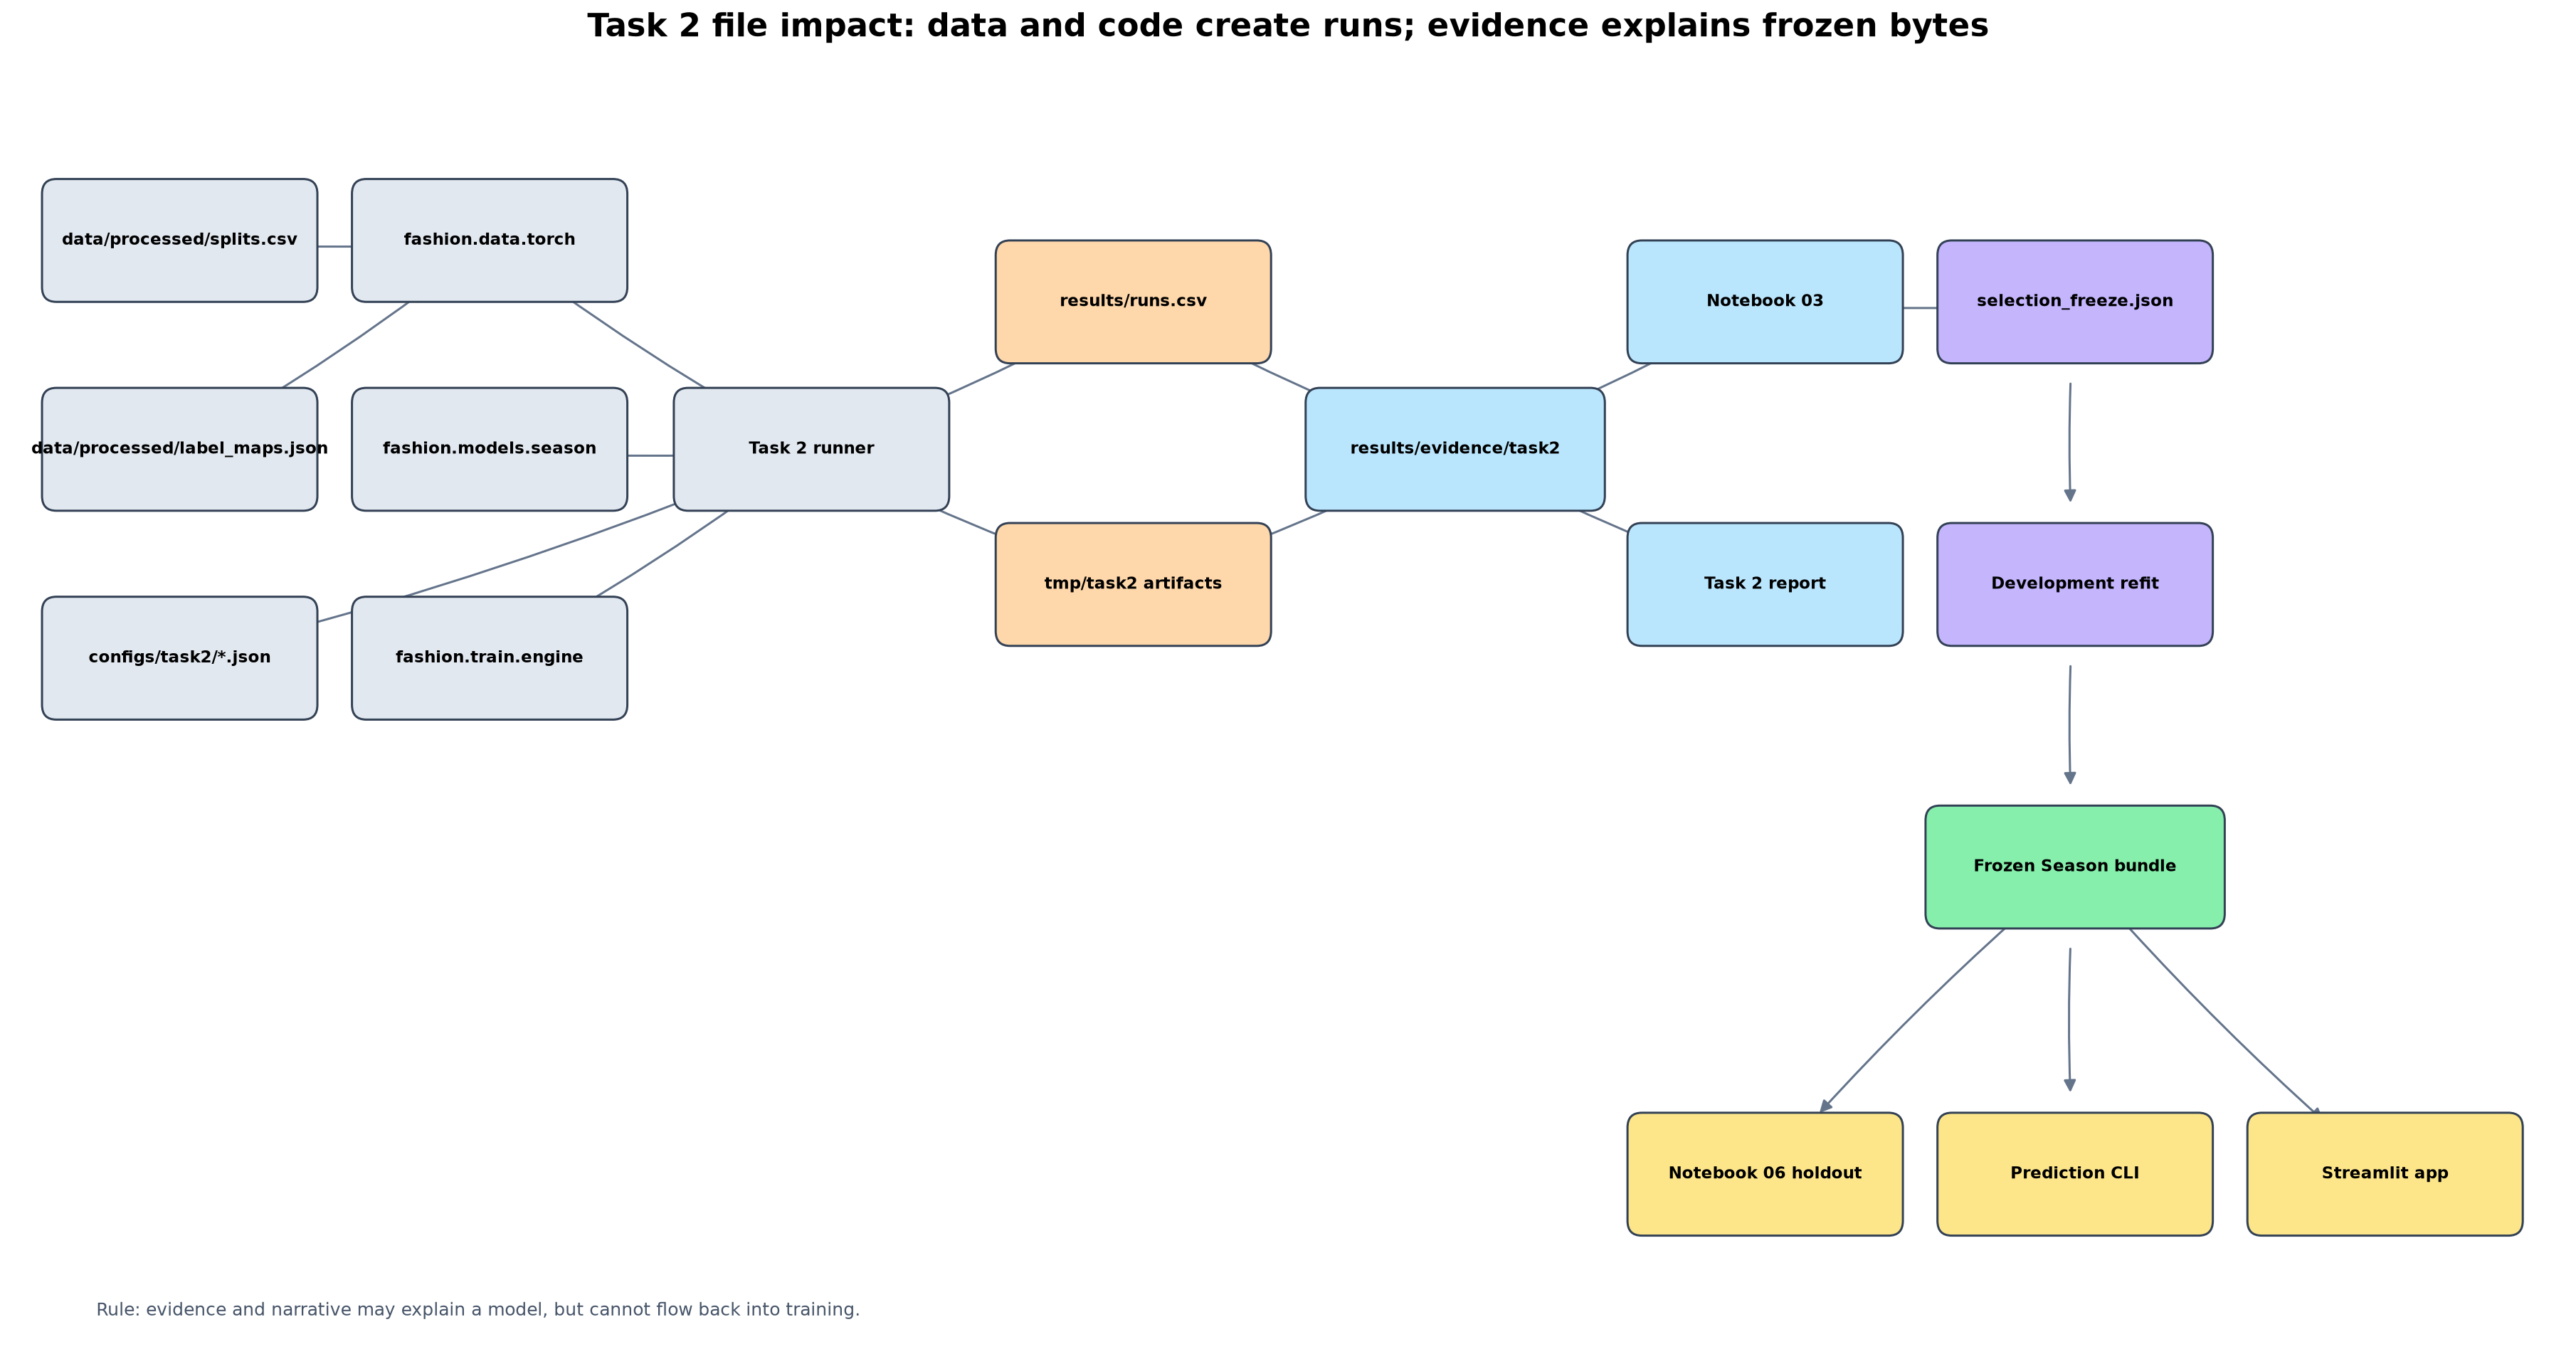

{'schema_version': '1.0.0',
 'scope': 'task2_file_impact',
 'edge_count': 18,
 'node_count': 18,
 'edges_path': 'results/evidence/task2/file_impact_edges.csv',
 'edges_sha256': '02c3e15f9cd0ec0e0c8710fb0994a61d060ccf73ed1865b36d3ba595aa23fe87',
 'figure_path': 'results/figures/task2/file_impact_flow.png',
 'figure_sha256': 'cd234563ef08e18dd60bb982078c3f76581805d755673cb010004a84c6b65dcb',
 'holdout_to_training_edges': 0,
 'deployment_input': 'Frozen Season bundle',
 'manifest_path': 'C:\\Users\\Khoai\\RMIT\\Machine_Learning\\Machine Learning at RMIT\\MLA2\\results\\evidence\\task2\\file_impact_manifest.json',
 'manifest_sha256': 'f0841ca00b5d7f333e7992dc08f81497a42df64193f2c3120a275217046e1fc9'}

In [4]:
from IPython.display import Image, display

from fashion.config import ROOT
from fashion.task2.evidence import build_task2_evidence

file_impact_manifest = build_task2_evidence()
display(Image(filename=str(ROOT / file_impact_manifest["figure_path"])))
file_impact_manifest

> **Interpretation:** **Result —** the PNG makes the one-way Task 2 lifecycle visible in Jupyter and exported HTML. **Meaning —** the selection freeze comes before development refit, while Notebook 06, the prediction CLI, and the app all read the same frozen bytes and manifest. **Decision —** use this flow when checking whether a future edit invalidates training, evidence only, or deployment. **Limitation —** arrows show allowed file impact, not runtime order or measured performance. **Trace —** `results/figures/task2/file_impact_flow.png` with its SHA-256 recorded in `file_impact_manifest.json`.

## 2. Data and EDA handoff

Reproduce only the Task 2 facts needed from Notebook 01. These are data facts, not model results.

### 2.1 Load the development task frame

Task 2 uses teacher images and excludes only rows with a truly blank Season label.

In [5]:
from fashion.data.dataset import get_samples, load_splits

splits = load_splits()
development = get_samples(splits, partition="development")
season_development = get_samples(development, target=TASK2_TARGET).reset_index(drop=True)
protected = splits["partition"].isin(["holdout", "quarantine"])
visible_protected_labels = splits.loc[protected, TASK2_TARGET].astype(str).str.strip().ne("").sum()
visible_protected_masks = splits.loc[protected, SEASON_MASK].astype(bool).sum()

assert len(development) == 32_773
assert len(season_development) == 32_753
assert len(development) - len(season_development) == 20
assert not season_development["partition"].isin(["holdout", "quarantine"]).any()
assert visible_protected_labels == visible_protected_masks == 0

task2_data_audit = pd.DataFrame(
    [
        {"check": "development rows", "value": len(development)},
        {"check": "valid Season rows", "value": len(season_development)},
        {"check": "masked Season rows", "value": len(development) - len(season_development)},
        {"check": "visible protected Season labels", "value": int(visible_protected_labels)},
        {"check": "protected rows in modelling frame", "value": 0},
    ]
)
display(task2_data_audit)

,check,value
0,development rows,32773
1,valid Season rows,32753
2,masked Season rows,20
3,visible protected Season labels,0
4,protected rows in modelling frame,0


> **Interpretation:** The Task 2 handoff exactly reproduces Notebook 01: 32,773 development rows, 32,753 valid Season labels, and 20 masked labels. No holdout or quarantine label is visible, and no protected row enters the modelling frame. This confirms that the earlier EDA counts were accurate and freezes one comparable population for every later baseline, model, and ablation.

### 2.2 Audit class balance, folds, and EDA evidence

This topic needs separate numeric and visual evidence, so it is divided into two subsubsections.

#### 2.2.1 Reproduce class and fold statistics

The numeric audit checks the exact EDA facts that drive imbalance and validation choices.

In [6]:
from fashion.train.artifacts import atomic_write_csv

season_counts = season_development[TASK2_TARGET].value_counts().reindex(SEASON_LABELS)
expected_counts = pd.Series(
    {"Fall": 8_928, "Spring": 1_329, "Summer": 16_235, "Winter": 6_261}
)
pd.testing.assert_series_equal(season_counts, expected_counts, check_names=False)
fold_support = (
    pd.crosstab(season_development[TASK2_TARGET], season_development["cv_fold"])
    .reindex(index=SEASON_LABELS, columns=range(5), fill_value=0)
)
assert fold_support.gt(0).all().all()
imbalance_ratio = float(season_counts.max() / season_counts.min())
eda_handoff = pd.DataFrame(
    {
        "class": SEASON_LABELS,
        "development_products": season_counts.to_numpy(),
        "share_percent": (season_counts / season_counts.sum() * 100).to_numpy(),
        **{f"fold_{fold}_validation_products": fold_support[fold].to_numpy() for fold in range(5)},
    }
)
eda_handoff["largest_to_smallest_ratio"] = imbalance_ratio
atomic_write_csv(TASK2_EVIDENCE_DIR / "eda_handoff.csv", eda_handoff)
display(
    eda_handoff.style.format(
        {"share_percent": "{:.2f}", "largest_to_smallest_ratio": "{:.2f}"}
    )
)

,class,development_products,share_percent,fold_0_validation_products,fold_1_validation_products,fold_2_validation_products,fold_3_validation_products,fold_4_validation_products,largest_to_smallest_ratio
0,Fall,8928,27.26,1786,1786,1786,1785,1785,12.22
1,Spring,1329,4.06,266,265,265,267,266,12.22
2,Summer,16235,49.57,3246,3247,3246,3248,3248,12.22
3,Winter,6261,19.12,1252,1253,1253,1250,1253,12.22


> **Interpretation:** Summer contains 16,235 products (49.57%) while Spring contains 1,329 (4.06%), a 12.22:1 ratio; every fold still contains all four labels. The EDA hypothesis entering modelling is therefore explicit: accuracy can look reasonable when a model mostly predicts Summer, while pooled macro-F1 must expose failure on Spring. Section 5.1 tests this claim with B0 before any image model is accepted.

#### 2.2.2 Display the saved shortcut and transform evidence

The visual handoff keeps Notebook 03 tied to the acquisition, compression, shortcut, and transform risks found in Notebook 01.

'acquisition shortcut'

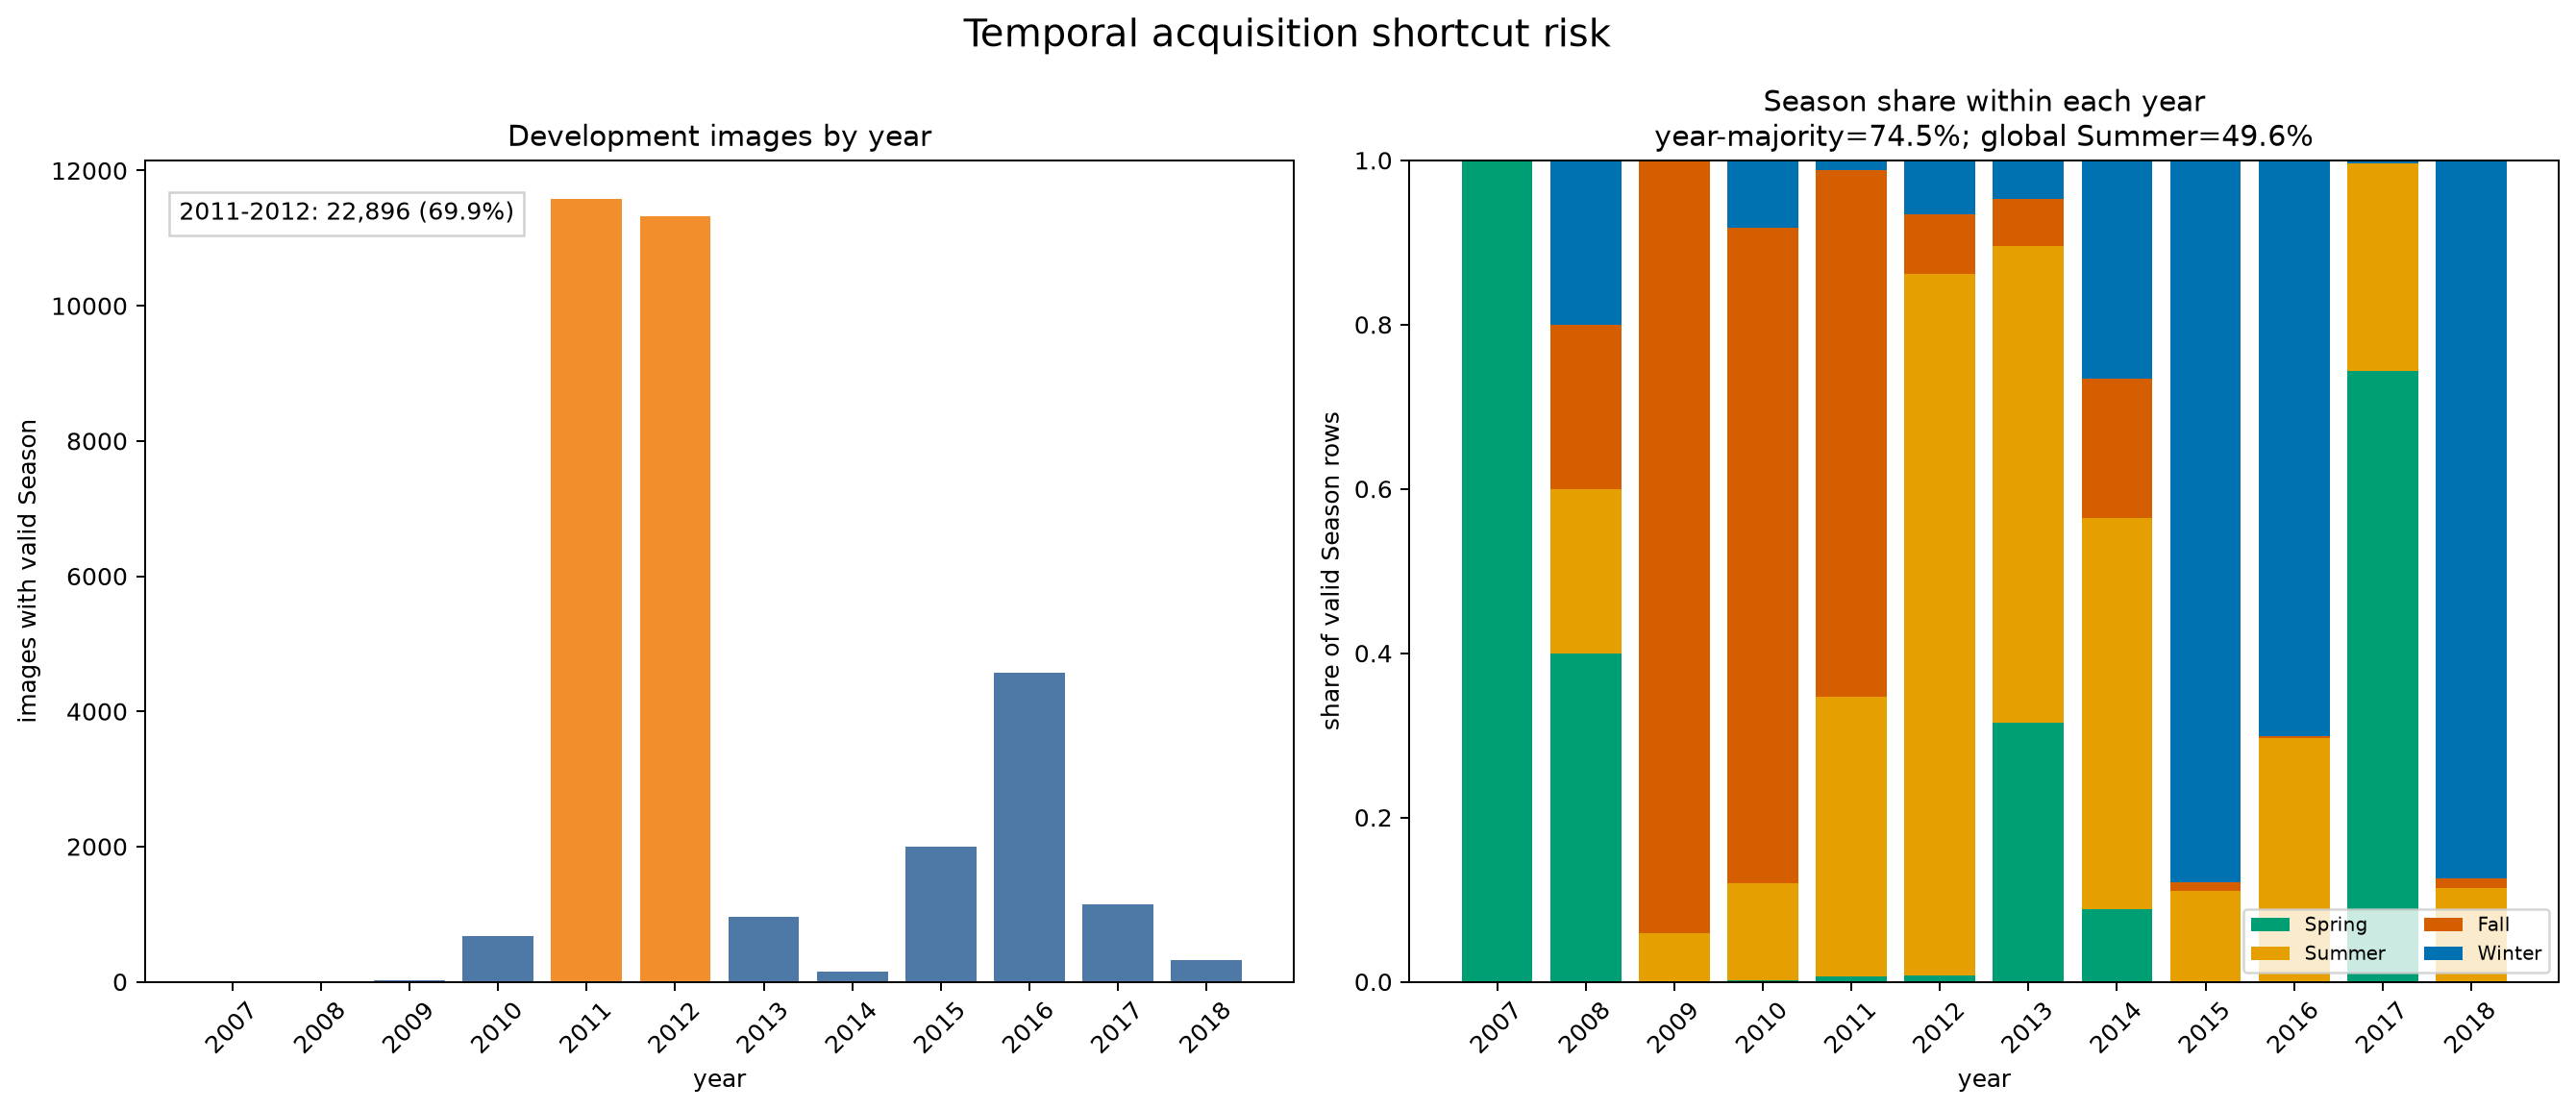

'file-size shortcut'

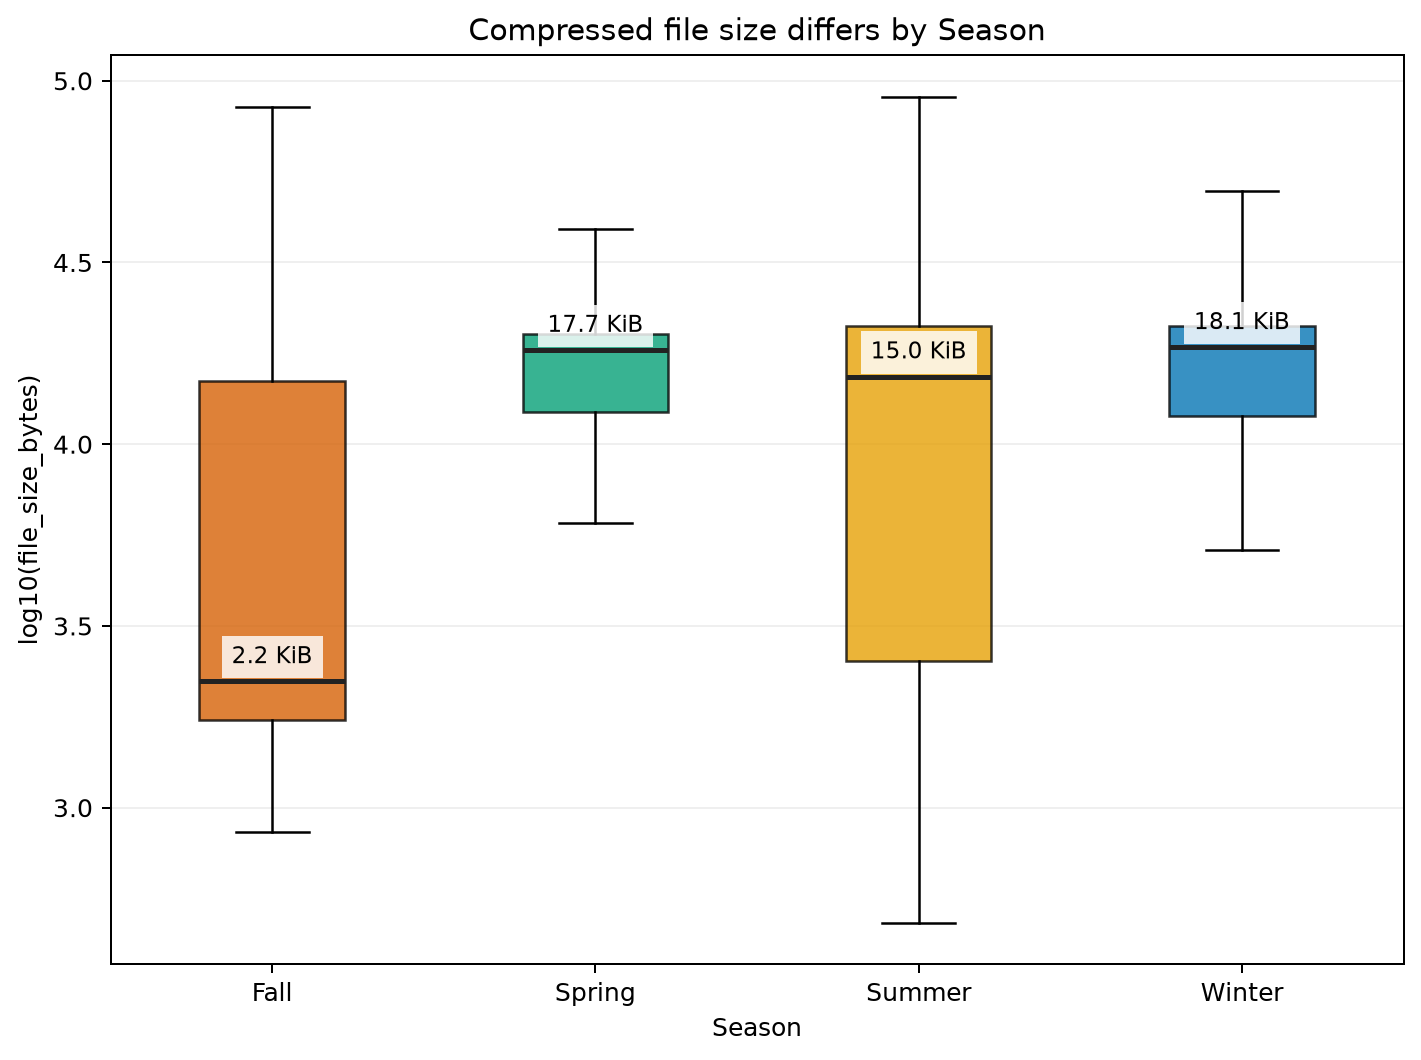

'ArticleType shortcut'

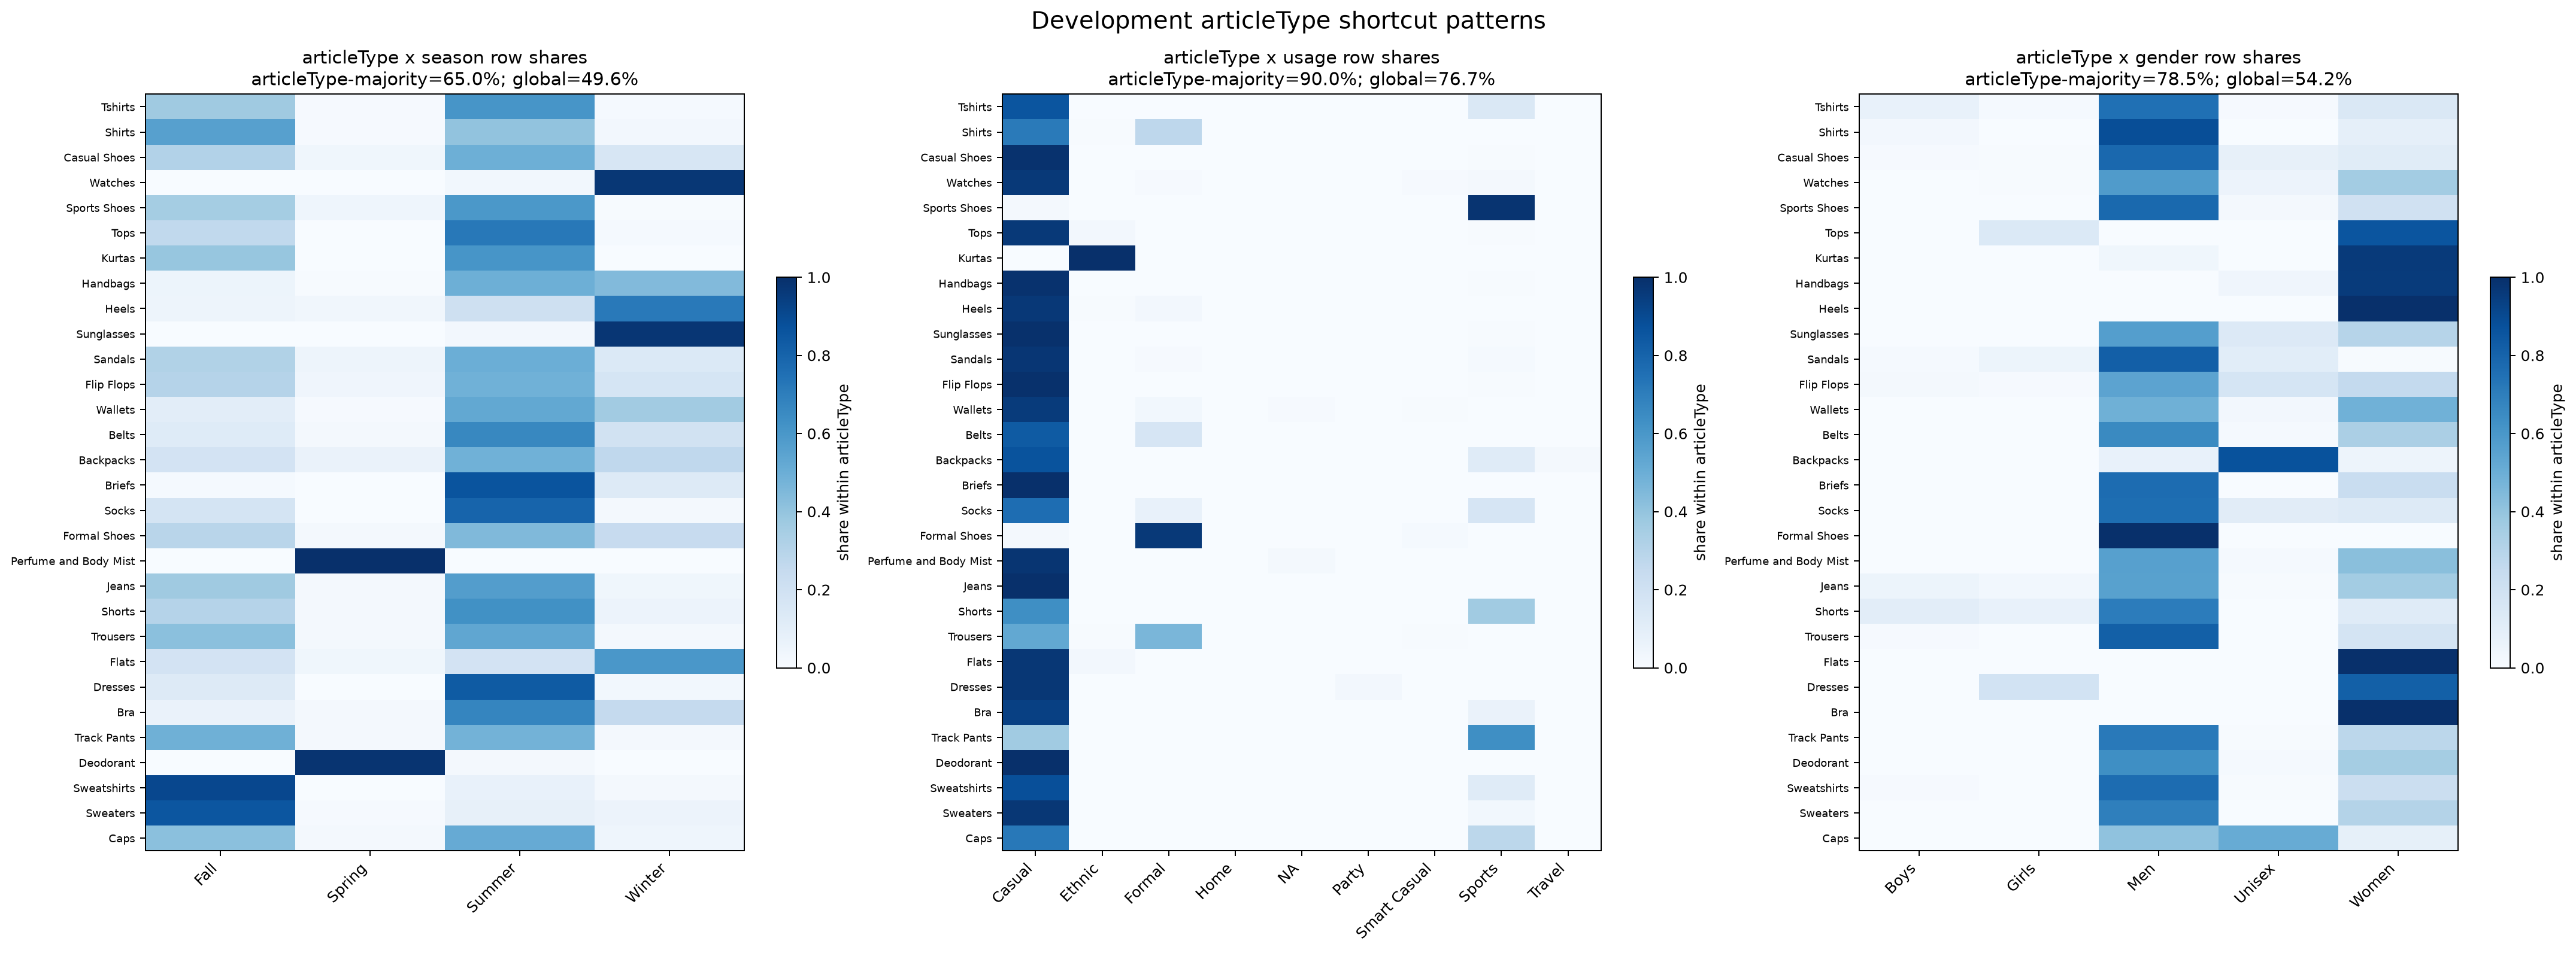

'transform risk'

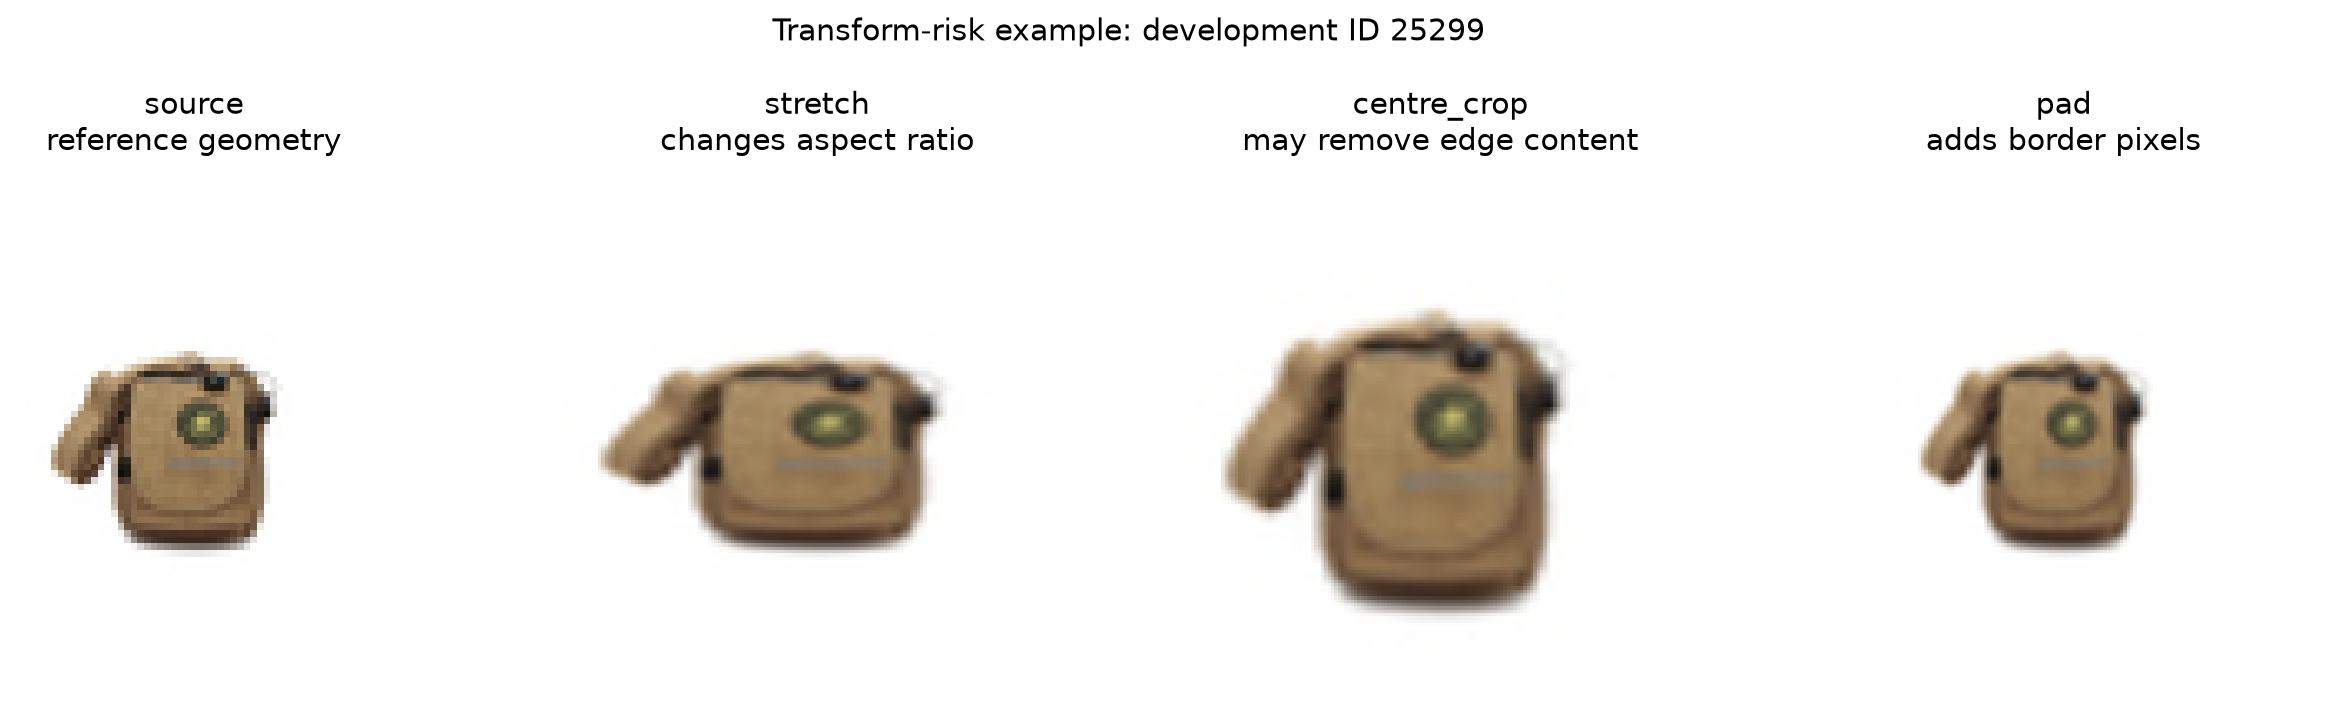

,evidence,path,sha256,claim_boundary
0,acquisition shortcut,results/figures/data_preparation/acquisition_s...,6275b416101b809abddf465c40fbb7ad7cb5eaa13f8061...,development-only description; not model accura...
1,file-size shortcut,results/figures/data_preparation/season_file_s...,c45e6763d560b62d430ac40b11255e4908ce01105f2c4c...,development-only description; not model accura...
2,ArticleType shortcut,results/figures/data_preparation/shortcut_risk...,ec200dc8cd94257a747528628fc49bf498a7c6b50282e3...,development-only description; not model accura...
3,transform risk,results/figures/data_preparation/transform_ris...,c5b984b59a846558ef0549381116a52658046d8c763000...,development-only description; not model accura...


In [7]:
from IPython.display import Image, display

from fashion.config import DATA_PREPARATION_FIGURE_DIR
from fashion.data.hashing import compute_sha256

eda_figure_paths = {
    "acquisition shortcut": DATA_PREPARATION_FIGURE_DIR / "acquisition_shortcut_risk.png",
    "file-size shortcut": DATA_PREPARATION_FIGURE_DIR / "season_file_size_shortcut.png",
    "ArticleType shortcut": DATA_PREPARATION_FIGURE_DIR / "shortcut_risk_heatmaps.png",
    "transform risk": DATA_PREPARATION_FIGURE_DIR / "transform_risk.png",
}
eda_figure_registry = pd.DataFrame(
    [
        {
            "evidence": name,
            "path": path.relative_to(ROOT).as_posix(),
            "sha256": compute_sha256(path),
            "claim_boundary": "development-only description; not model accuracy or causality",
        }
        for name, path in eda_figure_paths.items()
        if path.is_file()
    ]
)
assert len(eda_figure_registry) == len(eda_figure_paths)
atomic_write_csv(TASK2_EVIDENCE_DIR / "eda_figure_registry.csv", eda_figure_registry)
for name, path in eda_figure_paths.items():
    display(name, Image(filename=str(path)))
display(eda_figure_registry)

> **Interpretation:** The earlier EDA provides hypotheses, not model scores. Shape and colour patterns justify B1; transform risk justifies aspect-preserving padding plus controlled P0/P1 and A0/A1 tests; ArticleType, file size, and acquisition year are possible shortcuts that must later be tested on OOF predictions. The figures remain development-only descriptions and do not prove accuracy or causality. Section 8.2.3 records which early insights were supported, contradicted, or still untested after the first measured gates.

## 3. Development-validation protocol

Use all five canonical folds and create one out-of-fold prediction per valid product.

### 3.1 Build the five canonical fold views

Every candidate must see exactly the same training and validation rows.

In [8]:
from fashion.data.dataset import iter_cv_folds

fold_frames = {}
fold_rows = []
for fold, training_all, validation_all in iter_cv_folds(splits):
    training = get_samples(training_all, target=TASK2_TARGET).reset_index(drop=True)
    validation = get_samples(validation_all, target=TASK2_TARGET).reset_index(drop=True)
    family_overlap = set(training["product_family_group"]) & set(validation["product_family_group"])
    assert not family_overlap
    assert set(training[TASK2_TARGET]) == set(validation[TASK2_TARGET]) == set(SEASON_LABELS)
    fold_frames[fold] = {"training": training, "validation": validation}
    fold_rows.append(
        {
            "validation_fold": fold,
            "training_products": len(training),
            "validation_products": len(validation),
            "training_families": training["product_family_group"].nunique(),
            "validation_families": validation["product_family_group"].nunique(),
            "training_classes": training[TASK2_TARGET].nunique(),
            "validation_classes": validation[TASK2_TARGET].nunique(),
            "family_crossings": len(family_overlap),
        }
    )
fold_handoff = pd.DataFrame(fold_rows)
assert len(fold_handoff) == 5
assert fold_handoff["validation_products"].sum() == len(season_development)
atomic_write_csv(TASK2_EVIDENCE_DIR / "fold_handoff.csv", fold_handoff)
display(fold_handoff)

,validation_fold,training_products,validation_products,training_families,validation_families,training_classes,validation_classes,family_crossings
0,0,26203,6550,18324,4561,4,4,0
1,1,26202,6551,18297,4588,4,4,0
2,2,26203,6550,18311,4574,4,4,0
3,3,26203,6550,18288,4597,4,4,0
4,4,26201,6552,18320,4565,4,4,0


> **Interpretation to write after running:** State that all-five-fold CV was chosen for stable comparison and that no best-looking fold will be selected.

### 3.2 Freeze the OOF coverage contract

Pooled evidence is valid only when each product is predicted outside its training data exactly once.

In [9]:
from fashion.train.artifacts import canonical_sha256

expected_oof_index = season_development[
    ["id", "cv_fold", TASK2_TARGET, "product_family_group"]
].copy()
protected_ids = set(splits.loc[protected, "id"].astype(int))
assert expected_oof_index["id"].is_unique
assert not (set(expected_oof_index["id"].astype(int)) & protected_ids)
assert set(expected_oof_index[TASK2_TARGET]) == set(SEASON_LABELS)

oof_probability_columns = [f"prob_{label}" for label in SEASON_LABELS]
oof_contract = {
    "schema_version": "1.0.0",
    "expected_row_count": len(expected_oof_index),
    "expected_unique_ids": len(expected_oof_index),
    "expected_id_sha256": canonical_sha256(sorted(expected_oof_index["id"].astype(int))),
    "required_columns": ["id", "fold", "y_true", "y_pred", *oof_probability_columns],
    "labels": list(SEASON_LABELS),
    "probability_rule": "finite values in [0,1], four columns present, each row sums to one",
    "coverage_rule": (
        "each valid development ID appears exactly once; "
        "protected IDs appear zero times"
    ),
    "validator": "fashion.train.metrics.validate_oof",
}
atomic_write_json(TASK2_EVIDENCE_DIR / "oof_contract.json", oof_contract)
display(pd.Series(oof_contract, name="OOF contract").to_frame())

,OOF contract
schema_version,1.0.0
expected_row_count,32753
expected_unique_ids,32753
expected_id_sha256,6f8540aff2511b2d63e23bea6d5aad24060cbbf3f352d4...
required_columns,"[id, fold, y_true, y_pred, prob_Fall, prob_Spr..."
labels,"[Fall, Spring, Summer, Winter]"
probability_rule,"finite values in [0,1], four columns present, ..."
coverage_rule,each valid development ID appears exactly once...
validator,fashion.train.metrics.validate_oof


> **Interpretation to write after running:** Explain why pooled OOF predictions are the fair unit for model comparison.

### 3.3 Freeze metrics and selection rules

Metrics must be declared before candidate results are visible.

In [10]:
metric_contract = {
    "schema_version": "1.0.0",
    "primary_metric": "pooled five-fold OOF macro-F1",
    "labels": list(SEASON_LABELS),
    "zero_division": 0,
    "secondary_metrics": [
        "fold macro-F1 mean and standard deviation",
        "per-class precision, recall, F1, and support",
        "balanced accuracy and accuracy",
        "count and row-normalised confusion matrices",
        "NLL, multiclass Brier score, ECE, and risk-coverage",
        "model size, parameter count, latency, RAM, and VRAM",
    ],
    "uncertainty": "10,000 paired bootstrap samples grouped by product_family_group",
    "near_tie_macro_f1_points": 0.5,
    "near_tie_requires_ci_to_contain_zero": True,
    "smaller_model_robustness_tolerance_points": 1.0,
    "winner_rule": (
        "quality first; then robustness, calibration, and deployment cost; "
        "never accuracy alone"
    ),
}
atomic_write_json(TASK2_EVIDENCE_DIR / "metric_contract.json", metric_contract)
display(pd.Series(metric_contract, name="Metric contract").to_frame())

,Metric contract
schema_version,1.0.0
primary_metric,pooled five-fold OOF macro-F1
labels,"[Fall, Spring, Summer, Winter]"
zero_division,0
secondary_metrics,"[fold macro-F1 mean and standard deviation, pe..."
uncertainty,"10,000 paired bootstrap samples grouped by pro..."
near_tie_macro_f1_points,0.5
near_tie_requires_ci_to_contain_zero,True
smaller_model_robustness_tolerance_points,1.0
winner_rule,"quality first; then robustness, calibration, a..."


> **Interpretation to write after running:** Explain how macro-F1 gives Spring the same voting weight as Summer and how secondary metrics expose different failure types.

## 4. Preprocessing and leakage controls

Fit every learned image value inside the current training folds and keep diagnostic metadata out of the model input.

### 4.1 Fit and inspect the fold-specific image pipeline

Aspect ratio and training-only statistics protect the small 60 x 80 images from distortion and leakage.

,value
validation_fold,0
training_products,26203
validation_products,6550
id_overlap,0
labels,"[Fall, Spring, Summer, Winter]"
train_transform_id,a0-7dba8a62f166046d
validation_transform_id,none-a5c77e91d532150f
stats,"{'validation_fold': 0, 'image_size': (80, 60),..."
batch_shape,"(8, 3, 80, 60)"


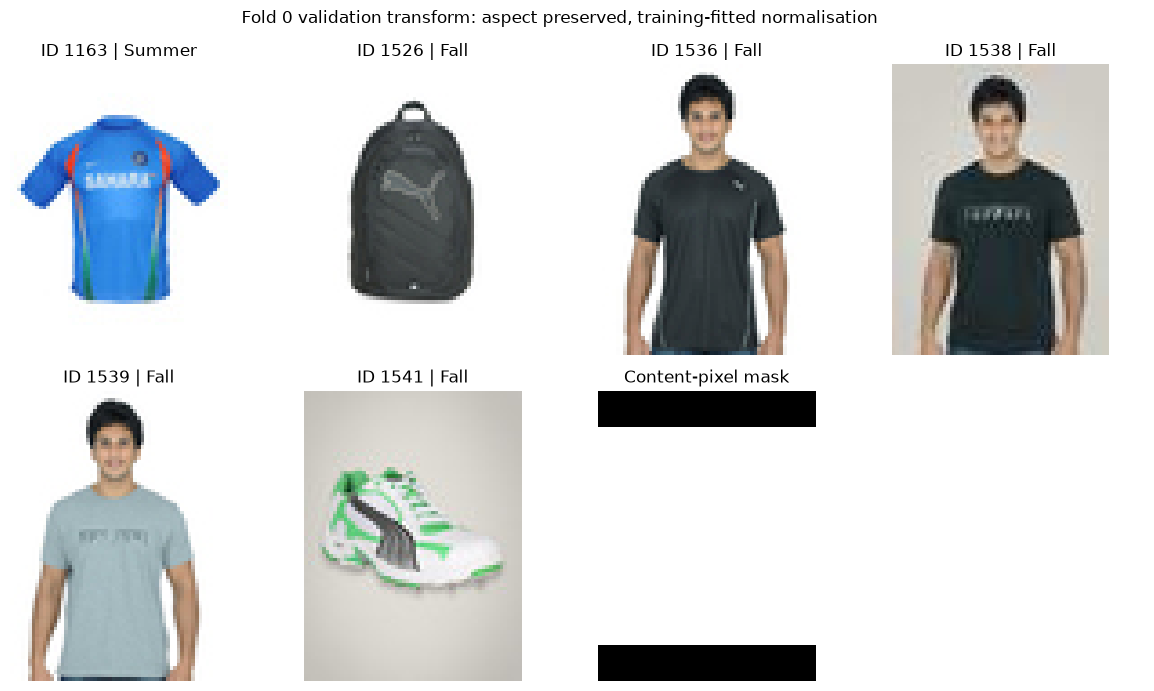

In [11]:
import io

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image as PILImage

from fashion.data.images import transform_image_with_mask
from fashion.data.torch import build_task_loaders
from fashion.train.artifacts import atomic_write_bytes

fold0_loaders = build_task_loaders(
    validation_fold=0,
    image_size=(80, 60),
    batch_size=8,
    validation_batch_size=8,
    target=TASK2_TARGET,
    augmentation="a0",
    seed=RANDOM_SEED,
    num_workers=0,
)
validation_batch = next(iter(fold0_loaders.validation))
mean = torch.tensor(fold0_loaders.stats.mean).view(1, 3, 1, 1)
std = torch.tensor(fold0_loaders.stats.std).view(1, 3, 1, 1)
display_images = (validation_batch["image"] * std + mean).clamp(0, 1)

validation_frame = fold_frames[0]["validation"]
nonstandard_aspect = validation_frame.loc[
    ~np.isclose(validation_frame["width"] / validation_frame["height"], 60 / 80)
]
assert not nonstandard_aspect.empty
first_row = nonstandard_aspect.iloc[0]
with PILImage.open(ROOT / first_row["path"]) as source:
    _, first_content_mask = transform_image_with_mask(source, image_size=(80, 60))
assert first_content_mask.any() and (~first_content_mask).any()

figure, axes = plt.subplots(2, 4, figsize=(12, 7))
for axis, image, target, item_id in zip(
    axes.flat[:6],
    display_images[:6],
    validation_batch["target"][:6],
    validation_batch["id"][:6],
    strict=True,
):
    axis.imshow(np.moveaxis(image.numpy(), 0, -1))
    axis.set_title(f"ID {int(item_id)} | {fold0_loaders.labels[int(target)]}")
    axis.axis("off")
axes.flat[6].imshow(first_content_mask, cmap="gray", vmin=0, vmax=1)
axes.flat[6].set_title("Content-pixel mask")
axes.flat[6].axis("off")
axes.flat[7].axis("off")
figure.suptitle("Fold 0 validation transform: aspect preserved, training-fitted normalisation")
figure.tight_layout()
preprocessing_figure_path = TASK2_FIGURE_DIR / "fold0_preprocessing_audit.png"
buffer = io.BytesIO()
figure.savefig(buffer, format="png", dpi=160, bbox_inches="tight")
atomic_write_bytes(preprocessing_figure_path, buffer.getvalue())
preprocessing_summary = {
    **fold0_loaders.audit(),
    "batch_shape": tuple(validation_batch["image"].shape),
}
display(pd.Series(preprocessing_summary).to_frame("value"))

> **Interpretation to write after running:** Confirm that product shape is preserved. Explain any unusual colour or padding behaviour visible in the batch.

### 4.2 Declare the controlled transform comparison

P0/P1 and A0/A1 answer whether upscaling and mild colour change help without changing the model budget.

In [12]:
from fashion.data.torch import ImageTransformSpec

transform_rows = []
for config_id, image_size, augmentation, gate, eligibility in (
    ("P0_A0", (80, 60), "a0", "input-size", "always"),
    ("P1_A0", (128, 96), "a0", "input-size", "always"),
    ("P0_A1", (80, 60), "a1", "augmentation", "only if P0_A0 wins size gate"),
    ("P1_A1", (128, 96), "a1", "augmentation", "only if P1_A0 wins size gate"),
):
    spec = ImageTransformSpec(image_size=image_size, augmentation=augmentation)
    transform_rows.append(
        {
            "config_id": config_id,
            "gate": gate,
            "image_size": str(image_size),
            "augmentation": augmentation,
            "transform_id": spec.transform_id,
            "model_family": "resnet18_small_stem",
            "seed": RANDOM_SEED,
            "folds": "0,1,2,3,4",
            "screen_epochs": 8,
            "eligibility": eligibility,
        }
    )
transform_matrix = pd.DataFrame(transform_rows)
assert transform_matrix[["model_family", "seed", "folds", "screen_epochs"]].nunique().eq(1).all()
atomic_write_csv(TASK2_EVIDENCE_DIR / "transform_matrix.csv", transform_matrix)
display(transform_matrix)

,config_id,gate,image_size,augmentation,transform_id,model_family,seed,folds,screen_epochs,eligibility
0,P0_A0,input-size,"(80, 60)",a0,a0-7dba8a62f166046d,resnet18_small_stem,2753,"0,1,2,3,4",8,always
1,P1_A0,input-size,"(128, 96)",a0,a0-a8878a801aa0d46e,resnet18_small_stem,2753,"0,1,2,3,4",8,always
2,P0_A1,augmentation,"(80, 60)",a1,a1-fe8cc596054e42b2,resnet18_small_stem,2753,"0,1,2,3,4",8,only if P0_A0 wins size gate
3,P1_A1,augmentation,"(128, 96)",a1,a1-f127f22d8b93e7f0,resnet18_small_stem,2753,"0,1,2,3,4",8,only if P1_A0 wins size gate


> **Interpretation to write after running:** Explain which visual question each comparison answers. Do not select a transform until the controlled results exist.

### 4.3 Run the leakage and transform audit

Year, file size, and true ArticleType can define later slices but must never enter the inference tensor.

In [13]:
import inspect

from fashion.models.season import SeasonModelSpec, assert_final_model, build_season_model

audit_model = build_season_model(SeasonModelSpec(family="smallcnn"))
model_boundary = assert_final_model(audit_model)
dataset_keys = set(fold0_loaders.validation.dataset[0])
first_validation = fold0_loaders.validation.dataset[0]["image"]
second_validation = fold0_loaders.validation.dataset[0]["image"]
forward_inputs = list(inspect.signature(audit_model.forward).parameters)
forbidden_inputs = {"year", "file_size_bytes", "articleType", "season", "cv_fold", "partition"}

leakage_checks = {
    "dataset exposes only id, image, and encoded target": dataset_keys == {"id", "image", "target"},
    "model forward accepts images only": forward_inputs == ["images"],
    "forbidden metadata absent from model inputs": not (dataset_keys & forbidden_inputs),
    "validation transform is deterministic": torch.equal(first_validation, second_validation),
    "normalisation fitted on fold-0 training IDs": fold0_loaders.stats.validation_fold == 0,
    "training and validation IDs do not overlap": not (
        set(fold0_loaders.training_ids) & set(fold0_loaders.validation_ids)
    ),
    "protected labels remain sealed": visible_protected_labels == visible_protected_masks == 0,
    "audit model is scratch and final-eligible": (
        model_boundary["training_origin"] == "scratch"
        and model_boundary["final_eligible"]
    ),
}
assert all(leakage_checks.values())
leakage_audit = {
    "schema_version": "1.0.0",
    "validation_fold": 0,
    "checks": leakage_checks,
    "forbidden_inference_fields": sorted(forbidden_inputs),
    "model_boundary": model_boundary,
}
atomic_write_json(TASK2_EVIDENCE_DIR / "leakage_audit.json", leakage_audit)
display(pd.DataFrame(leakage_checks.items(), columns=["check", "passed"]))

,check,passed
0,"dataset exposes only id, image, and encoded ta...",True
1,model forward accepts images only,True
2,forbidden metadata absent from model inputs,True
3,validation transform is deterministic,True
4,normalisation fitted on fold-0 training IDs,True
5,training and validation IDs do not overlap,True
6,protected labels remain sealed,True
7,audit model is scratch and final-eligible,True


> **Interpretation to write after running:** State exactly which metadata is retained only for post-prediction analysis and why that does not leak into training.

## 5. Baselines

Establish simple comparison anchors before interpreting deep models.

### 5.1 B0 training-fold majority baseline

B0 is selected first because it is the simplest leakage-safe predictor: each fold uses only the class distribution of its four training folds. Its strength is that it cheaply checks split handling and turns the EDA imbalance warning into a measurable lower bound. Its known limitation is complete image blindness; that limitation directly motivates B1.

,experiment_id,OOF products,accuracy,balanced_accuracy,macro_f1,Spring_f1,run_ids
0,b0-majority,32753,0.49568,0.25,0.165704,0.0,b0-majority-f0-s2753-8200c51534e3 | b0-majorit...


,metric,fold_mean,fold_sd,fold_min,fold_max,pooled_value
5,macro_f1,0.165704,0.000029,0.16568,0.165748,0.165704


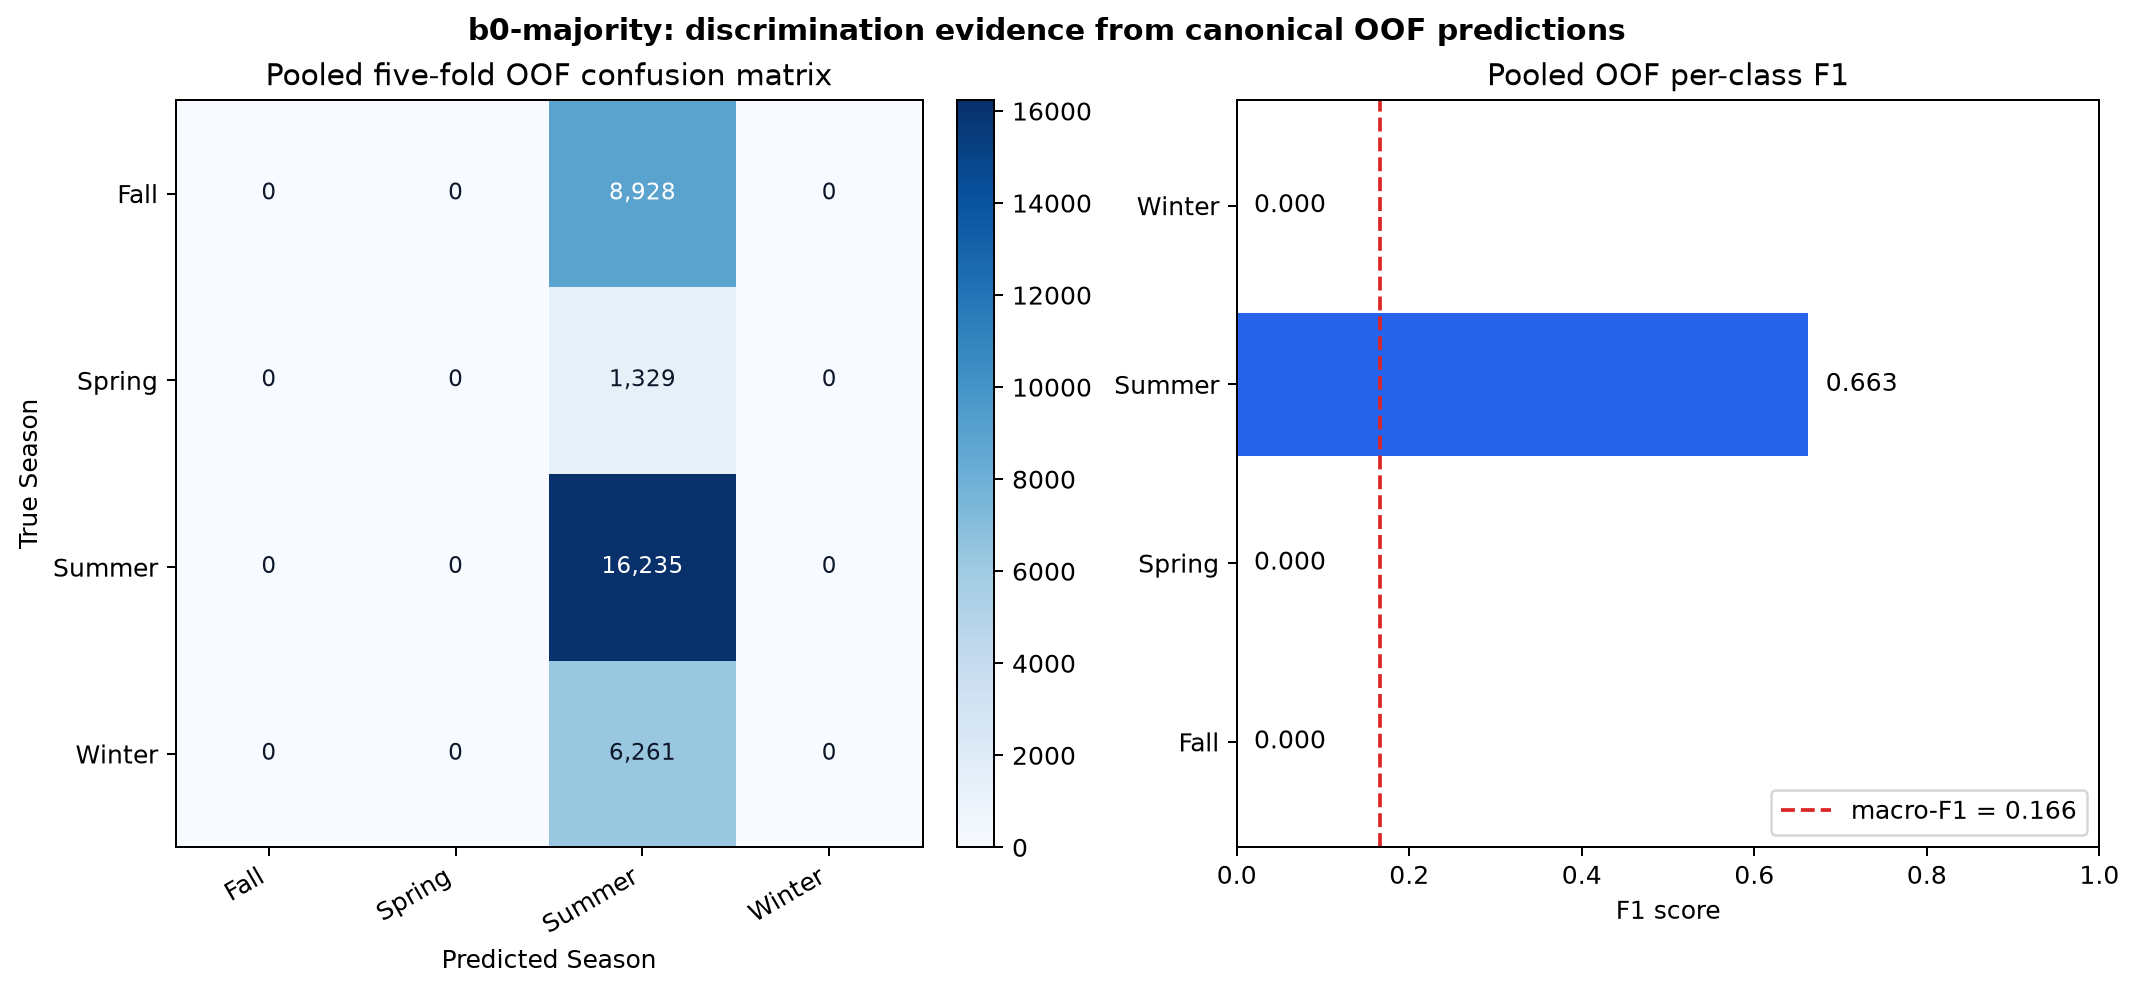

In [14]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.evidence import build_experiment_evidence
from fashion.task2.experiments import run_or_load_experiment

b0_outputs = run_or_load_experiment(
    TASK2_CONFIG_DIR / "b0_majority.json",
    mode="run_or_load",
)
b0_manifest = build_experiment_evidence(
    b0_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=(
        "Each validation product receives empirical Season priors fitted only on "
        "the other four training folds; these are valid probabilistic baseline "
        "outputs, not image-conditioned confidence."
    ),
    calibration_claim_allowed=True,
    evidence_directory=TASK2_EVIDENCE_DIR / "b0_majority",
    figure_directory=TASK2_FIGURE_DIR,
)
assert b0_manifest["coverage"]["row_count"] == len(season_development)
assert b0_manifest["coverage"]["protected_id_count"] == 0
assert len(b0_manifest["run_ids"]) == len(set(b0_manifest["run_ids"])) == 5

with (ROOT / b0_manifest["artifacts"]["pooled_metrics"]["path"]).open(
    encoding="utf-8"
) as handle:
    b0_pooled_metrics = json.load(handle)
b0_fold_summary = pd.read_csv(
    ROOT / b0_manifest["artifacts"]["fold_summary"]["path"]
)
b0_scorecard = pd.DataFrame(
    [{
        "experiment_id": b0_manifest["experiment_id"],
        "OOF products": b0_pooled_metrics["n_samples"],
        "accuracy": b0_pooled_metrics["accuracy"],
        "balanced_accuracy": b0_pooled_metrics["balanced_accuracy"],
        "macro_f1": b0_pooled_metrics["macro_f1"],
        "Spring_f1": b0_pooled_metrics["per_class"]["Spring"]["f1"],
        "run_ids": " | ".join(b0_manifest["run_ids"]),
    }]
)
display(b0_scorecard)
display(b0_fold_summary.loc[b0_fold_summary["metric"].eq("macro_f1")])
display(Image(filename=str(ROOT / b0_manifest["artifacts"]["figure"]["path"])))

> **Interpretation:** **Why this baseline:** B0 was selected first because a learning-free, training-fold-only majority predictor is the cleanest pipeline check and the honest lower bound implied by the EDA. **Result:** it covered all 32,753 valid development products once, with no protected IDs. It reached 49.568% accuracy but only `0.165704` pooled macro-F1 and `0.250000` balanced accuracy. It predicted Summer for every product: Summer F1 was `0.662815`, while Fall, Spring, and Winter F1 were all zero. Fold macro-F1 SD was only `0.000029`. **Strength:** B0 is cheap, deterministic, leakage-safe, and makes the accuracy illusion visible. Its near-zero ECE only shows that training-fold priors match pooled class frequency. **Limitation:** it ignores every image and cannot discriminate four seasons or recover Spring. **Incremental handoff:** B1 must test the next EDA claim - whether image shape and colour contain useful signal - and every learned model must beat `0.165704` macro-F1. **Trace:** `results/evidence/task2/b0_majority/manifest.json`; runs `b0-majority-f0-s2753-8200c51534e3`, `b0-majority-f1-s2753-7c378e67d9e6`, `b0-majority-f2-s2753-e50abeab2421`, `b0-majority-f3-s2753-b2fb197c26c1`, and `b0-majority-f4-s2753-b068532dab0a`.

### 5.2 B1 HOG plus HSV linear-SVM baseline

B1 is selected next because the EDA suggests that product shape and colour may carry Season signal. It is a serious, interpretable classical baseline: a CNN must improve on it, not merely beat the image-blind majority rule. Its fixed features and uncalibrated scores motivate C1.

,experiment_id,OOF products,accuracy,balanced_accuracy,macro_f1,macro_f1_gain_over_B0,Spring_precision,Spring_recall,Spring_f1,five_fold_runtime_minutes,linear_parameters
0,b1-hog-hsv-svm,32753,0.657405,0.620671,0.609561,0.443857,0.423098,0.573363,0.486901,36.143584,7916


,metric,fold_mean,fold_sd,fold_min,fold_max,pooled_value
5,macro_f1,0.609586,0.006962,0.602874,0.621388,0.609561


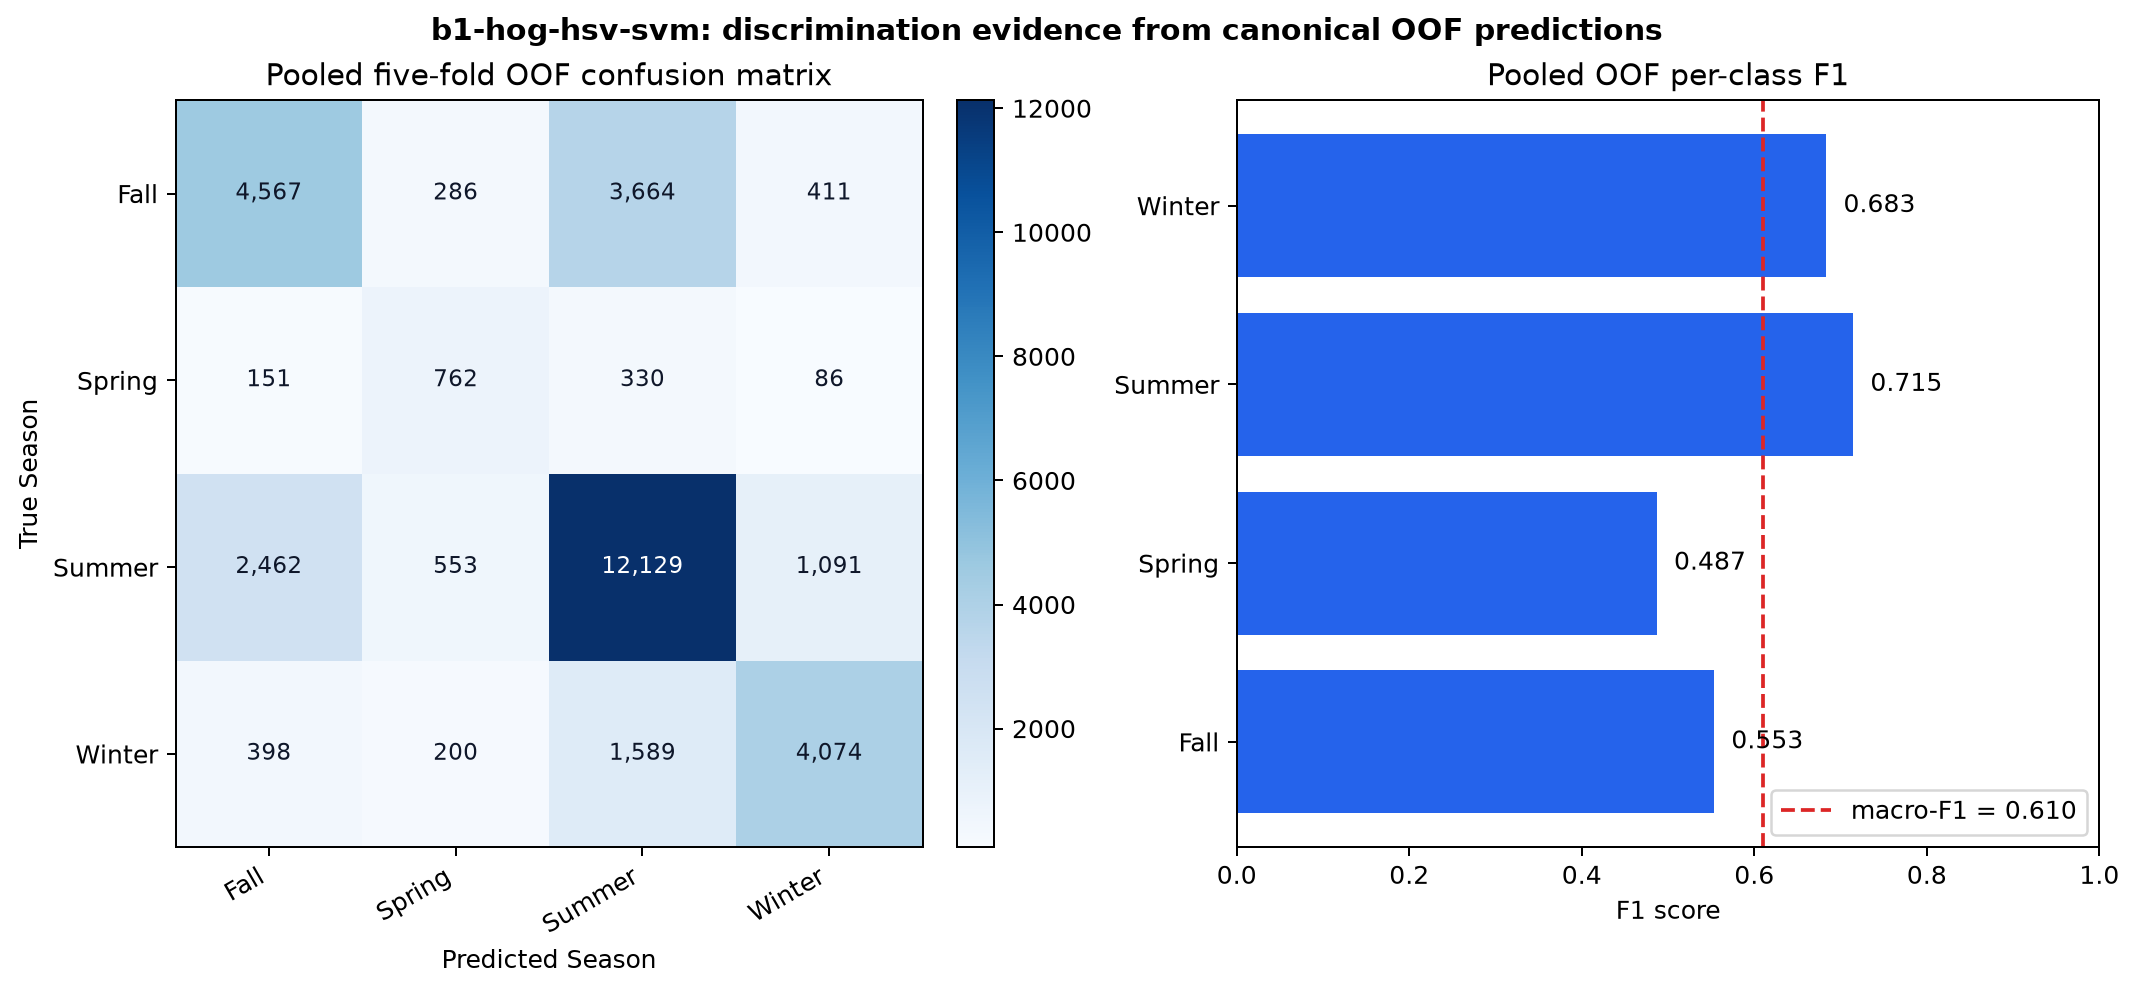

In [15]:
b1_outputs = run_or_load_experiment(
    TASK2_CONFIG_DIR / "b1_hog_hsv_svm.json",
    mode="run_or_load",
)
b1_manifest = build_experiment_evidence(
    b1_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=(
        "LinearSVC decision scores are transformed with row-wise softmax only "
        "to satisfy a common OOF storage schema. They are not calibrated "
        "probabilities, so B1 NLL, Brier, and ECE are descriptive diagnostics "
        "only and cannot support calibration claims."
    ),
    calibration_claim_allowed=False,
    evidence_directory=TASK2_EVIDENCE_DIR / "b1_hog_hsv_svm",
    figure_directory=TASK2_FIGURE_DIR,
)
assert b1_manifest["coverage"]["row_count"] == len(season_development)
assert b1_manifest["coverage"]["protected_id_count"] == 0
assert not b1_manifest["calibration_claim_allowed"]
assert len(b1_manifest["run_ids"]) == len(set(b1_manifest["run_ids"])) == 5

with (ROOT / b1_manifest["artifacts"]["pooled_metrics"]["path"]).open(
    encoding="utf-8"
) as handle:
    b1_pooled_metrics = json.load(handle)
b1_fold_summary = pd.read_csv(
    ROOT / b1_manifest["artifacts"]["fold_summary"]["path"]
)
b1_registry = pd.read_csv(
    ROOT / b1_manifest["artifacts"]["registry_snapshot"]["path"]
)
b1_scorecard = pd.DataFrame(
    [{
        "experiment_id": b1_manifest["experiment_id"],
        "OOF products": b1_pooled_metrics["n_samples"],
        "accuracy": b1_pooled_metrics["accuracy"],
        "balanced_accuracy": b1_pooled_metrics["balanced_accuracy"],
        "macro_f1": b1_pooled_metrics["macro_f1"],
        "macro_f1_gain_over_B0": (
            b1_pooled_metrics["macro_f1"] - b0_pooled_metrics["macro_f1"]
        ),
        "Spring_precision": b1_pooled_metrics["per_class"]["Spring"]["precision"],
        "Spring_recall": b1_pooled_metrics["per_class"]["Spring"]["recall"],
        "Spring_f1": b1_pooled_metrics["per_class"]["Spring"]["f1"],
        "five_fold_runtime_minutes": b1_registry["runtime_seconds"].sum() / 60,
        "linear_parameters": int(b1_registry["parameter_count"].iloc[0]),
    }]
)
display(b1_scorecard)
display(b1_fold_summary.loc[b1_fold_summary["metric"].eq("macro_f1")])
display(Image(filename=str(ROOT / b1_manifest["artifacts"]["figure"]["path"])))

> **Interpretation:** **Why this baseline:** B1 was selected next because HOG tests shape and HSV histograms test colour, directly converting the EDA into a classical image-only experiment. **Result:** it covered all 32,753 valid development products once with no protected IDs. It reached `0.609561` pooled macro-F1, `0.657405` accuracy, and `0.620671` balanced accuracy: a `0.443857` absolute macro-F1 gain over B0. Spring precision, recall, and F1 were `0.423098`, `0.573363`, and `0.486901`; pooled F1 was `0.553375` for Fall, `0.714584` for Summer, and `0.683385` for Winter. Fold macro-F1 SD was `0.006962`. **Strength:** B1 proves that deterministic shape and colour features contain substantial Season signal and creates a serious threshold for deep models. **Limitation:** HOG/HSV cannot learn task-specific features, may exploit catalogue style, and its softmax-transformed LinearSVC scores are not calibrated probabilities. It still sends 3,664 Fall and 1,589 Winter products to Summer, and Spring remains weakest. **Incremental handoff:** C1 must learn features end to end and beat `0.609561`, or offer a clear robustness, efficiency, or minority-class benefit. **Trace:** `results/evidence/task2/b1_hog_hsv_svm/manifest.json`; runs `b1-hog-hsv-svm-f0-s2753-b23d1eafe35f`, `b1-hog-hsv-svm-f1-s2753-5735c51cc237`, `b1-hog-hsv-svm-f2-s2753-3f214f6a2bd4`, `b1-hog-hsv-svm-f3-s2753-83fd8ce0b942`, and `b1-hog-hsv-svm-f4-s2753-45b2e5123926`.

## 6. Scratch model families

Define three different deep-learning capacities and prove that the submitted candidates start from random weights.

### 6.1 Define the scratch model factories

Each architecture is a separate implementation unit and therefore receives its own subsubsection and code cell.

#### 6.1.1 C1 four-block SmallCNN

C1 is the simple deep baseline and makes capacity and failure analysis easy to explain.

In [16]:
from fashion.models.season import (
    SeasonModelSpec,
    assert_final_model,
    build_season_model,
)

smallcnn = build_season_model(
    SeasonModelSpec(family="smallcnn", num_classes=len(SEASON_LABELS))
)
smallcnn_boundary = assert_final_model(smallcnn)
with torch.inference_mode():
    smallcnn_logits = smallcnn(torch.zeros(2, 3, 80, 60))
assert tuple(smallcnn_logits.shape) == (2, len(SEASON_LABELS))
display(pd.DataFrame([{**smallcnn_boundary, "output_shape": tuple(smallcnn_logits.shape)}]))

,class,training_origin,benchmark_only,final_eligible,weights,output_shape
0,SmallSeasonCNN,scratch,False,True,None,"(2, 4)"


> **Interpretation:** C1 returns four logits for each image, is final-eligible, and is created from scratch with `weights=None`. It follows B1 because its convolutions learn task-specific features instead of freezing HOG and HSV by hand. Its strength is a compact, easy-to-audit capacity baseline. Its limitation is that four simple blocks may miss longer-range structure; C2 therefore tests whether residual depth adds useful discrimination, while C3 provides an efficiency alternative.

#### 6.1.2 C2 ResNet18 with a small-image stem

C2 tests residual learning without discarding small-image detail in the first layers.

In [17]:
from torch import nn

resnet18_small_stem = build_season_model(
    SeasonModelSpec(family="resnet18_small_stem", num_classes=len(SEASON_LABELS))
)
resnet_boundary = assert_final_model(resnet18_small_stem)
stem = resnet18_small_stem.backbone.conv1
assert stem.kernel_size == (3, 3) and stem.stride == (1, 1)
assert isinstance(resnet18_small_stem.backbone.maxpool, nn.Identity)
with torch.inference_mode():
    resnet_logits = resnet18_small_stem(torch.zeros(2, 3, 80, 60))
assert tuple(resnet_logits.shape) == (2, len(SEASON_LABELS))
resnet_summary = {
    **resnet_boundary,
    "stem": "3x3, stride 1, no max-pool",
    "output_shape": tuple(resnet_logits.shape),
}
display(pd.DataFrame([resnet_summary]))

,class,training_origin,benchmark_only,final_eligible,weights,stem,output_shape
0,ScratchSmallStemResNet18,scratch,False,True,None,"3x3, stride 1, no max-pool","(2, 4)"


> **Interpretation:** C2 also returns four logits and is final-eligible, scratch-trained with `weights=None`. The `3x3`, stride-1 stem and removed max-pool preserve more of each 60 x 80 catalogue image than the standard ImageNet stem. C2 follows C1 to test whether deeper residual features solve C1's capacity limit. Its strength is higher representational capacity; its limitation is much greater cost, so G1 must measure whether the gain is large enough rather than assume that a larger model is better.

#### 6.1.3 C3 MobileNetV3-Small

C3 tests whether a mobile architecture offers a better quality-to-latency trade-off.

In [18]:
mobilenet_v3_small = build_season_model(
    SeasonModelSpec(family="mobilenet_v3_small", num_classes=len(SEASON_LABELS))
)
mobilenet_boundary = assert_final_model(mobilenet_v3_small)
with torch.inference_mode():
    mobilenet_logits = mobilenet_v3_small(torch.zeros(2, 3, 80, 60))
assert tuple(mobilenet_logits.shape) == (2, len(SEASON_LABELS))
display(pd.DataFrame([{**mobilenet_boundary, "output_shape": tuple(mobilenet_logits.shape)}]))

,class,training_origin,benchmark_only,final_eligible,weights,output_shape
0,ScratchMobileNetV3Small,scratch,False,True,None,"(2, 4)"


> **Interpretation:** C3 returns four logits, is final-eligible, and is built from scratch with `weights=None`. It is not assumed to be an upgrade over C2; it is an alternative that tests whether a mobile architecture can preserve enough quality with lower training memory and deployment cost. Its strength should be efficiency, while its limitation may be underfitting this weak-visual-signal target. G1 therefore measures macro-F1, runtime, and VRAM instead of choosing it from architecture reputation.

### 6.2 Audit shapes, parameters, and random initialisation

A forward-pass and weight-provenance audit catches architecture mistakes before GPU runs.

In [19]:
def state_dict_sha256(model):
    digest = hashlib.sha256()
    for name, tensor in sorted(model.state_dict().items()):
        values = tensor.detach().cpu().contiguous().numpy()
        digest.update(name.encode("utf-8"))
        digest.update(str(values.dtype).encode("ascii"))
        digest.update(str(values.shape).encode("ascii"))
        digest.update(values.tobytes())
    return digest.hexdigest()

model_families = {
    "C1": smallcnn,
    "C2": resnet18_small_stem,
    "C3": mobilenet_v3_small,
}
real_images = validation_batch["image"][:2]
synthetic_images = torch.zeros(2, 3, 128, 96)
model_audit_rows = []
for model_id, model in model_families.items():
    model.eval()
    with torch.inference_mode():
        real_logits = model(real_images)
        synthetic_logits = model(synthetic_images)
    assert real_logits.shape == synthetic_logits.shape == (2, len(SEASON_LABELS))
    assert torch.isfinite(real_logits).all() and torch.isfinite(synthetic_logits).all()
    boundary = assert_final_model(model)
    model_audit_rows.append(
        {
            "model_id": model_id,
            "class": type(model).__name__,
            "parameters": sum(parameter.numel() for parameter in model.parameters()),
            "trainable_parameters": sum(
                parameter.numel()
                for parameter in model.parameters()
                if parameter.requires_grad
            ),
            "initial_state_sha256": state_dict_sha256(model),
            **boundary,
            "p0_forward_pass": True,
            "p1_forward_pass": True,
        }
    )
scratch_model_audit = pd.DataFrame(model_audit_rows)
atomic_write_csv(TASK2_EVIDENCE_DIR / "scratch_model_audit.csv", scratch_model_audit)
display(scratch_model_audit)

,model_id,class,parameters,trainable_parameters,initial_state_sha256,training_origin,benchmark_only,final_eligible,weights,p0_forward_pass,p1_forward_pass
0,C1,SmallSeasonCNN,1174244,1174244,6a4b761ee246405c2cc5f642160b961b9fb459a647b7d1...,scratch,False,True,None,True,True
1,C2,ScratchSmallStemResNet18,11170884,11170884,1f01887973b739c477d19d9f08c9bc19b45a6c995776f9...,scratch,False,True,None,True,True
2,C3,ScratchMobileNetV3Small,1521956,1521956,d16f06681d4444e52241cf1b57064631be62cd53b417e7...,scratch,False,True,None,True,True


> **Interpretation to write after running:** Compare capacity and expected deployment cost. Confirm that each submitted candidate is scratch-trained.

### 6.3 Declare the pretrained benchmark boundary

A pretrained comparison is useful only when it is clearly excluded from final eligibility.

In [20]:
from fashion.models.season import (
    BenchmarkModelSpec,
    ModelBoundaryError,
    build_benchmark_model,
    model_boundary_audit,
)

standard_stem_control = build_benchmark_model(
    BenchmarkModelSpec(family="resnet18_standard_scratch", num_classes=len(SEASON_LABELS))
)
standard_control_boundary = model_boundary_audit(standard_stem_control)
try:
    assert_final_model(standard_stem_control)
except ModelBoundaryError as boundary_error:
    benchmark_rejection = str(boundary_error)
else:
    raise AssertionError("benchmark model entered the final-model boundary")

pretrained_spec = BenchmarkModelSpec(
    family="resnet18_standard_pretrained",
    num_classes=len(SEASON_LABELS),
)
pretrained_spec.validate()
benchmark_boundary = pd.DataFrame(
    [
        {
            "experiment": "P0S",
            "family": "resnet18_standard_scratch",
            "training_origin": "scratch",
            "weights": None,
            "benchmark_only": True,
            "final_eligible": False,
        },
        {
            "experiment": "P*",
            "family": pretrained_spec.family,
            "training_origin": "imagenet_pretrained",
            "weights": "ResNet18_Weights.DEFAULT",
            "benchmark_only": True,
            "final_eligible": False,
        },
    ]
)
assert benchmark_boundary["benchmark_only"].all() and not benchmark_boundary["final_eligible"].any()
benchmark_boundary["final_boundary_rejection"] = benchmark_rejection
atomic_write_csv(TASK2_EVIDENCE_DIR / "benchmark_boundary.csv", benchmark_boundary)
display(benchmark_boundary)

,experiment,family,training_origin,weights,benchmark_only,final_eligible,final_boundary_rejection
0,P0S,resnet18_standard_scratch,scratch,NaN,True,False,model is not final-eligible: benchmark_only mu...
1,P*,resnet18_standard_pretrained,imagenet_pretrained,ResNet18_Weights.DEFAULT,True,False,model is not final-eligible: benchmark_only mu...


> **Interpretation to write after running:** Explain what the pretrained gap says about data and representation learning, without selecting P* as the final model.

## 7. Training and run registry

Prove the shared engine, checkpointing, failure handling, and registry before long runs.

### 7.1 G0 tiny-batch smoke test

A tiny overfit test catches label order, image mapping, loss, and backpropagation errors cheaply.

,G0 pipeline gate
run_id,g0-pipeline-smoke-f0-s2753-5ad5ee9d433c
source,cache
passed,True
tiny_final_accuracy,1.0
tiny_loss_ratio,0.000015
integration_epochs,2
integration_macro_f1_non_comparison,0.343262
checkpoint_sha256,154dc1a91c428001b4c6c261e756311a195ddd55d76bfb...


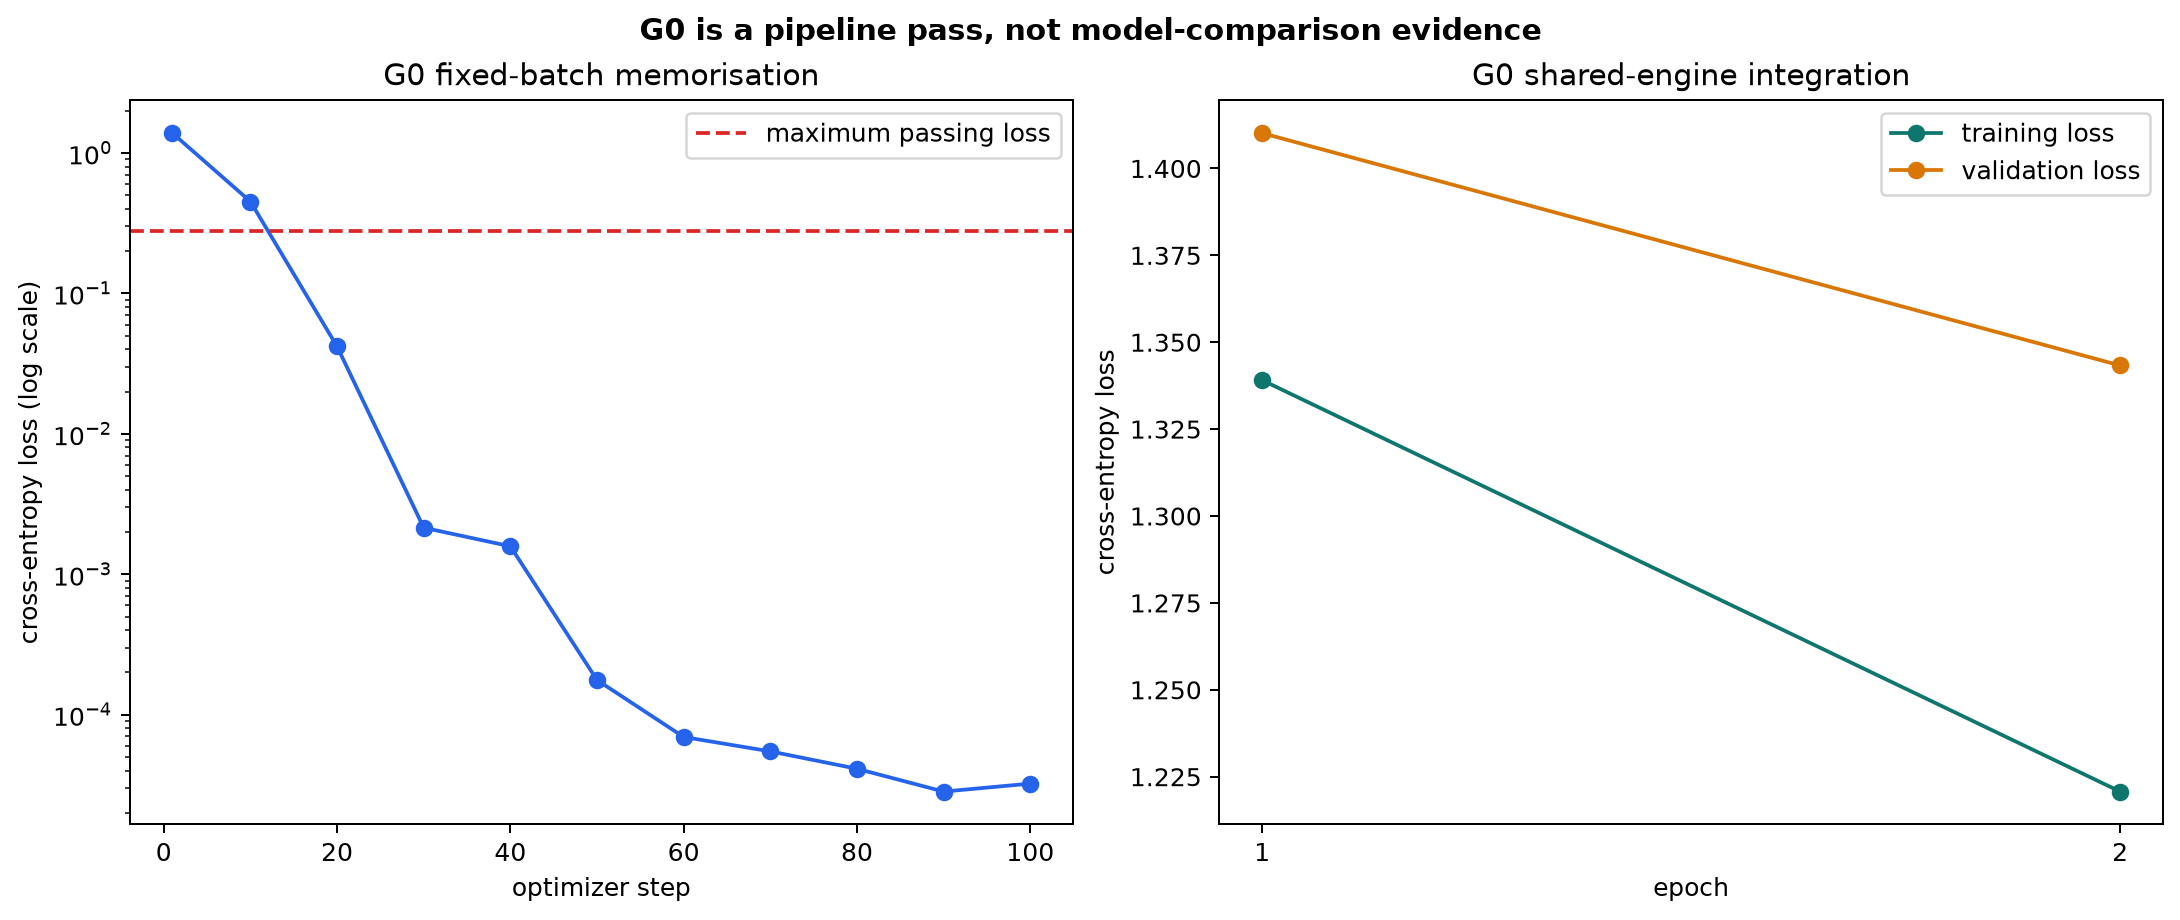

{'schema_version': '1.0.0',
 'gate': 'G0',
 'passed': True,
 'comparison_eligible': False,
 'run_id': 'g0-pipeline-smoke-f0-s2753-5ad5ee9d433c',
 'source': 'cache',
 'cache_key': {'config_sha256': '7d87f50206caf2bfd83f800dd128db56e6e9269eb513ce583e39f83ec73a12de',
  'split_sha256': 'd76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db',
  'label_map_sha256': '51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327',
  'implementation_sha256': '6346eb33ea704593ca71aa48a975aac8f0169a76a41a8a4113a9c2141f7bb2a4',
  'fold': 0,
  'seed': 2753},
 'tiny_overfit': {'products': 64,
  'steps': 100,
  'device': 'cuda',
  'initial_loss': 1.385862112045288,
  'final_loss': 2.0097653759876266e-05,
  'final_accuracy': 1.0,
  'loss_ratio': 1.4501914429434595e-05,
  'minimum_accuracy': 0.95,
  'maximum_loss_ratio': 0.2,
  'gradients_finite': True,
  'passed': True},
 'integration': {'training_products': 512,
  'validation_products': 128,
  'epochs_completed': 2,
  'best_epoch': 2,
 

In [21]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.evidence import build_g0_evidence
from fashion.task2.smoke import run_or_load_g0_smoke

g0_result = run_or_load_g0_smoke(
    TASK2_CONFIG_DIR / "g0_pipeline_smoke.json",
    mode="run_or_load",
)
g0_manifest = build_g0_evidence(g0_result, registry_path=RUNS_CSV)
g0_summary = {
    "run_id": g0_result.run_id,
    "source": g0_result.source,
    "passed": g0_result.passed,
    "tiny_final_accuracy": g0_result.tiny_overfit["final_accuracy"],
    "tiny_loss_ratio": g0_result.tiny_overfit["loss_ratio"],
    "integration_epochs": g0_result.integration["epochs_completed"],
    "integration_macro_f1_non_comparison": (
        g0_result.integration["best_metrics"]["macro_f1"]
    ),
    "checkpoint_sha256": g0_result.artifacts["checkpoint"],
}
display(pd.Series(g0_summary, name="G0 pipeline gate").to_frame())
display(Image(filename=str(ROOT / g0_manifest["figure_path"])))
g0_manifest

> **Interpretation:** **Result —** clean run `g0-pipeline-smoke-f0-s2753-5ad5ee9d433c` passed: the balanced 64-image batch reached 100% accuracy after 100 steps, its final loss was `0.0000145` of the initial loss, gradients stayed finite, and the 512-image integration run completed two epochs with hash-verified artifacts. **Meaning —** the loader-cache implementation change correctly invalidated the stale G0 cache; the external rerun closed the current functional gate, and this Run All reused its verified bytes. **Provenance —** the selected registry snapshot records commit `7d70e3f`, `git_dirty=false`, the current implementation hash, and `status=completed`. The earlier dirty row remains in the append-only registry but supports no claim. **Decision —** G0 unlocks the measured experiments. Its integration macro-F1 is deliberately excluded from every leaderboard. **Limitation —** G0 uses small balanced subsets and fold 0 only, so it says nothing about comparative model quality or five-fold stability. **Trace —** `results/evidence/task2/g0/manifest.json`, its one-row clean registry snapshot, and the run ID above.

### 7.2 Audit registry and checkpoint traceability

Every reported number must be traceable to configuration, split, code, and artifact hashes.

In [22]:
from fashion.config import RUNS_CSV
from fashion.train.registry import RUN_COLUMNS, RUN_STATUSES, RunRegistry

run_registry = RunRegistry(RUNS_CSV)
registry_rows = run_registry.read()
schema_matches = tuple(registry_rows.columns) == RUN_COLUMNS
unique_run_ids = not registry_rows["run_id"].duplicated().any()
known_statuses = set(registry_rows["status"]) <= RUN_STATUSES
declared_checkpoints = registry_rows.loc[registry_rows["checkpoint_path"].ne(""), "checkpoint_path"]
checkpoint_paths_exist = all((ROOT / path).is_file() for path in declared_checkpoints)
hash_columns = ["config_sha256", "split_sha256", "label_map_sha256", "implementation_sha256"]
identity_hashes_valid = registry_rows.empty or registry_rows[hash_columns].apply(
    lambda column: column.str.fullmatch(r"[0-9a-f]{64}").all()
).all()
registry_health = {
    "schema_version": "1.0.0",
    "registry_path": RUNS_CSV.relative_to(ROOT).as_posix(),
    "run_count": len(registry_rows),
    "schema_matches": bool(schema_matches),
    "unique_run_ids": bool(unique_run_ids),
    "known_statuses": bool(known_statuses),
    "identity_hashes_valid": bool(identity_hashes_valid),
    "declared_checkpoints_exist": bool(checkpoint_paths_exist),
    "status_counts": registry_rows["status"].value_counts().sort_index().to_dict(),
}
assert all(
    registry_health[key]
    for key in (
        "schema_matches",
        "unique_run_ids",
        "known_statuses",
        "identity_hashes_valid",
        "declared_checkpoints_exist",
    )
)
atomic_write_json(TASK2_EVIDENCE_DIR / "registry_health.json", registry_health)
display(pd.Series(registry_health, name="Registry health").to_frame())
display(registry_rows.tail(10))

,Registry health
schema_version,1.0.0
registry_path,results/runs.csv
run_count,73
schema_matches,True
unique_run_ids,True
known_statuses,True
identity_hashes_valid,True
declared_checkpoints_exist,True
status_counts,"{'completed': 68, 'failed': 1, 'interrupted': 4}"


,run_id,task,stage,experiment_id,model_family,benchmark_only,final_eligible,scratch,fold,seed,...,prediction_path,prediction_sha256,history_path,history_sha256,status,error_type,error_message,started_at_utc,finished_at_utc,runtime
63,g3-c1-t1-smallcnn-f1-s2753-b63b6a84d669,task2,g3_full_budget,g3-c1-t1-smallcnn,smallcnn,false,true,true,1,2753,...,tmp/task2/runs/g3-c1-t1-smallcnn-f1-s2753-b63b...,b22c472506165bb4f16ab53ca205bed1744c5fa8dec4db...,tmp/task2/runs/g3-c1-t1-smallcnn-f1-s2753-b63b...,0795a6e42d4866fbad2cee774e3c628e453885099a296b...,completed,,,2026-08-27T08:29:46Z,2026-08-27T08:34:15Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
64,g3-c1-t1-smallcnn-f2-s2753-2283b6495a44,task2,g3_full_budget,g3-c1-t1-smallcnn,smallcnn,false,true,true,2,2753,...,,,,,interrupted,ExternalProcessTermination,Training host process ended outside Python bet...,2026-08-27T08:34:16Z,2026-08-27T10:50:33Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
65,g3-c1-t1-smallcnn-f2-s2753-e46d771b6d56,task2,g3_full_budget,g3-c1-t1-smallcnn,smallcnn,false,true,true,2,2753,...,tmp/task2/runs/g3-c1-t1-smallcnn-f2-s2753-e46d...,43049128cc40a75fa12afc9c94e06e0bf90f9c127a6316...,tmp/task2/runs/g3-c1-t1-smallcnn-f2-s2753-e46d...,3cd913662f64a5f5eb9c97b86eb8b4c25454017a5d1446...,completed,,,2026-08-27T10:51:04Z,2026-08-27T10:57:23Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
66,g3-c1-t1-smallcnn-f3-s2753-763dbb29ec53,task2,g3_full_budget,g3-c1-t1-smallcnn,smallcnn,false,true,true,3,2753,...,tmp/task2/runs/g3-c1-t1-smallcnn-f3-s2753-763d...,63db245bdac77032e9686baed7d00cf8830584b1279ba3...,tmp/task2/runs/g3-c1-t1-smallcnn-f3-s2753-763d...,376259b5ef88a58e8161be6a0ebbd2c3e0547e3d4dd95e...,completed,,,2026-08-27T10:57:24Z,2026-08-27T11:03:24Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
67,g3-c1-t1-smallcnn-f4-s2753-92870ee0d57d,task2,g3_full_budget,g3-c1-t1-smallcnn,smallcnn,false,true,true,4,2753,...,tmp/task2/runs/g3-c1-t1-smallcnn-f4-s2753-9287...,95a0bb6c5b63fd4b652ca6530e4000af42a6e659e19d73...,tmp/task2/runs/g3-c1-t1-smallcnn-f4-s2753-9287...,6039a09f6c87d23c2326d50dafe8df32fbe8f25045e53a...,completed,,,2026-08-27T11:03:25Z,2026-08-27T11:06:52Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
68,g3-c2-t0-resnet18-f0-s2753-c6cd41fd50f4,task2,g3_full_budget,g3-c2-t0-resnet18,resnet18_small_stem,false,true,true,0,2753,...,tmp/task2/runs/g3-c2-t0-resnet18-f0-s2753-c6cd...,202042a9ac563f2377b8e20ceab124888a8e8d652039e9...,tmp/task2/runs/g3-c2-t0-resnet18-f0-s2753-c6cd...,d97d6a9579e062abfb2cc48e02c176d407f9e7c5e44cac...,completed,,,2026-08-27T11:13:11Z,2026-08-27T11:30:56Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
69,g3-c2-t0-resnet18-f1-s2753-30a5a7742c38,task2,g3_full_budget,g3-c2-t0-resnet18,resnet18_small_stem,false,true,true,1,2753,...,tmp/task2/runs/g3-c2-t0-resnet18-f1-s2753-30a5...,85974f5cc3a20031a767d62eaebfd227d992a5e44ae0d8...,tmp/task2/runs/g3-c2-t0-resnet18-f1-s2753-30a5...,0ddaa67d3eae8aa93f51ac15908e08d67d073111f263a9...,completed,,,2026-08-27T11:30:57Z,2026-08-27T11:52:16Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
70,g3-c2-t0-resnet18-f2-s2753-aaac5fd8559b,task2,g3_full_budget,g3-c2-t0-resnet18,resnet18_small_stem,false,true,true,2,2753,...,tmp/task2/runs/g3-c2-t0-resnet18-f2-s2753-aaac...,eb26fb4ee409333956056bccdc478a8a5ce42eab186510...,tmp/task2/runs/g3-c2-t0-resnet18-f2-s2753-aaac...,06a2c0155a8e210b0fbc398a9a7f1b678f361805985950...,completed,,,2026-08-27T11:52:17Z,2026-08-27T12:04:05Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
71,g3-c2-t0-resnet18-f3-s2753-5e67289a4f07,task2,g3_full_budget,g3-c2-t0-resnet18,resnet18_small_stem,false,true,true,3,2753,...,tmp/task2/runs/g3-c2-t0-resnet18-f3-s2753-5e67...,63b200726e0040fc3740699bceeb4378b2fa9a6258f940...,tmp/task2/runs/g3-c2-t0-resnet18-f3-s2753-5e67...,15a2092a0cc04c765bfe5d7df5430e11c472c71aab880c...,completed,,,2026-08-27T12:04:06Z,2026-08-27T12:21:14Z,"{""cuda_available"":tru

> **Interpretation to write after running:** Confirm that each future table can be regenerated from run IDs. Explain any failed run honestly.

## 8. Controlled experiment matrix

Execute broad comparisons under equal budgets, then spend extra compute only on justified finalists.

### 8.1 G1 and G3 model-family comparison

Screening and full finalist training answer different questions, so they are separated below.

#### 8.1.1 G1 equal-budget family screening

The screen decides which families deserve more compute under one fixed budget.

,rank,experiment_id,model_family,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,spring_f1,parameter_count,five_fold_runtime_minutes,peak_vram_mb,shortlisted,delta_vs_best_macro_f1,gain_over_b1_macro_f1
0,1,g1-c2-resnet18,resnet18_small_stem,0.7071,0.706496,0.0039,0.7384,11170884,29.21,606.4,True,0.000000,+0.0975
1,2,g1-c1-smallcnn,smallcnn,0.6999,0.699752,0.0109,0.7262,1174244,19.11,191.4,True,-0.007197,+0.0903
2,3,g1-c3-mobilenetv3,mobilenet_v3_small,0.6385,0.638336,0.0083,0.6688,1521956,16.66,74.3,False,-0.068604,+0.0289


,experiment_id,fold,run_id,source,fold_macro_f1
0,g1-c1-smallcnn,0,g1-c1-smallcnn-f0-s2753-59e9743d3899,cache,0.699749
1,g1-c1-smallcnn,1,g1-c1-smallcnn-f1-s2753-f73cfae4a798,cache,0.683056
2,g1-c1-smallcnn,2,g1-c1-smallcnn-f2-s2753-8e178abd5435,cache,0.710146
3,g1-c1-smallcnn,3,g1-c1-smallcnn-f3-s2753-bf3525f7f30f,cache,0.708893
4,g1-c1-smallcnn,4,g1-c1-smallcnn-f4-s2753-476a7394ed3e,cache,0.696914
5,g1-c2-resnet18,0,g1-c2-resnet18-f0-s2753-b91662d47026,cache,0.703758
6,g1-c2-resnet18,1,g1-c2-resnet18-f1-s2753-a4ff07c863e4,cache,0.705058
7,g1-c2-resnet18,2,g1-c2-resnet18-f2-s2753-2d6a8dffa3fe,cache,0.712810
8,g1-c2-resnet18,3,g1-c2-resnet18-f3-s2753-f2eb5f7a2dac,cache,0.707456
9,g1-c2-resnet18,4,g1-c2-resnet18-f4-s2753-2449eed2ce12,cache,0.703396


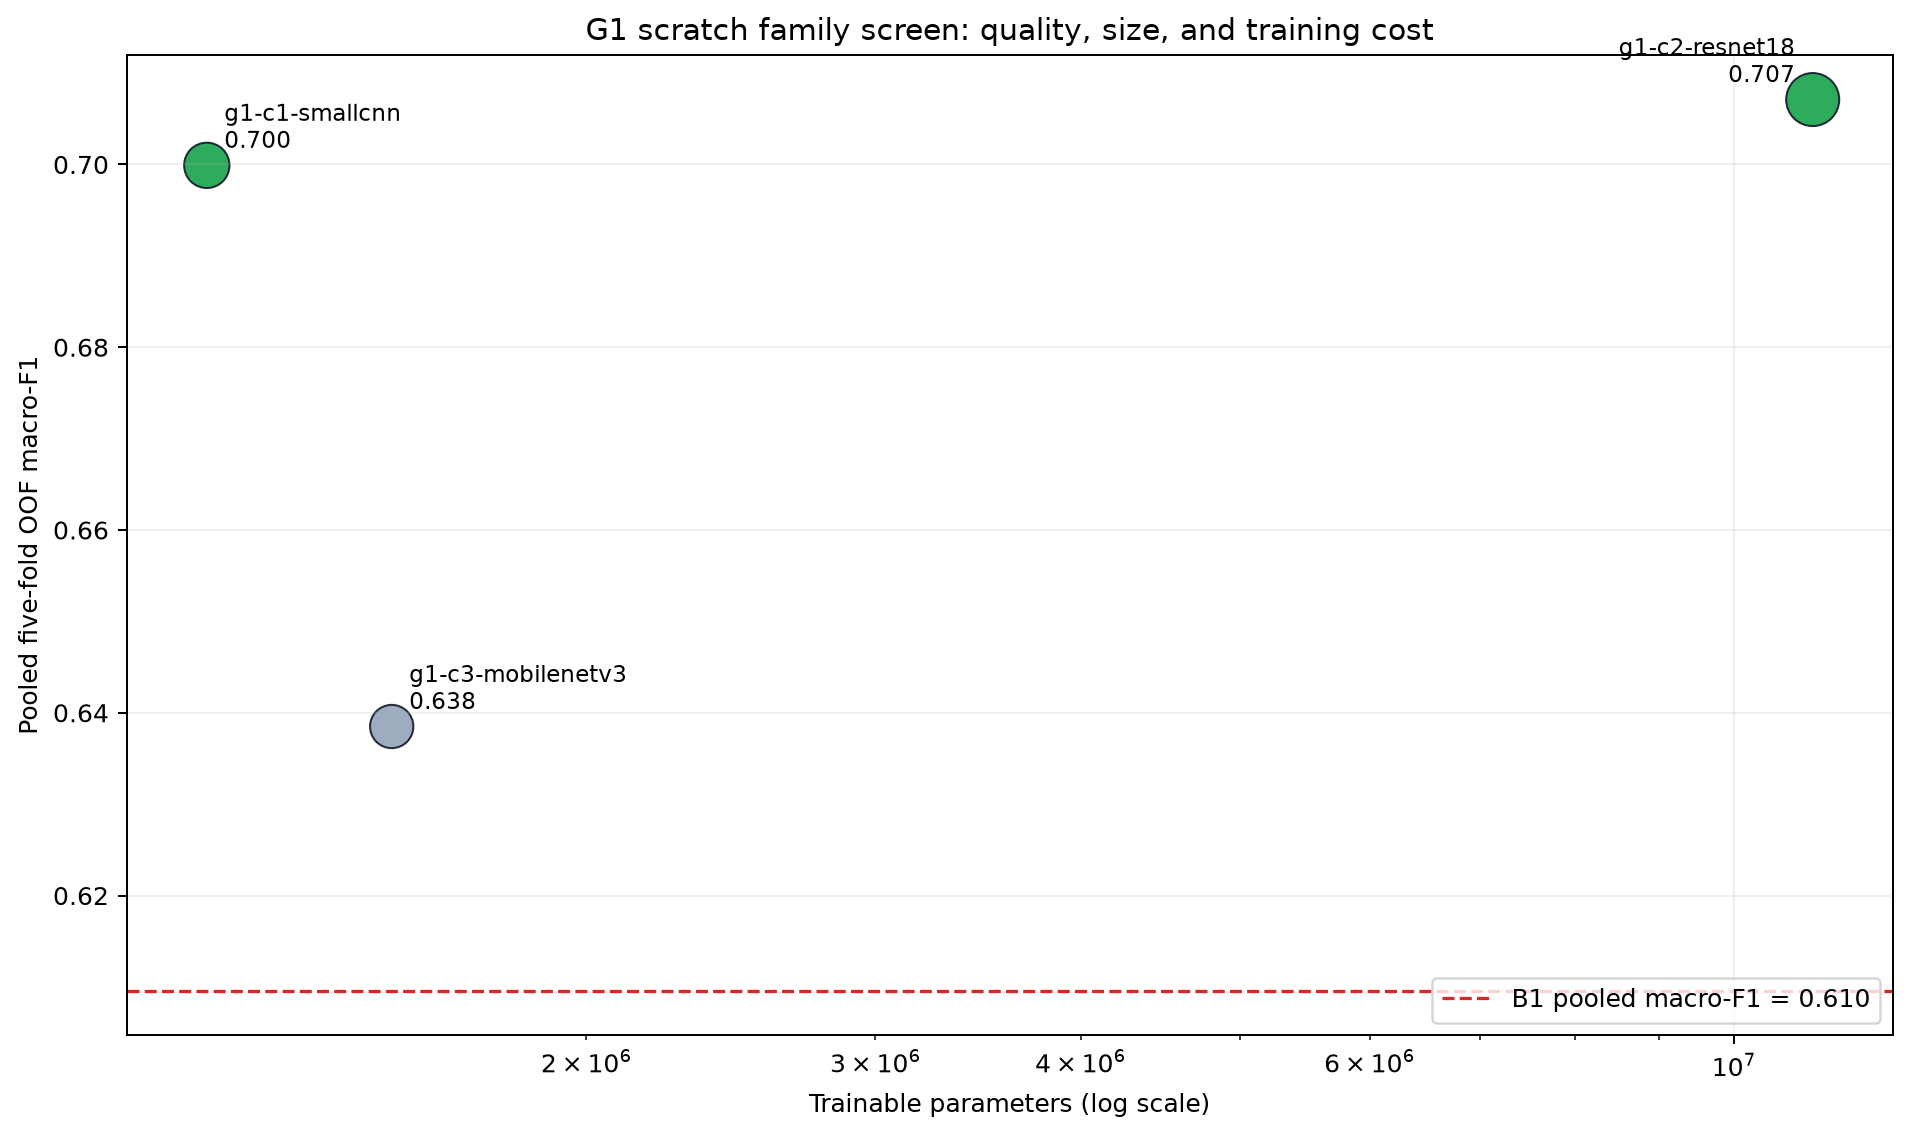

In [23]:
from fashion.task2.evidence import build_g1_family_screen_evidence

g1_specs = {
    "g1-c1-smallcnn": ("g1_c1_smallcnn.json", "g1_c1_smallcnn"),
    "g1-c2-resnet18": ("g1_c2_resnet18.json", "g1_c2_resnet18"),
    "g1-c3-mobilenetv3": ("g1_c3_mobilenetv3.json", "g1_c3_mobilenetv3"),
}
g1_probability_note = (
    "Softmax probabilities come from each fold's best validation macro-F1 "
    "checkpoint. They are uncalibrated until the dedicated cross-fitted "
    "calibration gate, so current NLL, Brier, and ECE are diagnostics only."
)
g1_manifests = {}
g1_trace_rows = []
for experiment_id, (config_name, evidence_slug) in g1_specs.items():
    outputs = run_or_load_experiment(
        TASK2_CONFIG_DIR / config_name,
        mode="run_or_load",
    )
    experiment_manifest = build_experiment_evidence(
        outputs,
        registry_path=RUNS_CSV,
        expected_ids=season_development["id"],
        protected_ids=protected_ids,
        probability_note=g1_probability_note,
        calibration_claim_allowed=False,
        evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
        figure_directory=TASK2_FIGURE_DIR,
    )
    assert experiment_manifest["experiment_id"] == experiment_id
    assert experiment_manifest["coverage"]["row_count"] == len(season_development)
    assert experiment_manifest["coverage"]["protected_id_count"] == 0
    g1_manifests[experiment_id] = experiment_manifest
    g1_trace_rows.extend(
        {
            "experiment_id": experiment_id,
            "fold": output.fold,
            "run_id": output.run_id,
            "source": output.source,
            "fold_macro_f1": output.metrics["macro_f1"],
        }
        for output in outputs
    )

g1_screen_manifest = build_g1_family_screen_evidence(
    [TASK2_EVIDENCE_DIR / slug / "manifest.json" for _, slug in g1_specs.values()],
    reference_manifest_path=TASK2_EVIDENCE_DIR / "b1_hog_hsv_svm/manifest.json",
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g1_family_screen",
    figure_directory=TASK2_FIGURE_DIR,
)
g1_leaderboard = pd.read_csv(
    ROOT / g1_screen_manifest["artifacts"]["leaderboard"]["path"]
)
with (ROOT / g1_screen_manifest["artifacts"]["shortlist"]["path"]).open(
    encoding="utf-8"
) as handle:
    g1_shortlist = json.load(handle)
assert g1_shortlist["selected_experiment_ids"] == [
    "g1-c2-resnet18",
    "g1-c1-smallcnn",
]
assert g1_shortlist["rejected_experiment_ids"] == ["g1-c3-mobilenetv3"]
assert len(g1_trace_rows) == 15
display(
    g1_leaderboard.style.format(
        {
            "pooled_macro_f1": "{:.4f}",
            "fold_sd_macro_f1": "{:.4f}",
            "spring_f1": "{:.4f}",
            "five_fold_runtime_minutes": "{:.2f}",
            "peak_vram_mb": "{:.1f}",
            "gain_over_b1_macro_f1": "{:+.4f}",
        }
    )
)
display(pd.DataFrame(g1_trace_rows).sort_values(["experiment_id", "fold"]))
display(
    Image(filename=str(ROOT / g1_screen_manifest["artifacts"]["figure"]["path"]))
)

> **Interpretation:** **Result:** all three scratch families produced exactly 32,753 pooled OOF predictions with zero protected IDs under the same P0/A0, seed 2753, five-fold, eight-epoch protocol. C2 ResNet18 ranked first (`0.707099` pooled macro-F1; fold SD `0.003872`; Spring F1 `0.738433`), followed by C1 SmallCNN (`0.699902`; SD `0.010936`; Spring F1 `0.726168`) and C3 MobileNetV3-Small (`0.638495`; SD `0.008339`; Spring F1 `0.668816`). All beat B1 (`0.609561`), by `0.097538`, `0.090341`, and `0.028934`, respectively. **Meaning:** residual capacity gave C2 the best and most stable screen score, but its `11,170,884` parameters and `29.21` training minutes bought only `0.007197` macro-F1 over C1, which used `1,174,244` parameters and `19.11` minutes. C3 was smallest in measured VRAM (`74.3` MB) and fastest (`16.66` minutes), but trailed C2 by `0.068604`; efficiency did not offset that quality loss. **Decision:** shortlist C2 as the quality leader and C1 as the compact efficiency challenger. Reject C3 from further tuning. Run P0/P1 and A0/A1 on C2, then compare C2 and C1 under the same full G3 budget. **Limitation:** this is one seed, one transform, and an eight-epoch screen; probabilities are not yet calibrated, so the screen cannot freeze the final winner. **Trace:** `results/evidence/task2/g1_family_screen/manifest.json` links the 15 immutable run IDs shown above. C1 runs: `g1-c1-smallcnn-f0-s2753-59e9743d3899`, `g1-c1-smallcnn-f1-s2753-f73cfae4a798`, `g1-c1-smallcnn-f2-s2753-8e178abd5435`, `g1-c1-smallcnn-f3-s2753-bf3525f7f30f`, `g1-c1-smallcnn-f4-s2753-476a7394ed3e`; C2 runs: `g1-c2-resnet18-f0-s2753-b91662d47026`, `g1-c2-resnet18-f1-s2753-a4ff07c863e4`, `g1-c2-resnet18-f2-s2753-2d6a8dffa3fe`, `g1-c2-resnet18-f3-s2753-f2eb5f7a2dac`, `g1-c2-resnet18-f4-s2753-2449eed2ce12`; C3 runs: `g1-c3-mobilenetv3-f0-s2753-9e07fe2a3158`, `g1-c3-mobilenetv3-f1-s2753-7f3f65f2ebbb`, `g1-c3-mobilenetv3-f2-s2753-35dc3f614c96`, `g1-c3-mobilenetv3-f3-s2753-a90ee2f892fb`, and `g1-c3-mobilenetv3-f4-s2753-bf6c9229b22b`.

#### 8.1.2 G3 full-budget finalist comparison

The finalist run tests the strongest families with equal training opportunity.

,family,tuning_id,experiment_id,model_family,learning_rate,weight_decay,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,spring_f1,five_fold_runtime_minutes,peak_vram_mb,parameter_count,config_sha256,split_sha256,label_map_sha256,implementation_sha256,transform_id,screen_experiment_id,screen_pooled_macro_f1,full_minus_screen_macro_f1,median_best_epoch,rank,provisional_reference
0,C1,T1,g3-c1-t1-smallcnn,smallcnn,0.001,0.0001,0.737661,0.737599,0.010013,0.744975,60.21,191.4,1174244,1c54b8a3539f153f95ddae6aa0d871459673dd01490b2c31e8d7a7fed237f043,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1000b87a9806a2d09fe,a0-7dba8a62f166046d,g2-t1-c1-smallcnn,0.708075,+0.029586,21.000000,1,True
1,C2,T0,g3-c2-t0-resnet18,resnet18_small_stem,0.0003,0.0001,0.735036,0.734958,0.006340,0.747547,91.58,606.4,11170884,1867b18890a586c213cedcb902344be3fab99d9c3f0f8bc0d854efbc55bc5887,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1000b87a9806a2d09fe,a0-7dba8a62f166046d,g1-c2-resnet18,0.707099,+0.027936,24.000000,2,False


,family,tuning_id,screen_experiment_id,experiment_id,screen_pooled_macro_f1,pooled_macro_f1,full_minus_screen_macro_f1,median_best_epoch
0,C1,T1,g2-t1-c1-smallcnn,g3-c1-t1-smallcnn,0.708075,0.737661,0.029586,21.000000
1,C2,T0,g1-c2-resnet18,g3-c2-t0-resnet18,0.707099,0.735036,0.027936,24.000000


,fold,c1_run_id,c1_macro_f1,c1_runtime_seconds,c1_peak_vram_mb,c1_best_epoch,c1_epochs_completed,c2_run_id,c2_macro_f1,c2_runtime_seconds,c2_peak_vram_mb,c2_best_epoch,c2_epochs_completed,delta_c1_minus_c2_macro_f1
0,0,g3-c1-t1-smallcnn-f0-s2753-1ce4f9978b12,0.738254,864.985137,190.897949,24,29,g3-c2-t0-resnet18-f0-s2753-66ee7a85d5c6,0.734677,1359.145189,605.88916,29,30,0.003576
1,1,g3-c1-t1-smallcnn-f1-s2753-ea0b61364ef4,0.740002,764.098978,191.358887,21,26,g3-c2-t0-resnet18-f1-s2753-dc728952f19f,0.730164,1029.626597,606.26416,24,29,0.009838
2,2,g3-c1-t1-smallcnn-f2-s2753-8439c63a5bac,0.735770,568.253883,191.358887,14,19,g3-c2-t0-resnet18-f2-s2753-80377ad03917,0.729693,661.921147,606.38916,14,19,0.006077
3,3,g3-c1-t1-smallcnn-f3-s2753-16f0d6eb1cbc,0.750962,874.944629,191.358887,28,30,g3-c2-t0-resnet18-f3-s2753-7e8c480bec75,0.745444,925.461902,606.38916,22,27,0.005517
4,4,g3-c1-t1-smallcnn-f4-s2753-2b4a6d779fa3,0.723007,540.308185,191.358887,13,18,g3-c2-t0-resnet18-f4-s2753-7b3a3bf2d06e,0.734810,1518.601165,606.26416,28,30,-0.011802


,label,c1_precision,c1_recall,c1_f1,c1_support,c2_precision,c2_recall,c2_f1,c2_support,delta_c1_minus_c2_f1
0,Fall,0.720529,0.664763,0.691523,8928,0.754890,0.618168,0.679722,8928,+0.011802
1,Spring,0.916484,0.627540,0.744975,1329,0.917853,0.630549,0.747547,1329,-0.002571
2,Summer,0.748028,0.823591,0.783993,16235,0.734915,0.846997,0.786986,16235,-0.002993
3,Winter,0.763916,0.699249,0.730153,6261,0.753524,0.700208,0.725888,6261,+0.004266


,0
decision_status,closed
gate,G3-F
limitations,"[No second-seed stability result exists yet., ..."
near_tie,True
near_tie_threshold,0.005
next_question,Test I1 class balancing and I2 masked multi-ta...
observed_c1_minus_c2_macro_f1,0.002626
primary_metric,pooled_five_fold_oof_macro_f1
provisional_reference_experiment_id,g3-c1-t1-smallcnn
provisional_reference_family,C1


,experiment_id,fold,run_id,status,error_type,git_commit,git_dirty,primary_metric_value
0,g3-c1-t1-smallcnn,0,g3-c1-t1-smallcnn-f0-s2753-bdfa9d992e00,completed,,5ceec90f99ebec4f602b67341aebdf58a8e9af10,false,0.7327194135726175
6,g3-c1-t1-smallcnn,0,g3-c1-t1-smallcnn-f0-s2753-1ce4f9978b12,completed,,47442a2bff0aa97561bd34e16322a9af987937c7,false,0.7382535644235236
1,g3-c1-t1-smallcnn,1,g3-c1-t1-smallcnn-f1-s2753-b63b6a84d669,completed,,5ceec90f99ebec4f602b67341aebdf58a8e9af10,false,0.740002342703693
7,g3-c1-t1-smallcnn,1,g3-c1-t1-smallcnn-f1-s2753-ea0b61364ef4,completed,,47442a2bff0aa97561bd34e16322a9af987937c7,false,0.740002342703693
3,g3-c1-t1-smallcnn,2,g3-c1-t1-smallcnn-f2-s2753-e46d771b6d56,completed,,5ceec90f99ebec4f602b67341aebdf58a8e9af10,false,0.7398531270692469
8,g3-c1-t1-smallcnn,2,g3-c1-t1-smallcnn-f2-s2753-8439c63a5bac,completed,,47442a2bff0aa97561bd34e16322a9af987937c7,false,0.735769747903171
2,g3-c1-t1-smallcnn,2,g3-c1-t1-smallcnn-f2-s2753-2283b6495a44,interrupted,ExternalProcessTermination,5ceec90f99ebec4f602b67341aebdf58a8e9af10,false,
4,g3-c1-t1-smallcnn,3,g3-c1-t1-smallcnn-f3-s2753-763dbb29ec53,completed,,5ceec90f99ebec4f602b67341aebdf58a8e9af10,false,0.7509616550947982
9,g3-c1-t1-smallcnn,3,g3-c1-t1-smallcnn-f3-s2753-16f0d6eb1cbc,completed,,47442a2bff0aa97561bd34e16322a9af987937c7,false,0.7509616550947982
5,g3-c1-t1-smallcnn,4,g3-c1-t1-smallcnn-f4-s2753-92870ee0d57d,completed,,5ceec90f99ebec4f602b67341aebdf58a8e9af10,false,0.723007465506373


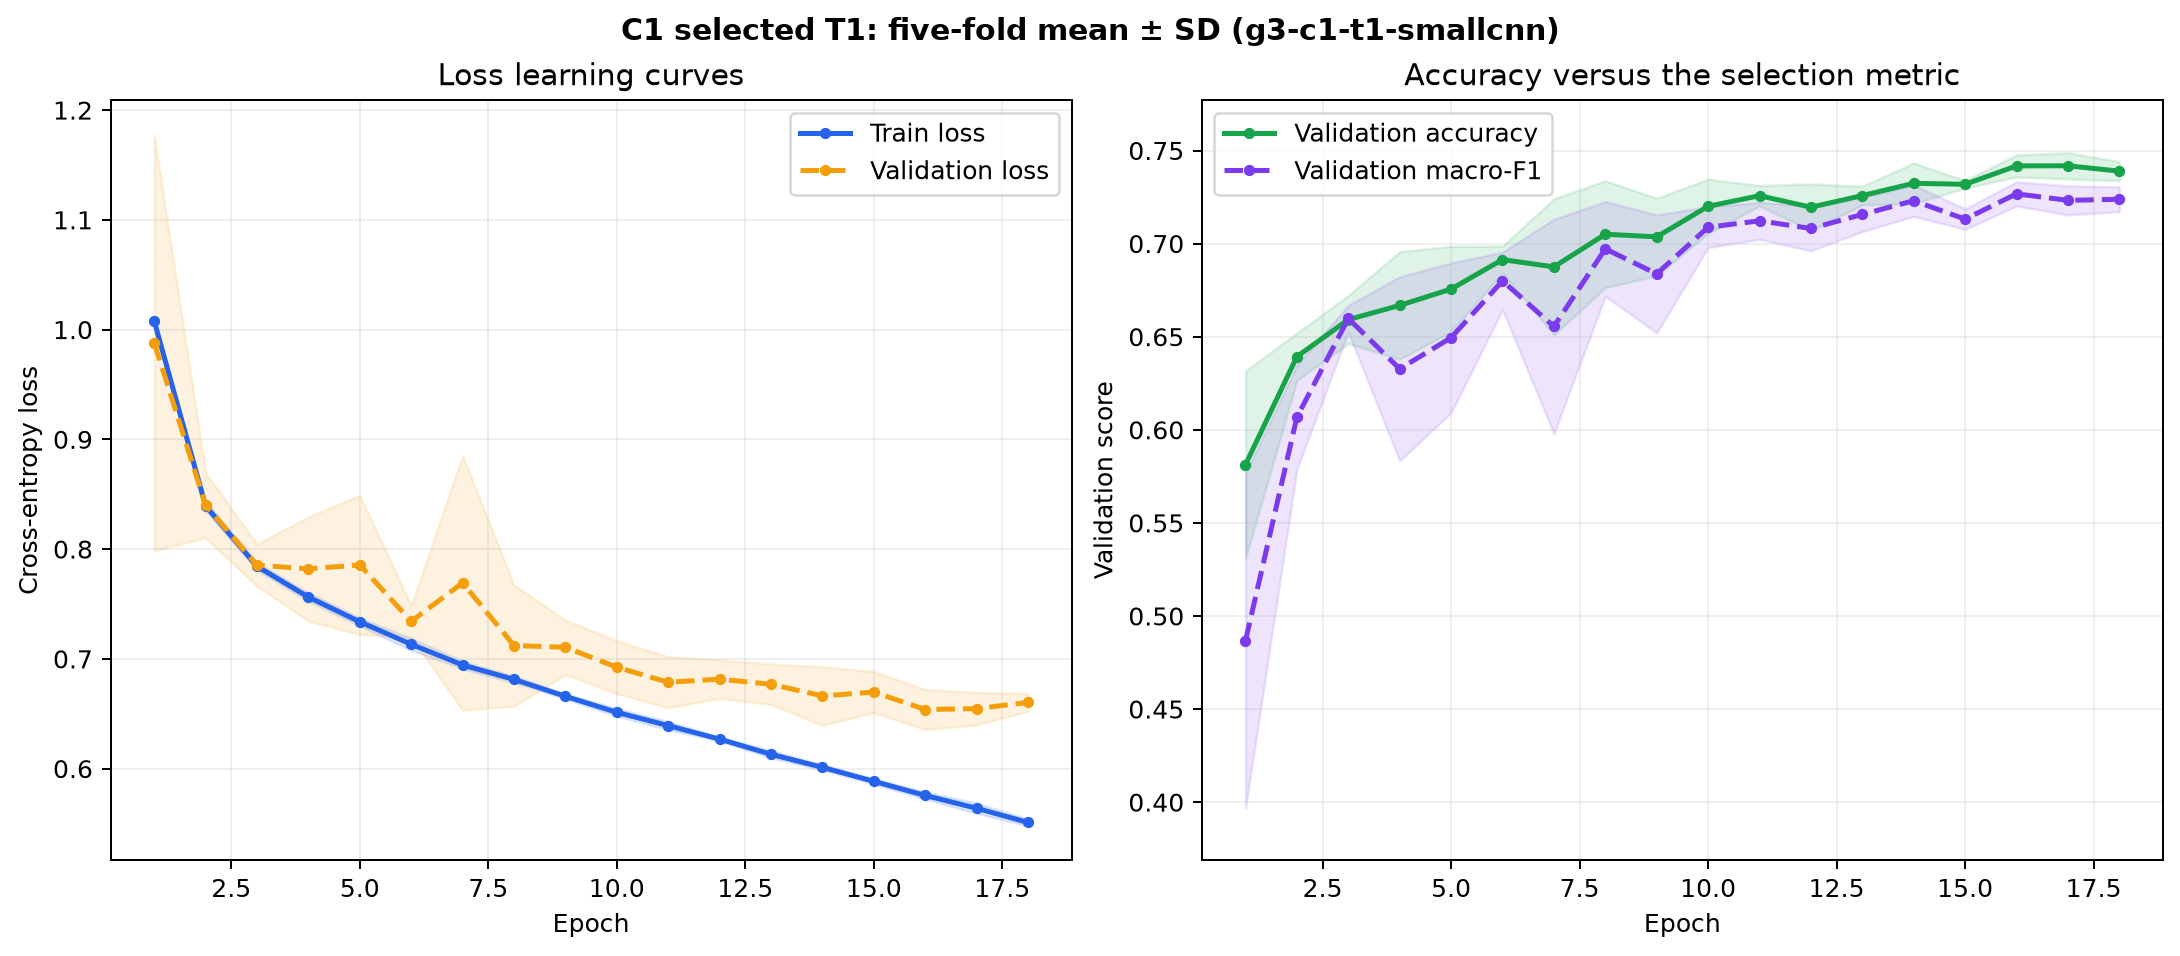

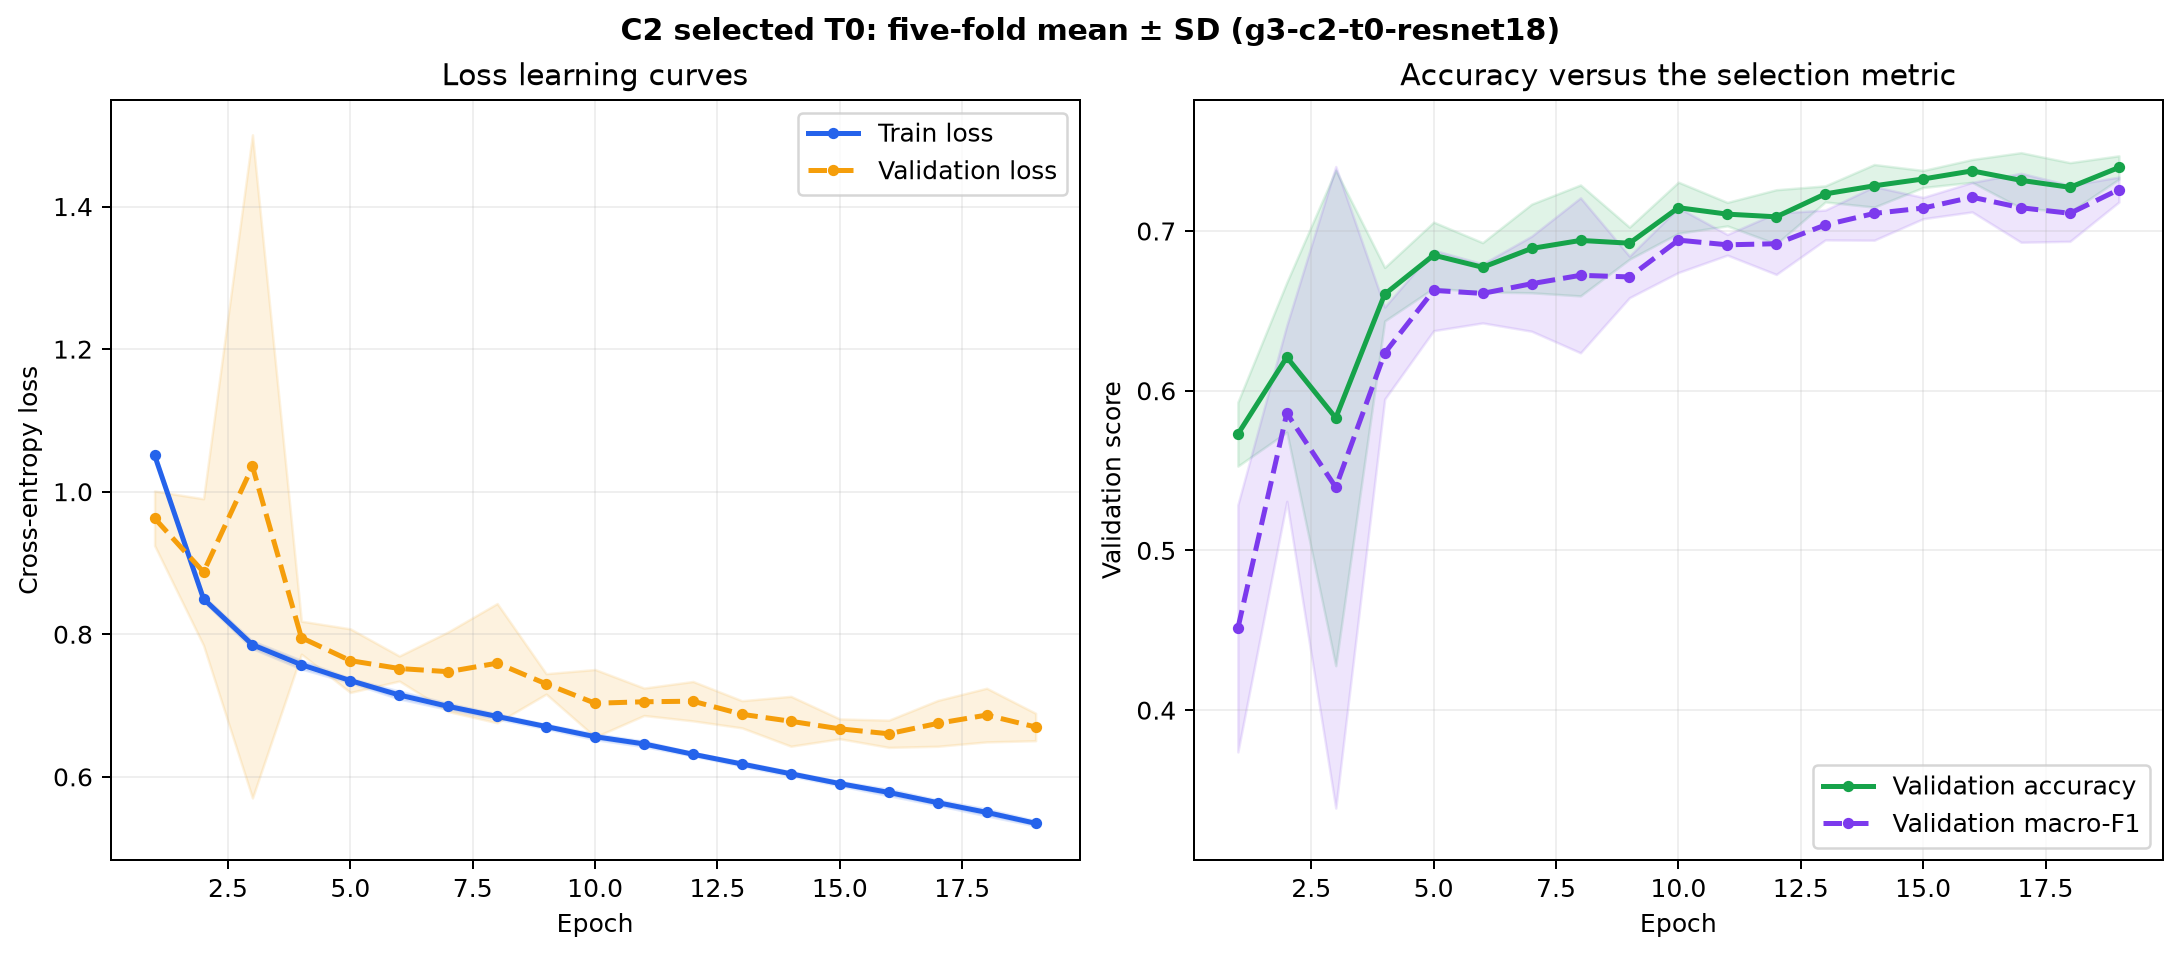

In [24]:
from fashion.task2.evidence import build_g3_full_budget_evidence
from fashion.train.registry import RunRegistry

g3_specs = {
    "g3-c1-t1-smallcnn": ("g3_c1_t1_smallcnn.json", "g3_c1_t1_smallcnn"),
    "g3-c2-t0-resnet18": ("g3_c2_t0_resnet18.json", "g3_c2_t0_resnet18"),
}
g3_probability_note = (
    "Uncalibrated softmax probabilities from the best validation macro-F1 "
    "checkpoint in each fold; calibration metrics are diagnostic only."
)
g3_registry = RunRegistry(RUNS_CSV)
g3_attempt_frames = []
g3_current_attempt_frames = []
for experiment_id, (config_name, evidence_slug) in g3_specs.items():
    outputs = run_or_load_experiment(
        TASK2_CONFIG_DIR / config_name,
        mode="run_or_load",
    )
    experiment_manifest = build_experiment_evidence(
        outputs,
        registry_path=RUNS_CSV,
        expected_ids=season_development["id"],
        protected_ids=protected_ids,
        probability_note=g3_probability_note,
        calibration_claim_allowed=False,
        evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
        figure_directory=TASK2_FIGURE_DIR,
    )
    assert experiment_manifest["experiment_id"] == experiment_id
    assert experiment_manifest["coverage"]["row_count"] == len(season_development)
    assert experiment_manifest["coverage"]["protected_id_count"] == 0
    assert len(experiment_manifest["run_ids"]) == 5

    current_run_ids = {output.run_id for output in outputs}
    assert len(current_run_ids) == 5
    assert set(experiment_manifest["run_ids"]) == current_run_ids
    attempts = g3_registry.find(experiment_id=experiment_id)
    current_attempts = attempts.loc[
        attempts["run_id"].isin(current_run_ids)
    ].copy()
    assert len(current_attempts) == 5
    assert current_attempts["status"].eq("completed").all()
    assert set(current_attempts["fold"].astype(int)) == set(range(5))
    assert not attempts["status"].eq("running").any()
    g3_current_attempt_frames.append(current_attempts)
    g3_attempt_frames.append(attempts)

g3_manifest = build_g3_full_budget_evidence(
    experiment_manifest_paths=[
        TASK2_EVIDENCE_DIR / evidence_slug / "manifest.json"
        for _, evidence_slug in g3_specs.values()
    ],
    experiment_config_paths=[
        TASK2_CONFIG_DIR / config_name
        for config_name, _ in g3_specs.values()
    ],
    tuning_manifest_path=TASK2_EVIDENCE_DIR / "g2_compact_tuning/manifest.json",
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g3_full_budget",
    figure_directory=TASK2_FIGURE_DIR,
)
g3_leaderboard = pd.read_csv(
    ROOT / g3_manifest["artifacts"]["leaderboard"]["path"]
)
g3_paired_folds = pd.read_csv(
    ROOT / g3_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
g3_per_class = pd.read_csv(
    ROOT / g3_manifest["artifacts"]["per_class_comparison"]["path"]
)
g3_screen_to_full = pd.read_csv(
    ROOT / g3_manifest["artifacts"]["screen_to_full_budget"]["path"]
)
with (ROOT / g3_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    g3_decision = json.load(handle)

assert g3_manifest["gate"] == "G3-F"
assert g3_manifest["near_tie"] is True
assert g3_manifest["ultimate_winner_frozen"] is False
assert g3_manifest["provisional_reference_experiment_id"] == "g3-c1-t1-smallcnn"
assert g3_decision["common_five_fold_horizons"] == {"C1": 18, "C2": 19}
assert len(g3_paired_folds) == 5
assert len(g3_per_class) == len(SEASON_LABELS)

g3_current_attempts = pd.concat(g3_current_attempt_frames, ignore_index=True)
assert len(g3_current_attempts) == 10
assert g3_current_attempts["run_id"].nunique() == 10
assert g3_current_attempts["status"].eq("completed").all()
g3_attempts = pd.concat(g3_attempt_frames, ignore_index=True)
g3_interrupted_attempts = g3_attempts.loc[
    g3_attempts["status"].eq("interrupted")
].copy()
display(
    g3_leaderboard.style.format(
        {
            "learning_rate": "{:.4g}",
            "weight_decay": "{:.4g}",
            "pooled_macro_f1": "{:.6f}",
            "fold_sd_macro_f1": "{:.6f}",
            "spring_f1": "{:.6f}",
            "five_fold_runtime_minutes": "{:.2f}",
            "peak_vram_mb": "{:.1f}",
            "full_minus_screen_macro_f1": "{:+.6f}",
        }
    )
)
display(g3_screen_to_full.style.format({"pooled_macro_f1": "{:.6f}"}))
display(g3_paired_folds)
display(g3_per_class.style.format({"delta_c1_minus_c2_f1": "{:+.6f}"}))
display(pd.json_normalize(g3_decision, sep=".").transpose())
display(
    g3_attempts.loc[:, [
        "experiment_id",
        "fold",
        "run_id",
        "status",
        "error_type",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values(["experiment_id", "fold", "status"])
)
display(
    Image(filename=str(ROOT / g3_manifest["artifacts"]["c1_learning_curves"]["path"]))
)
display(
    Image(filename=str(ROOT / g3_manifest["artifacts"]["c2_learning_curves"]["path"]))
)

> **Interpretation:** **Incremental question:** after G1 shortlisted C2 for quality and C1 for efficiency, and G2 selected C1-T1 and C2-T0, does equal full-budget training change that ordering when seed `2753` also owns model initialisation? **Result:** C1 rose from `0.708075` to `0.737661` pooled OOF macro-F1 (`+0.029586`), while C2 rose from `0.707099` to `0.735036` (`+0.027936`). C1 leads by `0.002626`, below the frozen `0.005` near-tie threshold. **Class trade-off:** C1 is better on Fall (`+0.011802` F1) and Winter (`+0.004266`); C2 is better on Spring (`+0.002571`) and Summer (`+0.002993`). One pooled score therefore does not erase minority-class risk.

**Learning curves and EDA reflection:** the teacher-style left panels show five-fold mean plus SD for train and validation cross-entropy loss; the right panels show validation accuracy and the primary validation macro-F1. Both families still improve after the eight-epoch screen. Accuracy remains above macro-F1, so the EDA warning that the large Summer class can hide minority errors was accurate. The EDA expectation that a larger network should clearly help was not supported: mature C2 is still slightly behind compact C1. Training accuracy is absent because it was not logged; no value was invented. C1 is shown through epoch 18 and C2 through epoch 19, the last epoch shared by all five folds.

**Efficiency and decision:** C1 uses `1,174,244` parameters and `60.21` five-fold minutes; C2 uses `11,170,884` parameters and `91.58` minutes. C2 is `9.51×` larger and `1.52×` slower. Keep C1-T1 as the provisional reference, not the ultimate winner. C3 remains rejected because its equal-budget screen trailed C2 by `0.068604` and no later controlled result justifies full-budget compute. Retain C2 because it is slightly stronger on Spring and Summer. Next run I1 class balancing and I2 masked multi-task learning, then close second-seed, robustness, cost, and grouped-bootstrap checks before freezing. **Real process:** the first G3 attempt is preserved but invalid because its seed did not own model initialisation; it includes run `g3-c1-t1-smallcnn-f2-s2753-2283b6495a44`, which was interrupted outside Python, and clean replacement `g3-c1-t1-smallcnn-f2-s2753-e46d771b6d56`. The corrected ten-run evidence uses implementation commit `47442a2`. Its build exposed a separate minimum-delta history-audit bug, traced by commits `c46a0ff`, `a9c4800`, and `62e57e2`; no retraining was needed because the checkpoints were valid. **Trace:** `results/evidence/task2/g3_full_budget/manifest.json` hashes the two input manifests, two selected configs, ten corrected completed run records, paired folds, per-class results, full histories, the decision, and both learning-curve figures. Representative corrected runs are `g3-c1-t1-smallcnn-f0-s2753-1ce4f9978b12` and `g3-c2-t0-resnet18-f0-s2753-66ee7a85d5c6`. Probabilities remain uncalibrated diagnostics.

### 8.2 G2 transform and compact tuning ablations

Input size, augmentation, and tuning are separate factors. Each receives its own controlled subsubsection.

#### 8.2.1 P0 versus P1 input size

This ablation tests whether moderate upscaling helps the small source images.

,variant,experiment_id,image_height,image_width,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,spring_f1,five_fold_runtime_minutes,peak_vram_mb,parameter_count,config_sha256,split_sha256,label_map_sha256,implementation_sha256,transform_id,delta_vs_p0_macro_f1,delta_vs_p0_spring_f1,runtime_ratio_vs_p0,peak_vram_ratio_vs_p0
0,P0,g1-c2-resnet18,80,60,0.707099,0.706496,0.003872,0.738433,29.21,606.4,11170884,3fb4b56409c1fb3af03d0863cf69b0367fc1d23c84881a7307fdab978430f728,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-7dba8a62f166046d,+0.000000,+0.000000,1.000,1.000
1,P1,g2-p1-c2-resnet18,128,96,0.705312,0.705154,0.006467,0.738673,58.18,1321.9,11170884,ff7443db6f31e6b1ec72567d07e3a2b54e58f244c4ee60bc8ca499bb4b5c2119,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-a8878a801aa0d46e,-0.001787,+0.000239,1.992,2.180


,fold,p0_run_id,p1_run_id,p0_macro_f1,p1_macro_f1,delta_p1_minus_p0_macro_f1,runtime_ratio_p1_vs_p0
0,0,g1-c2-resnet18-f0-s2753-b91662d47026,g2-p1-c2-resnet18-f0-s2753-67217738d381,0.703758,0.699577,-0.004180,1.890105
1,1,g1-c2-resnet18-f1-s2753-a4ff07c863e4,g2-p1-c2-resnet18-f1-s2753-66a1b27539dc,0.705058,0.699985,-0.005073,1.733171
2,2,g1-c2-resnet18-f2-s2753-2d6a8dffa3fe,g2-p1-c2-resnet18-f2-s2753-b5a856f9e3b1,0.712810,0.712067,-0.000743,1.765478
3,3,g1-c2-resnet18-f3-s2753-f2eb5f7a2dac,g2-p1-c2-resnet18-f3-s2753-8e6b55d11e02,0.707456,0.712283,0.004827,2.376686
4,4,g1-c2-resnet18-f4-s2753-2449eed2ce12,g2-p1-c2-resnet18-f4-s2753-9294db7bbaf4,0.703396,0.701856,-0.001541,2.395523


,run_id,fold,status,git_commit,git_dirty,error_type,started_at_utc
0,g2-p1-c2-resnet18-f0-s2753-67217738d381,0,completed,c0563feb7192a0a93486d601773a6a14d108e0b0,false,,2026-08-26T17:30:19Z
1,g2-p1-c2-resnet18-f1-s2753-7327d09ce2cf,1,interrupted,c0563feb7192a0a93486d601773a6a14d108e0b0,false,ExternalProcessTermination,2026-08-26T17:42:28Z
2,g2-p1-c2-resnet18-f1-s2753-dce57b0c7883,1,interrupted,f4992e8fda7ff5f0b0b9239341ca7e3303d3267d,false,ExternalProcessTermination,2026-08-26T18:08:10Z
3,g2-p1-c2-resnet18-f1-s2753-48ece6ab6852,1,failed,f4992e8fda7ff5f0b0b9239341ca7e3303d3267d,false,RuntimeError,2026-08-26T18:08:17Z
4,g2-p1-c2-resnet18-f1-s2753-66a1b27539dc,1,completed,1fe31d48b2c67ba0b905bcc600a2cbf0194d2447,false,,2026-08-26T18:11:27Z
5,g2-p1-c2-resnet18-f2-s2753-b5a856f9e3b1,2,completed,1fe31d48b2c67ba0b905bcc600a2cbf0194d2447,false,,2026-08-26T18:23:10Z
6,g2-p1-c2-resnet18-f3-s2753-8e6b55d11e02,3,completed,1fe31d48b2c67ba0b905bcc600a2cbf0194d2447,false,,2026-08-26T18:35:14Z
7,g2-p1-c2-resnet18-f4-s2753-9294db7bbaf4,4,completed,1fe31d48b2c67ba0b905bcc600a2cbf0194d2447,false,,2026-08-26T18:47:21Z


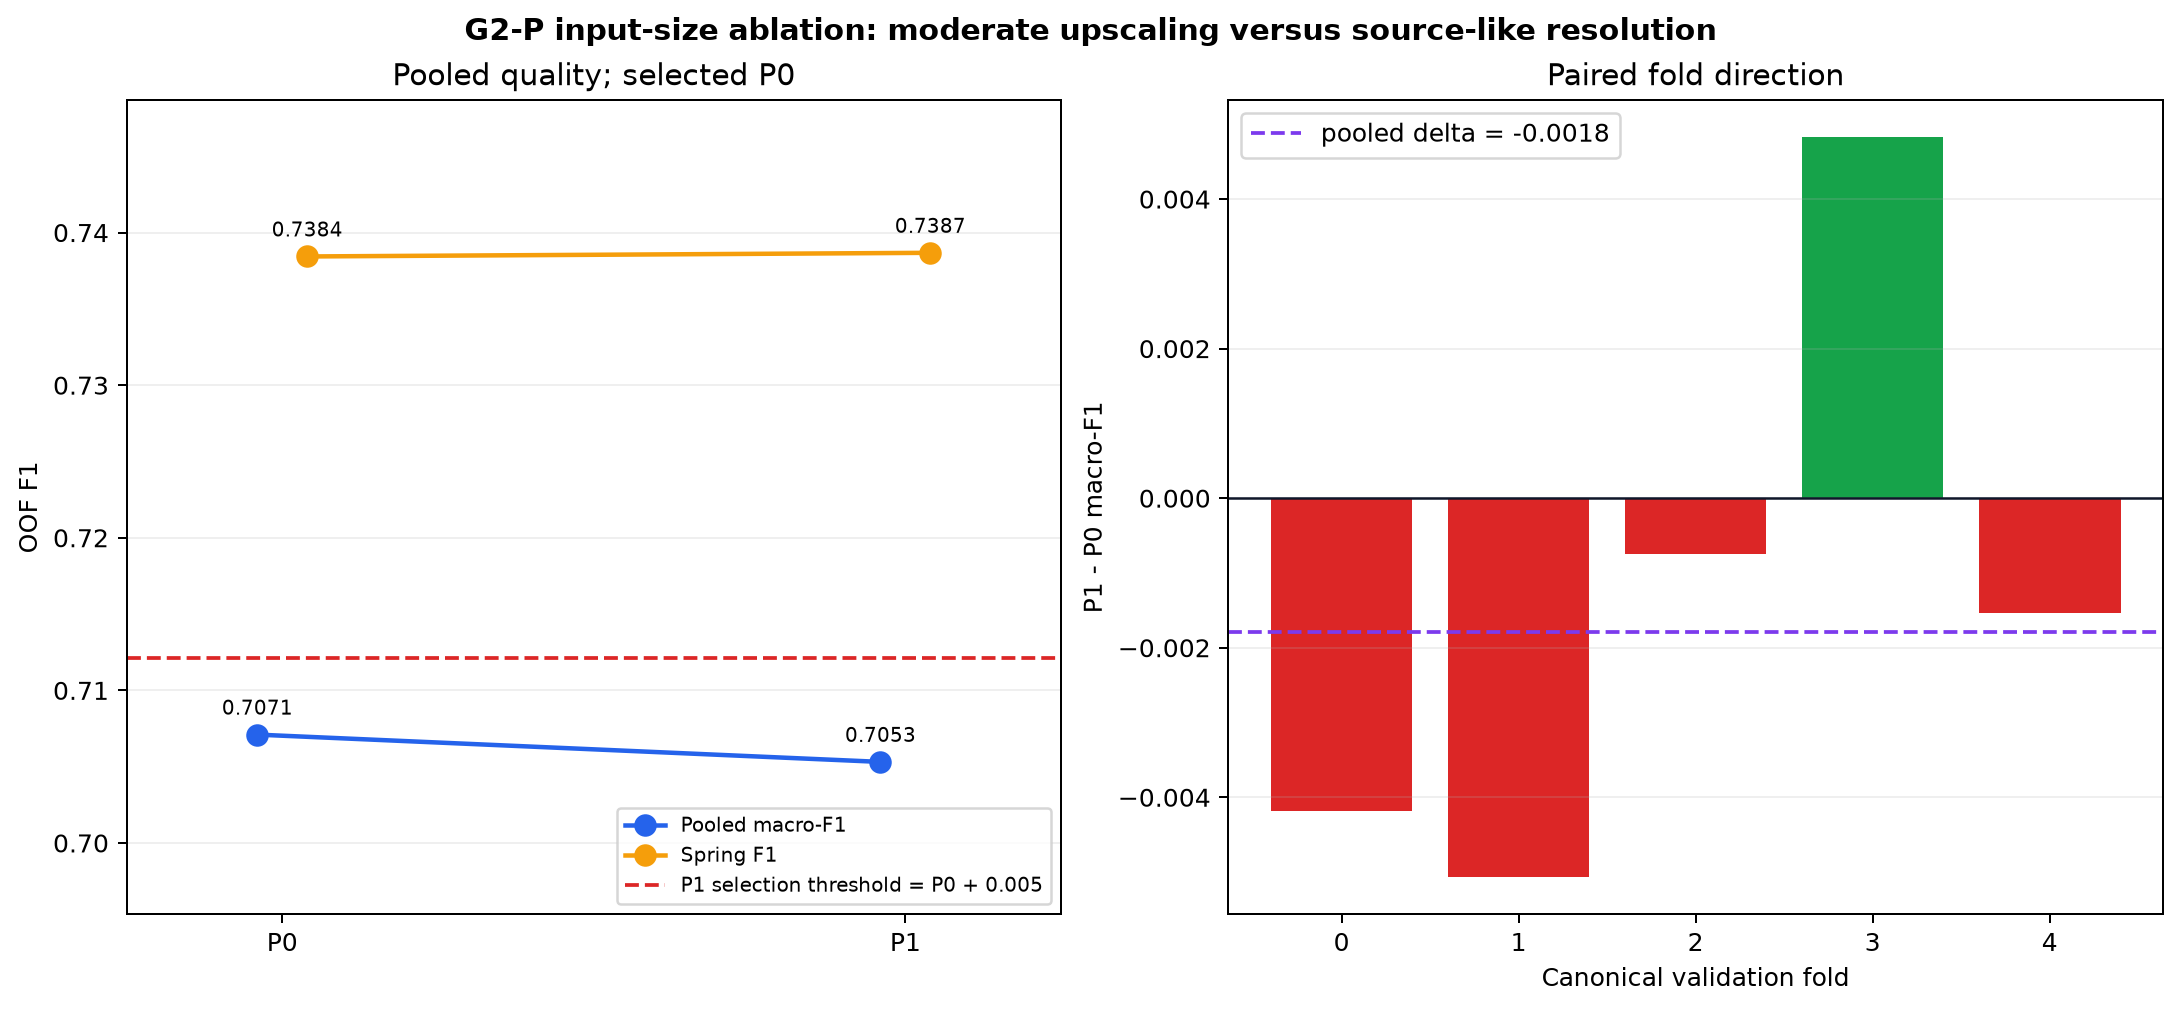

In [25]:
from fashion.task2.evidence import build_g2_input_size_evidence

g2_probability_note = (
    "Softmax probabilities come from each fold's best validation macro-F1 "
    "checkpoint. They are uncalibrated until the dedicated cross-fitted "
    "calibration gate, so current NLL, Brier, and ECE are diagnostics only."
)
g2_p1_outputs = run_or_load_experiment(
    TASK2_CONFIG_DIR / "g2_p1_c2_resnet18.json",
    mode="run_or_load",
)
g2_p1_manifest = build_experiment_evidence(
    g2_p1_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=g2_probability_note,
    calibration_claim_allowed=False,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_p1_c2_resnet18",
    figure_directory=TASK2_FIGURE_DIR,
)
assert g2_p1_manifest["coverage"]["row_count"] == len(season_development)
assert g2_p1_manifest["coverage"]["protected_id_count"] == 0
assert len(g2_p1_manifest["run_ids"]) == 5

g2_size_manifest = build_g2_input_size_evidence(
    p0_manifest_path=TASK2_EVIDENCE_DIR / "g1_c2_resnet18/manifest.json",
    p1_manifest_path=TASK2_EVIDENCE_DIR / "g2_p1_c2_resnet18/manifest.json",
    p0_config_path=TASK2_CONFIG_DIR / "g1_c2_resnet18.json",
    p1_config_path=TASK2_CONFIG_DIR / "g2_p1_c2_resnet18.json",
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_input_size_ablation",
    figure_directory=TASK2_FIGURE_DIR,
)
g2_size_comparison = pd.read_csv(
    ROOT / g2_size_manifest["artifacts"]["comparison"]["path"]
)
g2_size_paired_folds = pd.read_csv(
    ROOT / g2_size_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
with (ROOT / g2_size_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    g2_size_decision = json.load(handle)
assert g2_size_decision["selected_variant"] == "P0"
assert g2_size_decision["minimum_gain"] == 0.005

g2_p1_attempts = RunRegistry(RUNS_CSV).find(
    experiment_id="g2-p1-c2-resnet18"
)
assert len(g2_p1_attempts.loc[g2_p1_attempts["status"].eq("completed")]) == 5
assert not g2_p1_attempts["status"].eq("running").any()
display(
    g2_size_comparison.style.format(
        {
            "pooled_macro_f1": "{:.6f}",
            "fold_sd_macro_f1": "{:.6f}",
            "spring_f1": "{:.6f}",
            "delta_vs_p0_macro_f1": "{:+.6f}",
            "delta_vs_p0_spring_f1": "{:+.6f}",
            "five_fold_runtime_minutes": "{:.2f}",
            "peak_vram_mb": "{:.1f}",
            "runtime_ratio_vs_p0": "{:.3f}",
            "peak_vram_ratio_vs_p0": "{:.3f}",
        }
    )
)
display(
    g2_size_paired_folds.loc[:, [
        "fold",
        "p0_run_id",
        "p1_run_id",
        "p0_macro_f1",
        "p1_macro_f1",
        "delta_p1_minus_p0_macro_f1",
        "runtime_ratio_p1_vs_p0",
    ]]
)
display(
    g2_p1_attempts.loc[:, [
        "run_id",
        "fold",
        "status",
        "git_commit",
        "git_dirty",
        "error_type",
        "started_at_utc",
    ]].sort_values(["fold", "started_at_utc"])
)
display(
    Image(filename=str(ROOT / g2_size_manifest["artifacts"]["figure"]["path"]))
)

> **Interpretation:** **Result:** P0 `(80, 60)` achieved `0.707099` pooled five-fold OOF macro-F1 (fold SD `0.003872`; Spring F1 `0.738433`). P1 `(128, 96)` achieved `0.705312` (SD `0.006467`; Spring F1 `0.738673`). The P1-minus-P0 pooled delta was `-0.001787` (-0.179 percentage points), and four of five paired fold deltas favoured P0; only fold 3 favoured P1 (`+0.004827`). P1's Spring gain was only `+0.000239` (+0.024 points). P1 took `58.18` training minutes versus `29.21` for P0 (`1.992` times) and peaked at `1,321.9` MB versus `606.4` MB VRAM (`2.180` times), with the same `11,170,884` parameters. **Meaning:** moderate upscaling added interpolation and almost doubled measured training cost without adding pooled discrimination. **Decision:** retain P0 because P1 did not meet the frozen `+0.005` macro-F1 rule; run A0 versus A1 on C2 at `(80, 60)`. **Limitation:** this is an eight-epoch, one-seed transform screen; its softmax outputs are uncalibrated and it does not replace later robustness analysis. **Trace:** `results/evidence/task2/g2_input_size_ablation/manifest.json` hashes both configs, both experiment manifests, the paired-fold table, decision, and figure. P1 evidence runs were `g2-p1-c2-resnet18-f0-s2753-67217738d381`, `g2-p1-c2-resnet18-f1-s2753-66a1b27539dc`, `g2-p1-c2-resnet18-f2-s2753-b5a856f9e3b1`, `g2-p1-c2-resnet18-f3-s2753-8e6b55d11e02`, and `g2-p1-c2-resnet18-f4-s2753-9294db7bbaf4`. Three non-evidence attempts remain visible in the local registry: `g2-p1-c2-resnet18-f1-s2753-7327d09ce2cf` and `g2-p1-c2-resnet18-f1-s2753-dce57b0c7883` were interrupted; `g2-p1-c2-resnet18-f1-s2753-48ece6ab6852` failed because the first Windows background runner lacked a safe `__main__` guard. None enters the five completed OOF rows.

#### 8.2.2 A0 versus A1 augmentation

This ablation tests whether mild colour jitter helps generalisation without erasing genuine seasonal colour cues.

,variant,experiment_id,image_height,image_width,augmentation,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,spring_f1,five_fold_runtime_minutes,peak_vram_mb,parameter_count,config_sha256,split_sha256,label_map_sha256,implementation_sha256,transform_id,delta_vs_a0_macro_f1,delta_vs_a0_spring_f1,runtime_ratio_vs_a0,peak_vram_ratio_vs_a0
0,A0,g1-c2-resnet18,80,60,a0,0.707099,0.706496,0.003872,0.738433,29.21,606.4,11170884,3fb4b56409c1fb3af03d0863cf69b0367fc1d23c84881a7307fdab978430f728,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-7dba8a62f166046d,+0.000000,+0.000000,1.000,1.000000
1,A1,g2-a1-c2-resnet18,80,60,a1,0.696662,0.696508,0.006778,0.727354,24.56,606.4,11170884,63dec6a1f8e8f84480325baf86453a200506362ec8e5440afa580d77512c2dff,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a1-fe8cc596054e42b2,-0.010438,-0.011079,0.841,1.000000


,fold,a0_run_id,a1_run_id,a0_macro_f1,a1_macro_f1,delta_a1_minus_a0_macro_f1
0,0,g1-c2-resnet18-f0-s2753-b91662d47026,g2-a1-c2-resnet18-f0-s2753-c4cc0669c376,0.703758,0.702169,-0.001589
1,1,g1-c2-resnet18-f1-s2753-a4ff07c863e4,g2-a1-c2-resnet18-f1-s2753-a0b2fe0bb37e,0.705058,0.686624,-0.018434
2,2,g1-c2-resnet18-f2-s2753-2d6a8dffa3fe,g2-a1-c2-resnet18-f2-s2753-af05d32916be,0.712810,0.693078,-0.019732
3,3,g1-c2-resnet18-f3-s2753-f2eb5f7a2dac,g2-a1-c2-resnet18-f3-s2753-b00dcb438d77,0.707456,0.697783,-0.009673
4,4,g1-c2-resnet18-f4-s2753-2449eed2ce12,g2-a1-c2-resnet18-f4-s2753-170d6fa1d34a,0.703396,0.702884,-0.000513


,label,support,a0_precision,a1_precision,delta_a1_minus_a0_precision,a0_recall,a1_recall,delta_a1_minus_a0_recall,a0_f1,a1_f1,delta_a1_minus_a0_f1
0,Fall,8928,0.720339,0.757906,0.037567,0.552195,0.483199,-0.068996,0.625159,0.590150,-0.035008
1,Spring,1329,0.943794,0.893640,-0.050154,0.606471,0.613243,0.006772,0.738433,0.727354,-0.011079
2,Summer,16235,0.698506,0.680313,-0.018193,0.838251,0.866954,0.028703,0.762025,0.762377,0.000352
3,Winter,6261,0.746231,0.758608,0.012377,0.664111,0.661556,-0.002556,0.702780,0.706766,0.003985


,run_id,fold,status,git_commit,git_dirty,primary_metric_value
0,g2-a1-c2-resnet18-f0-s2753-c4cc0669c376,0,completed,7f7b7f04c6915f3c813443e0dedcc3b5b629f076,false,0.7021692125076077
1,g2-a1-c2-resnet18-f1-s2753-a0b2fe0bb37e,1,completed,7f7b7f04c6915f3c813443e0dedcc3b5b629f076,false,0.6866240392309381
2,g2-a1-c2-resnet18-f2-s2753-af05d32916be,2,completed,7f7b7f04c6915f3c813443e0dedcc3b5b629f076,false,0.6930780912593734
3,g2-a1-c2-resnet18-f3-s2753-b00dcb438d77,3,completed,7f7b7f04c6915f3c813443e0dedcc3b5b629f076,false,0.6977828467951942
4,g2-a1-c2-resnet18-f4-s2753-170d6fa1d34a,4,completed,7f7b7f04c6915f3c813443e0dedcc3b5b629f076,false,0.7028836465514346


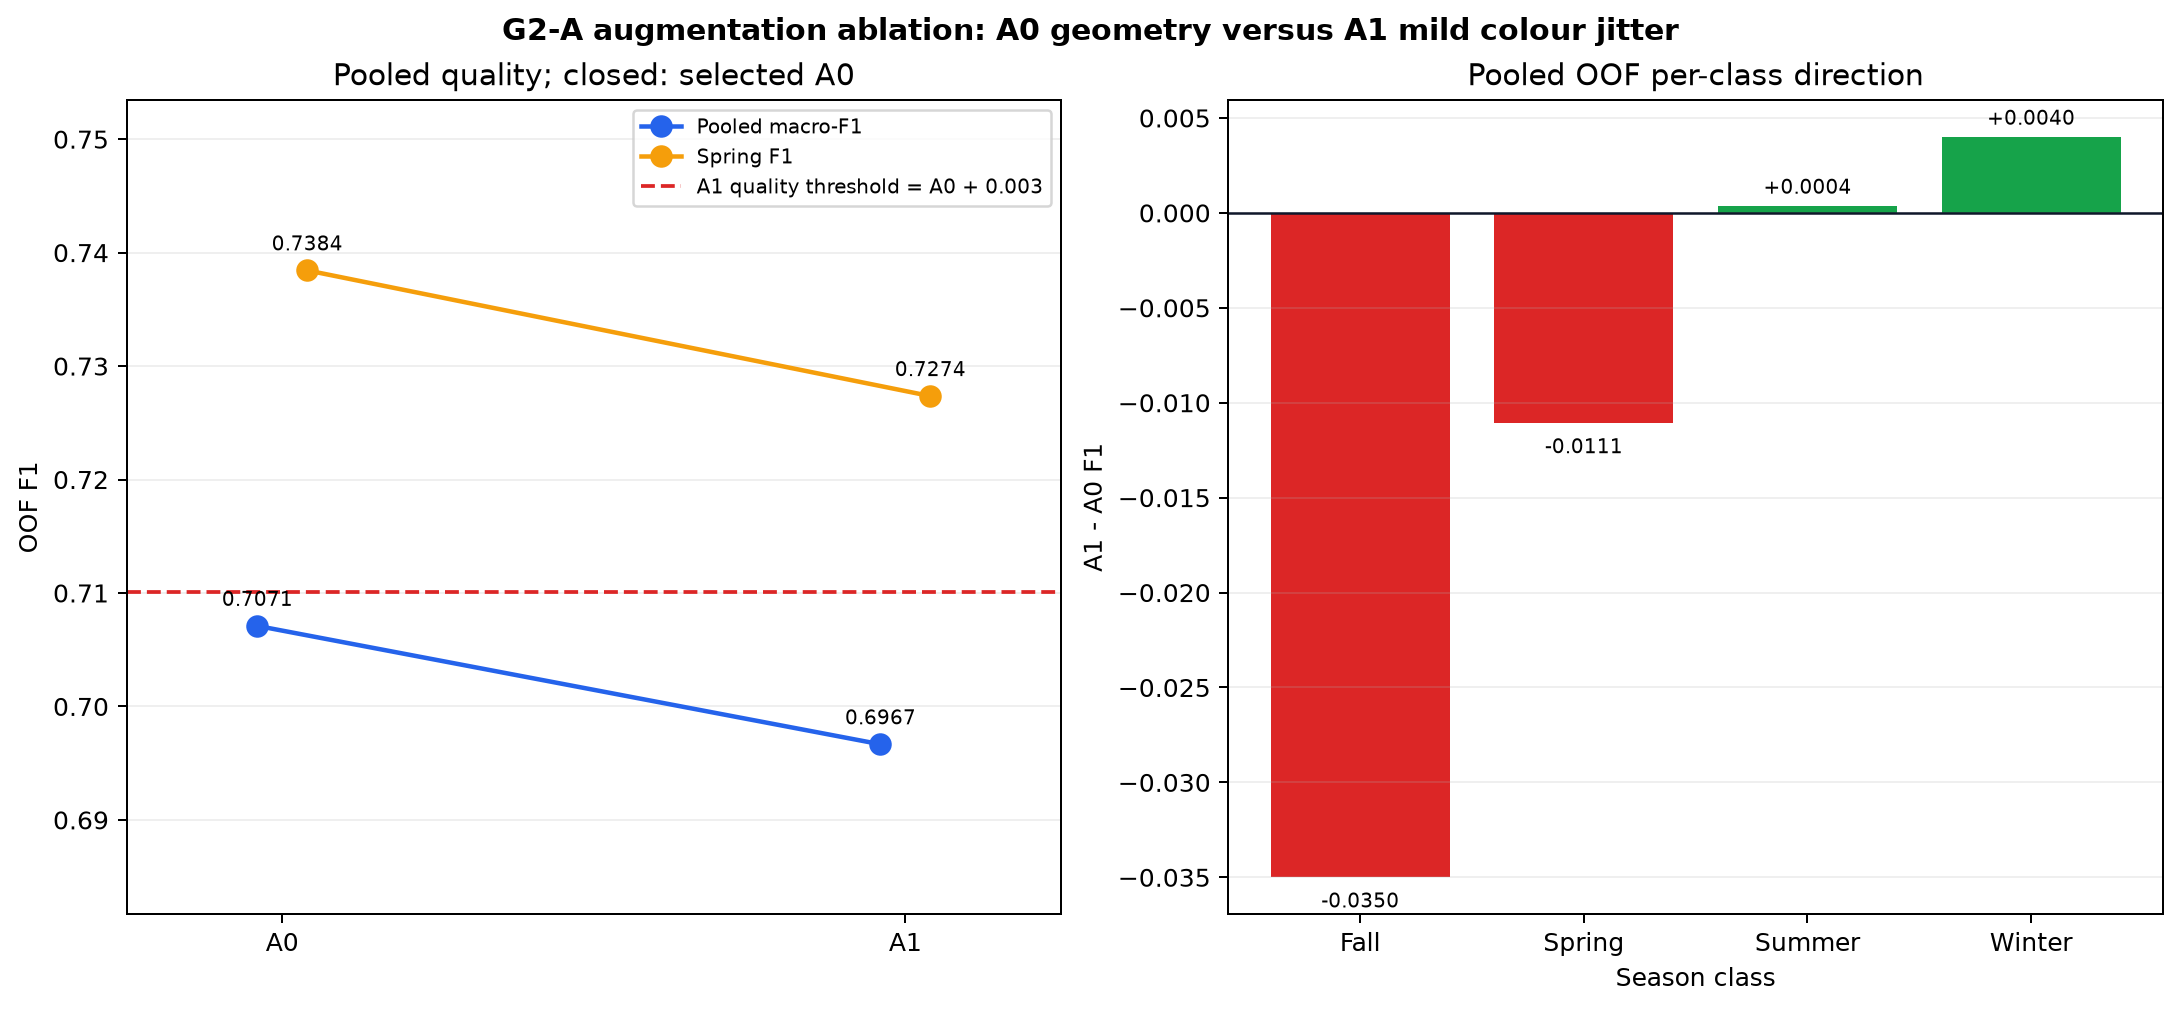

In [26]:
from fashion.task2.evidence import build_g2_augmentation_evidence

g2_a1_outputs = run_or_load_experiment(
    TASK2_CONFIG_DIR / "g2_a1_c2_resnet18.json",
    mode="run_or_load",
)
g2_a1_manifest = build_experiment_evidence(
    g2_a1_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=g2_probability_note,
    calibration_claim_allowed=False,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_a1_c2_resnet18",
    figure_directory=TASK2_FIGURE_DIR,
)
assert g2_a1_manifest["coverage"]["row_count"] == len(season_development)
assert g2_a1_manifest["coverage"]["protected_id_count"] == 0
assert len(g2_a1_manifest["run_ids"]) == 5

g2_augmentation_manifest = build_g2_augmentation_evidence(
    a0_manifest_path=TASK2_EVIDENCE_DIR / "g1_c2_resnet18/manifest.json",
    a1_manifest_path=TASK2_EVIDENCE_DIR / "g2_a1_c2_resnet18/manifest.json",
    a0_config_path=TASK2_CONFIG_DIR / "g1_c2_resnet18.json",
    a1_config_path=TASK2_CONFIG_DIR / "g2_a1_c2_resnet18.json",
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_augmentation_ablation",
    figure_directory=TASK2_FIGURE_DIR,
)
g2_augmentation_comparison = pd.read_csv(
    ROOT / g2_augmentation_manifest["artifacts"]["comparison"]["path"]
)
g2_augmentation_paired = pd.read_csv(
    ROOT / g2_augmentation_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
g2_augmentation_per_class = pd.read_csv(
    ROOT / g2_augmentation_manifest["artifacts"]["per_class_comparison"]["path"]
)
with (ROOT / g2_augmentation_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    g2_augmentation_decision = json.load(handle)
assert g2_augmentation_decision["decision_status"] == "closed"
assert not g2_augmentation_decision["quality_gate_passed"]
assert g2_augmentation_decision["robustness_evidence_status"] == "not_required"
assert g2_augmentation_decision["selected_variant"] == "A0"
assert (g2_augmentation_paired["delta_a1_minus_a0_macro_f1"] < 0).all()

g2_a1_attempts = RunRegistry(RUNS_CSV).find(
    experiment_id="g2-a1-c2-resnet18"
)
assert len(g2_a1_attempts.loc[g2_a1_attempts["status"].eq("completed")]) == 5
assert not g2_a1_attempts["status"].eq("running").any()
display(
    g2_augmentation_comparison.style.format(
        {
            "pooled_macro_f1": "{:.6f}",
            "fold_sd_macro_f1": "{:.6f}",
            "spring_f1": "{:.6f}",
            "delta_vs_a0_macro_f1": "{:+.6f}",
            "delta_vs_a0_spring_f1": "{:+.6f}",
            "five_fold_runtime_minutes": "{:.2f}",
            "runtime_ratio_vs_a0": "{:.3f}",
            "peak_vram_mb": "{:.1f}",
        }
    )
)
display(
    g2_augmentation_paired.loc[:, [
        "fold",
        "a0_run_id",
        "a1_run_id",
        "a0_macro_f1",
        "a1_macro_f1",
        "delta_a1_minus_a0_macro_f1",
    ]]
)
display(
    g2_augmentation_per_class.loc[:, [
        "label",
        "support",
        "a0_precision",
        "a1_precision",
        "delta_a1_minus_a0_precision",
        "a0_recall",
        "a1_recall",
        "delta_a1_minus_a0_recall",
        "a0_f1",
        "a1_f1",
        "delta_a1_minus_a0_f1",
    ]].style.format(precision=6)
)
display(
    g2_a1_attempts.loc[:, [
        "run_id",
        "fold",
        "status",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values("fold")
)
display(
    Image(
        filename=str(
            ROOT / g2_augmentation_manifest["artifacts"]["figure"]["path"]
        )
    )
)

> **Interpretation:** **Result:** A0 achieved `0.707099` pooled five-fold OOF macro-F1 (fold SD `0.003872`; Spring F1 `0.738433`). A1 achieved `0.696662` (SD `0.006778`; Spring F1 `0.727354`). The A1-minus-A0 pooled delta was `-0.010438` (-1.044 percentage points), far below the frozen `+0.003` requirement, and every paired fold favoured A0. A1 changed class F1 by Fall `-0.035008`, Spring `-0.011079`, Summer `+0.000352`, and Winter `+0.003985`. Spring recall rose slightly (`+0.006772`), but precision fell much more (`-0.050154`); Fall recall fell by `-0.068996`. **Meaning:** mild colour jitter did not act as useful regularisation here. It removed colour information that helped distinguish Fall and Spring, while its tiny Summer and Winter gains did not offset those losses. **Decision:** retain A0 at P0 `(80, 60)`. Robustness evidence is explicitly `not_required` because A1 already failed the first condition of the frozen AND rule; running extra robustness probes cannot make A1 eligible. **Limitation:** this is an eight-epoch, one-seed transform screen. The later second-seed finalist check still tests stability, but all five negative paired-fold deltas make the present rejection consistent rather than fold-specific. **Trace:** `results/evidence/task2/g2_augmentation_ablation/manifest.json` hashes both configs, both experiment manifests, the paired-fold table, per-class comparison, decision, and figure. The five A1 run IDs are displayed above and remain linked to clean registry rows.

#### 8.2.3 Compact finalist tuning

A small predeclared search avoids an open-ended hunt for a lucky configuration. The learning-curve layout follows the familiar two-panel diagnostic: loss on the left and validation scores on the right. Macro-F1 is shown beside accuracy because it, not accuracy, is the frozen selection metric.

,family,tuning_id,experiment_id,model_family,learning_rate,weight_decay,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,spring_f1,five_fold_runtime_minutes,peak_vram_mb,parameter_count,config_sha256,split_sha256,label_map_sha256,implementation_sha256,transform_id,rank_within_family,delta_vs_t0_macro_f1,eligible_to_replace_t0,selected
0,C1,T0,g1-c1-smallcnn,smallcnn,0.0003,0.0001,0.699902,0.699752,0.010936,0.726168,19.11,191.4,1174244,430700d1080d33fc04337138f41c42ef55e25cdaeb6b1df35e979093197df754,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-7dba8a62f166046d,3,+0.000000,False,False
1,C1,T1,g2-t1-c1-smallcnn,smallcnn,0.001,0.0001,0.708075,0.707455,0.007322,0.741112,8.76,191.4,1174244,f93bc6529d0933ed5609ed4b0f73fb807622a59d45477c635f9141ba78027f62,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-7dba8a62f166046d,1,+0.008173,True,True
2,C1,T2,g2-t2-c1-smallcnn,smallcnn,0.0003,0.001,0.700275,0.700192,0.009631,0.727951,9.29,191.4,1174244,b7cef89fd10d8dcf4b9137552fc03927d65d12e91332fe72f01c52bd62d06d3f,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-7dba8a62f166046d,2,+0.000373,False,False
3,C2,T0,g1-c2-resnet18,resnet18_small_stem,0.0003,0.0001,0.707099,0.706496,0.003872,0.738433,29.21,606.4,11170884,3fb4b56409c1fb3af03d0863cf69b0367fc1d23c84881a7307fdab978430f728,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-7dba8a62f166046d,2,+0.000000,False,True
4,C2,T1,g2-t1-c2-resnet18,resnet18_small_stem,0.001,0.0001,0.700537,0.700306,0.005874,0.736022,25.80,606.4,11170884,96615ed4cbcdf3c337c3b6733c450ebfb399e6334836ce40cc747f7cbb548633,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-7dba8a62f166046d,3,-0.006562,False,False
5,C2,T2,g2-t2-c2-resnet18,resnet18_small_stem,0.0003,0.001,0.708246,0.708134,0.009896,0.740100,26.30,606.4,11170884,0a863aeb8e95c87de4a88edab815bf192d7c94598357b42faa43c6b1e17cf5a0,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-7dba8a62f166046d,1,+0.001146,False,False


,family,tuning_id,fold,t0_run_id,t0_macro_f1,candidate_run_id,candidate_macro_f1,delta_candidate_minus_t0_macro_f1
0,C1,T1,0,g1-c1-smallcnn-f0-s2753-59e9743d3899,0.699749,g2-t1-c1-smallcnn-f0-s2753-b5a391a13f44,0.711589,0.011840
1,C1,T1,1,g1-c1-smallcnn-f1-s2753-f73cfae4a798,0.683056,g2-t1-c1-smallcnn-f1-s2753-224fea686af6,0.700585,0.017528
2,C1,T1,2,g1-c1-smallcnn-f2-s2753-8e178abd5435,0.710146,g2-t1-c1-smallcnn-f2-s2753-def58df2b19c,0.710725,0.000579
3,C1,T1,3,g1-c1-smallcnn-f3-s2753-bf3525f7f30f,0.708893,g2-t1-c1-smallcnn-f3-s2753-b3d10cc6ac45,0.715534,0.006641
4,C1,T1,4,g1-c1-smallcnn-f4-s2753-476a7394ed3e,0.696914,g2-t1-c1-smallcnn-f4-s2753-078e0f55f905,0.698840,0.001926
5,C1,T2,0,g1-c1-smallcnn-f0-s2753-59e9743d3899,0.699749,g2-t2-c1-smallcnn-f0-s2753-6187b7f339ae,0.697510,-0.002239
6,C1,T2,1,g1-c1-smallcnn-f1-s2753-f73cfae4a798,0.683056,g2-t2-c1-smallcnn-f1-s2753-13a88ad7f93c,0.687552,0.004496
7,C1,T2,2,g1-c1-smallcnn-f2-s2753-8e178abd5435,0.710146,g2-t2-c1-smallcnn-f2-s2753-2993a3c5ac23,0.712706,0.002560
8,C1,T2,3,g1-c1-smallcnn-f3-s2753-bf3525f7f30f,0.708893,g2-t2-c1-smallcnn-f3-s2753-eaa85dafe6bf,0.706258,-0.002635
9,C1,T2,4,g1-c1-smallcnn-f4-s2753-476a7394ed3e,0.696914,g2-t2-c1-smallcnn-f4-s2753-29bfd73dd4dd,0.696931,0.000017


,step,pooled_macro_f1,selected_because,strength,limitation_exposed,next_question,source_evidence
0,B0 majority,0.165704,Measure the class-imbalance lower bound and audit folds.,"Cheap, deterministic, and leakage-safe.",No image discrimination; Spring F1 is zero.,Can fixed shape and colour features help?,results/evidence/task2/b0_majority/manifest.json
1,B1 HOG + HSV,0.609561,Test the EDA shape-and-colour hypothesis classically.,Serious and interpretable image-only baseline.,Fixed features and uncalibrated decision scores.,Can C1 learn better features end to end?,results/evidence/task2/b1_hog_hsv_svm/manifest.json
2,C1 SmallCNN T0,0.699902,Learn compact task-specific image features.,"1,174,244 parameters and competitive quality.",Simple capacity may miss wider spatial structure.,Does residual depth add enough value?,results/evidence/task2/g1_family_screen/manifest.json
3,C2 ResNet18 T0,0.707099,Test residual capacity with a small-image stem.,Best and most stable G1 screen score.,Much larger model for a small gain over C1.,Can an efficient alternative or tuning close the gap?,results/evidence/task2/g1_family_screen/manifest.json
4,C3 MobileNetV3 alternative,0.638495,Test the quality-to-cost deployment trade-off.,Lowest measured runtime and VRAM in G1.,Quality loss was too large; reject from tuning.,Compare only C1 and C2 under controlled changes.,results/evidence/task2/g1_family_screen/manifest.json
5,C1-T1 selected finalist,0.708075,Passed the frozen +0.003 tuning gain gate.,Compact C1 now matches the larger C2 screen score.,Eight epochs and one seed cannot freeze a winner.,Fully train C1-T1 versus retained C2-T0 fairly.,results/evidence/task2/g2_compact_tuning/manifest.json
6,C2-T0 retained finalist,0.707099,No tuning alternative gained at least +0.003.,Stable residual quality without post-result expansion.,Higher parameter and deployment cost than C1.,Fully train C2-T0 versus selected C1-T1 fairly.,results/evidence/task2/g2_compact_tuning/manifest.json


,earlier_eda_insight,verdict_after_measured_gates,measured_check,next_test
0,Class imbalance can make accuracy misleading.,supported,B0: 49.568% accuracy but 0.165704 macro-F1; Sp...,Keep macro-F1 primary; test I1 later.
1,Shape and colour contain useful Season signal.,supported,"B1 reached 0.609561 macro-F1, far above B0.","Use learned image features, then inspect errors."
2,Learned features should improve fixed HOG/HSV.,supported,C1 and C2 reached 0.699902 and 0.707099.,Run both finalists at the full matched budget.
3,More model capacity should clearly improve qua...,partly supported,"C2 beat C1-T0 by 0.007197, but C1-T1 reached 0...",Compare C1-T1 and C2-T0 for quality and cost.
4,A larger P1 input may preserve useful detail.,contradicted,P1 changed macro-F1 by -0.001787 and used 1.99...,Retain P0; do not add more image sizes.
5,Extra colour jitter may improve generalisation.,contradicted,A1 changed macro-F1 by -0.010438 and hurt Fall...,Retain A0; colour may be genuine signal.
6,"ArticleType, file size, and acquisition year m...",still untested,No current gate isolates these OOF slices.,"Measure conflict, size-quartile, and year slic..."


,artifact,path,sha256
0,incremental_model_selection,results/evidence/task2/selection_story/increme...,7dab1922a18ec8311dcede105386ec9fc036c0917866c0...
1,eda_reflection,results/evidence/task2/selection_story/eda_ref...,a754990c774a47196f254d4c5ef49576ee48e2e5fd824c...


,experiment_id,fold,run_id,status,git_commit,git_dirty,primary_metric_value
0,g2-t1-c1-smallcnn,0,g2-t1-c1-smallcnn-f0-s2753-b5a391a13f44,completed,51364b7de0c8686f999aa023ae0360c2878aaae2,false,0.711589283011932
1,g2-t1-c1-smallcnn,1,g2-t1-c1-smallcnn-f1-s2753-224fea686af6,completed,51364b7de0c8686f999aa023ae0360c2878aaae2,false,0.7005846603690098
2,g2-t1-c1-smallcnn,2,g2-t1-c1-smallcnn-f2-s2753-def58df2b19c,completed,51364b7de0c8686f999aa023ae0360c2878aaae2,false,0.7107252774556091
3,g2-t1-c1-smallcnn,3,g2-t1-c1-smallcnn-f3-s2753-b3d10cc6ac45,completed,51364b7de0c8686f999aa023ae0360c2878aaae2,false,0.715533826355243
4,g2-t1-c1-smallcnn,4,g2-t1-c1-smallcnn-f4-s2753-078e0f55f905,completed,51364b7de0c8686f999aa023ae0360c2878aaae2,false,0.6988402037918148
10,g2-t1-c2-resnet18,0,g2-t1-c2-resnet18-f0-s2753-b526dcae9e76,completed,51364b7de0c8686f999aa023ae0360c2878aaae2,false,0.6926940762553593
11,g2-t1-c2-resnet18,1,g2-t1-c2-resnet18-f1-s2753-e52955c401e9,completed,51364b7de0c8686f999aa023ae0360c2878aaae2,false,0.6958433790718304
12,g2-t1-c2-resnet18,2,g2-t1-c2-resnet18-f2-s2753-29d5ef810bf2,completed,51364b7de0c8686f999aa023ae0360c2878aaae2,false,0.7032541520109927
13,g2-t1-c2-resnet18,3,g2-t1-c2-resnet18-f3-s2753-41548f0fa802,completed,51364b7de0c8686f999aa023ae0360c2878aaae2,false,0.7070831089809126
14,g2-t1-c2-resnet18,4,g2-t1-c2-resnet18-f4-s2753-a5b09ce0eb52,completed,51364b7de0c8686f999aa023ae0360c2878aaae2,false,0.702654828196052


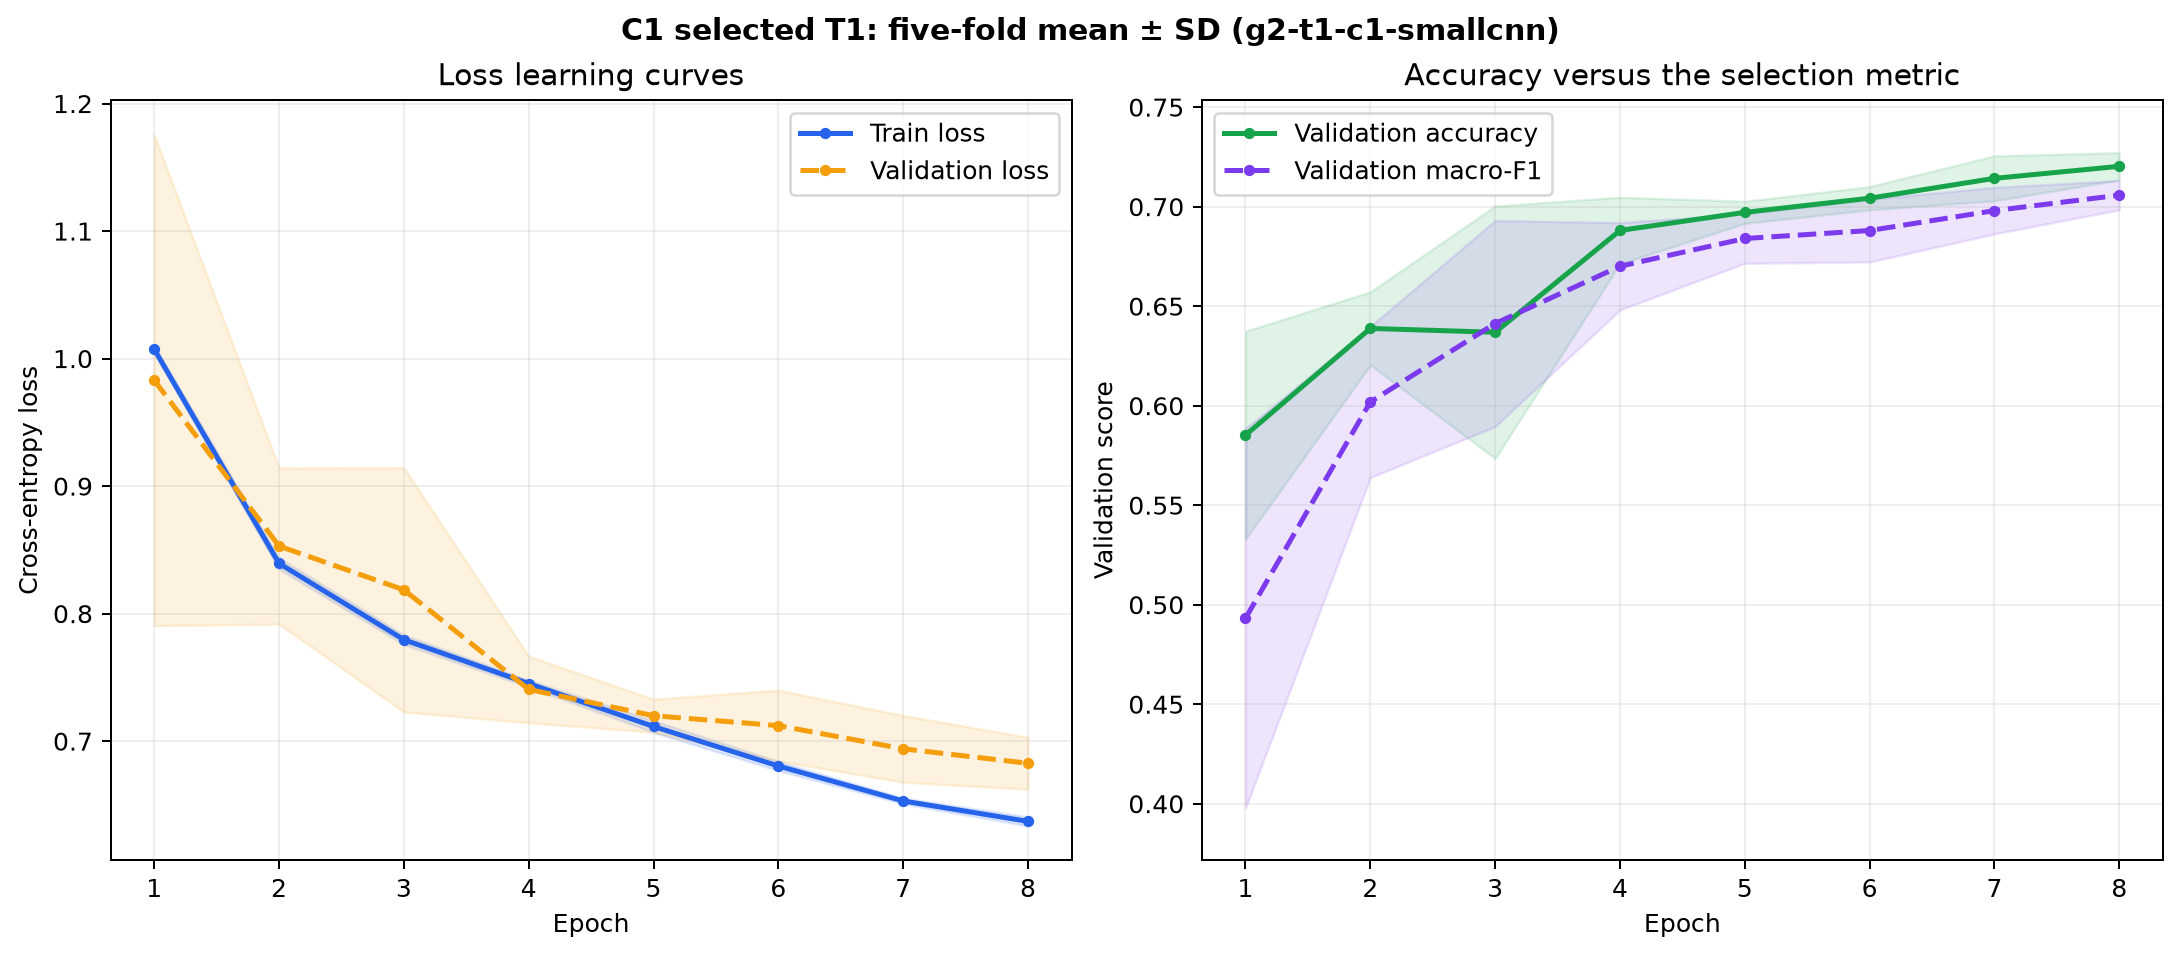

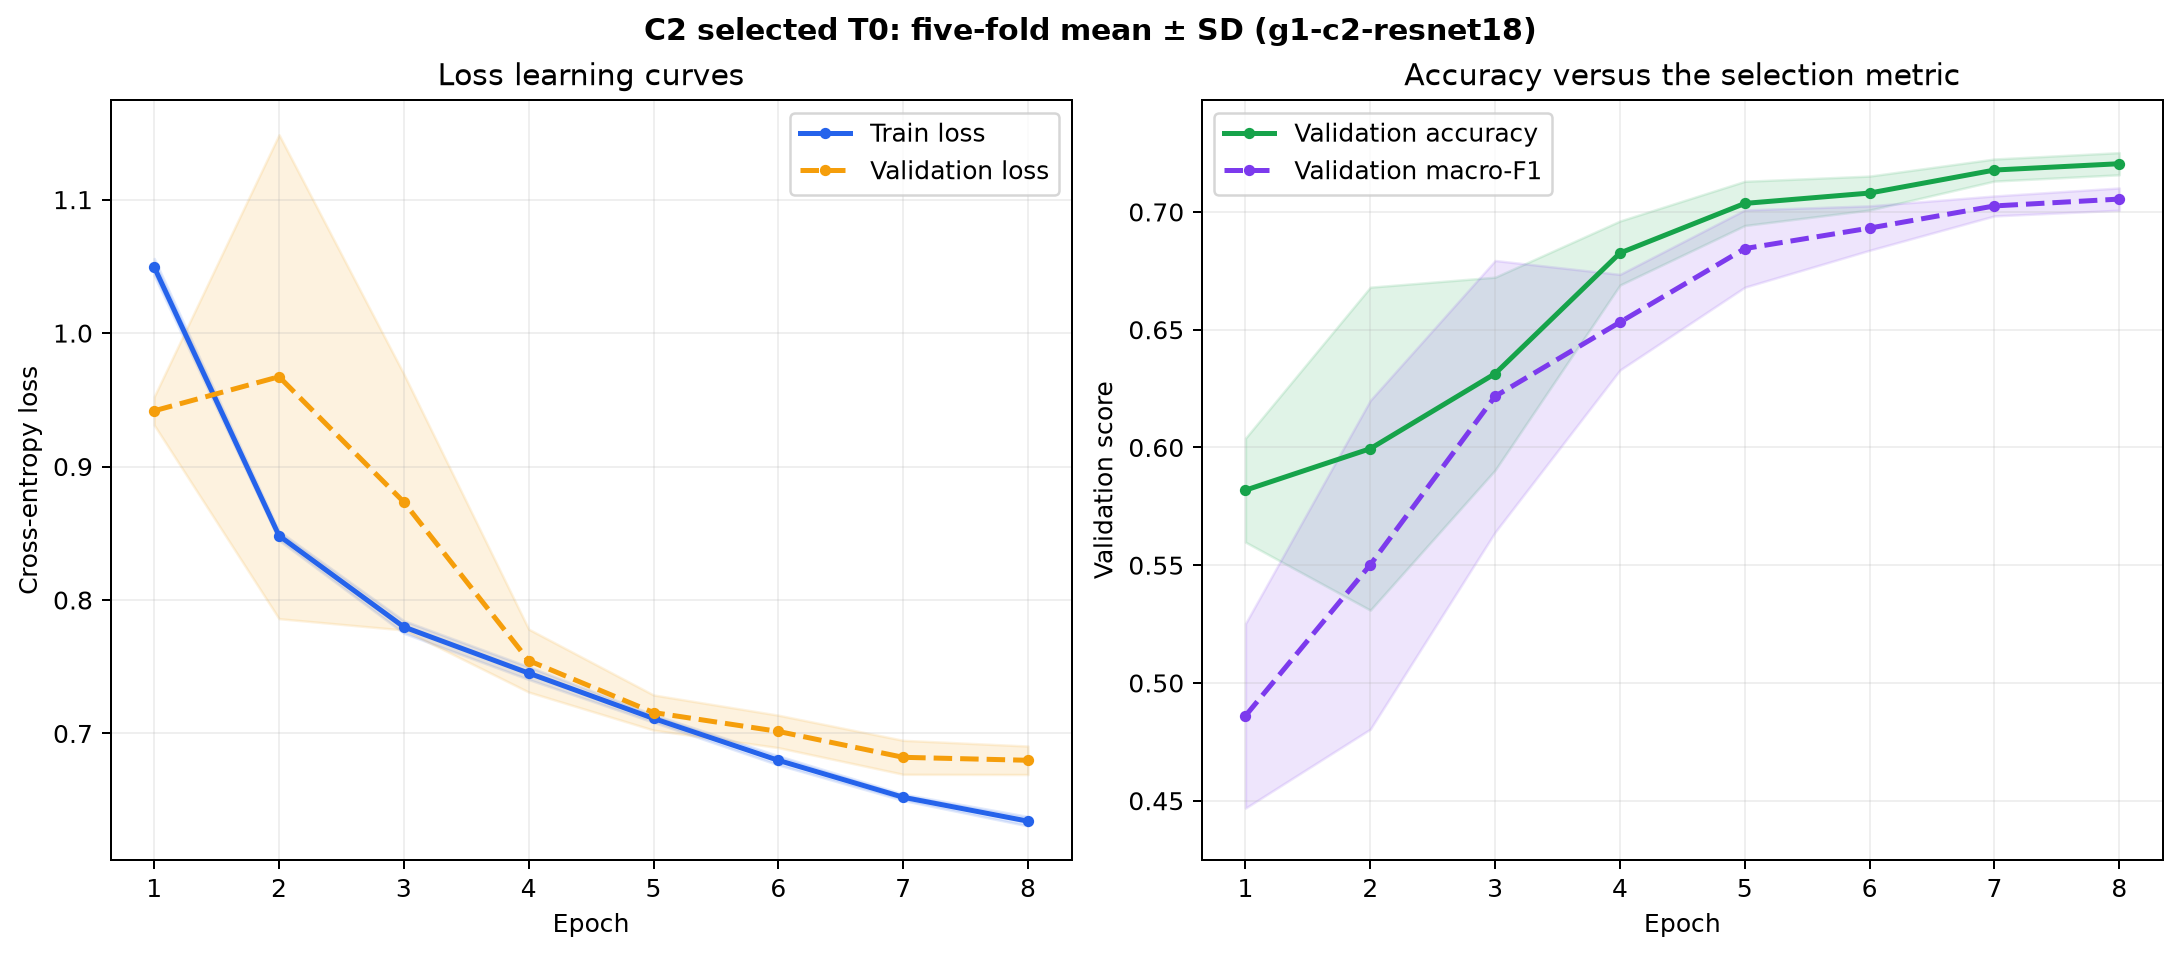

In [27]:
from fashion.task2.evidence import (
    build_g2_tuning_evidence,
    build_task2_selection_story_evidence,
)
from fashion.train.registry import RunRegistry

g2_new_tuning_specs = {
    "g2-t1-c1-smallcnn": ("g2_t1_c1_smallcnn.json", "g2_t1_c1_smallcnn"),
    "g2-t2-c1-smallcnn": ("g2_t2_c1_smallcnn.json", "g2_t2_c1_smallcnn"),
    "g2-t1-c2-resnet18": ("g2_t1_c2_resnet18.json", "g2_t1_c2_resnet18"),
    "g2-t2-c2-resnet18": ("g2_t2_c2_resnet18.json", "g2_t2_c2_resnet18"),
}
g2_tuning_attempt_frames = []
g2_registry = RunRegistry(RUNS_CSV)
for experiment_id, (config_name, evidence_slug) in g2_new_tuning_specs.items():
    outputs = run_or_load_experiment(
        TASK2_CONFIG_DIR / config_name,
        mode="run_or_load",
    )
    experiment_manifest = build_experiment_evidence(
        outputs,
        registry_path=RUNS_CSV,
        expected_ids=season_development["id"],
        protected_ids=protected_ids,
        probability_note=g2_probability_note,
        calibration_claim_allowed=False,
        evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
        figure_directory=TASK2_FIGURE_DIR,
    )
    assert experiment_manifest["experiment_id"] == experiment_id
    assert experiment_manifest["coverage"]["row_count"] == len(season_development)
    assert experiment_manifest["coverage"]["protected_id_count"] == 0
    assert len(experiment_manifest["run_ids"]) == 5

    attempts = g2_registry.find(experiment_id=experiment_id)
    completed = attempts.loc[attempts["status"].eq("completed")]
    assert len(completed) == 5
    assert set(completed["fold"].astype(int)) == set(range(5))
    assert not attempts["status"].eq("running").any()
    g2_tuning_attempt_frames.append(attempts)

g2_all_tuning_specs = {
    "g1-c1-smallcnn": ("g1_c1_smallcnn.json", "g1_c1_smallcnn"),
    "g2-t1-c1-smallcnn": ("g2_t1_c1_smallcnn.json", "g2_t1_c1_smallcnn"),
    "g2-t2-c1-smallcnn": ("g2_t2_c1_smallcnn.json", "g2_t2_c1_smallcnn"),
    "g1-c2-resnet18": ("g1_c2_resnet18.json", "g1_c2_resnet18"),
    "g2-t1-c2-resnet18": ("g2_t1_c2_resnet18.json", "g2_t1_c2_resnet18"),
    "g2-t2-c2-resnet18": ("g2_t2_c2_resnet18.json", "g2_t2_c2_resnet18"),
}
g2_tuning_manifest = build_g2_tuning_evidence(
    experiment_manifest_paths=[
        TASK2_EVIDENCE_DIR / evidence_slug / "manifest.json"
        for _, evidence_slug in g2_all_tuning_specs.values()
    ],
    experiment_config_paths=[
        TASK2_CONFIG_DIR / config_name
        for config_name, _ in g2_all_tuning_specs.values()
    ],
    augmentation_decision_path=(
        TASK2_EVIDENCE_DIR / "g2_augmentation_ablation/decision.json"
    ),
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_compact_tuning",
    figure_directory=TASK2_FIGURE_DIR,
)
selection_story_manifest = build_task2_selection_story_evidence(
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "selection_story",
)

g2_tuning_leaderboard = pd.read_csv(
    ROOT / g2_tuning_manifest["artifacts"]["leaderboard"]["path"]
)
g2_tuning_paired_folds = pd.read_csv(
    ROOT / g2_tuning_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
with (ROOT / g2_tuning_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    g2_tuning_decision = json.load(handle)
incremental_model_selection = pd.read_csv(
    ROOT
    / selection_story_manifest["artifacts"]["incremental_model_selection"]["path"]
)
eda_reflection = pd.read_csv(
    ROOT / selection_story_manifest["artifacts"]["eda_reflection"]["path"]
)

assert g2_tuning_decision["decision_status"] == "closed"
assert g2_tuning_decision["retained_transform"] == "P0/A0"
assert g2_tuning_decision["families"]["C1"]["selected_tuning_id"] == "T1"
assert g2_tuning_decision["families"]["C2"]["selected_tuning_id"] == "T0"
assert len(g2_tuning_leaderboard) == 6
assert len(g2_tuning_paired_folds) == 20
assert selection_story_manifest["selected_finalist_experiment_ids"] == [
    "g2-t1-c1-smallcnn",
    "g1-c2-resnet18",
]
assert selection_story_manifest["artifacts"]["incremental_model_selection"][
    "path"
].endswith("incremental_model_selection.csv")
assert selection_story_manifest["artifacts"]["eda_reflection"]["path"].endswith(
    "eda_reflection.csv"
)

g2_tuning_attempts = pd.concat(g2_tuning_attempt_frames, ignore_index=True)
assert not g2_tuning_attempts["status"].eq("running").any()
display(
    g2_tuning_leaderboard.style.format(
        {
            "learning_rate": "{:.4g}",
            "weight_decay": "{:.4g}",
            "pooled_macro_f1": "{:.6f}",
            "fold_sd_macro_f1": "{:.6f}",
            "spring_f1": "{:.6f}",
            "delta_vs_t0_macro_f1": "{:+.6f}",
            "five_fold_runtime_minutes": "{:.2f}",
            "peak_vram_mb": "{:.1f}",
        }
    )
)
display(g2_tuning_paired_folds)
display(incremental_model_selection.style.format({"pooled_macro_f1": "{:.6f}"}))
display(eda_reflection)
display(
    pd.DataFrame(
        [
            {"artifact": name, **declaration}
            for name, declaration in selection_story_manifest["artifacts"].items()
        ]
    )
)
display(
    g2_tuning_attempts.loc[:, [
        "experiment_id",
        "fold",
        "run_id",
        "status",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values(["experiment_id", "fold", "status"])
)
display(
    Image(
        filename=str(
            ROOT / g2_tuning_manifest["artifacts"]["c1_learning_curves"]["path"]
        )
    )
)
display(
    Image(
        filename=str(
            ROOT / g2_tuning_manifest["artifacts"]["c2_learning_curves"]["path"]
        )
    )
)

> **Interpretation:** **Incremental question:** after B0 exposed imbalance, B1 proved fixed shape/colour signal, and G1 showed learned features were better, G2-T asks only whether two frozen optimiser changes materially improve the shortlisted C1 and C2 families at retained P0/A0. **Result:** C1 scored T0 `0.699902`, T1 `0.708075` (`+0.008173`), and T2 `0.700275` (`+0.000373`); T1 passed the frozen `+0.003` gain rule. C2 scored T0 `0.707099`, T1 `0.700537` (`-0.006562`), and T2 `0.708246` (`+0.001146`); T2 was the best observed C2 score but did not pass the gain rule. **Learning curves:** the left panels show five-fold mean plus SD for train and validation loss; both decline, so optimisation is working. The right panels show validation accuracy and macro-F1; their persistent gap confirms that accuracy still hides minority-class errors. Training accuracy is not shown because it was not logged, and no value was invented. **EDA reflection:** the imbalance warning and the presence of shape/colour signal were supported. The ideas that a larger P1 image or extra A1 colour jitter would improve validation were contradicted. ArticleType, file size, and acquisition year shortcut risks are still untested and remain required OOF slices. **Decision:** select C1-T1 (`lr=1e-3`, `weight_decay=1e-4`) and retain C2-T0 (`lr=3e-4`, `weight_decay=1e-4`); do not expand the grid. Fully train those two at the same 30-epoch/patience-5 budget next. **Limitation:** this gate uses one seed and eight epochs, so it selects settings rather than the final model. **Trace:** `results/evidence/task2/g2_compact_tuning/manifest.json` hashes all six configs, all six experiment manifests, paired folds, per-class results, histories, decisions, and both charts. Selected C1-T1 includes `g2-t1-c1-smallcnn-f0-s2753-b5a391a13f44`; the rejected C2-T2 evidence includes `g2-t2-c2-resnet18-f2-s2753-c0de62f1594e`; each source manifest records all five completed run IDs.

### 8.3 G4 problem-driven improvements and benchmark

Class balance, multi-task learning, and pretrained comparison test different hypotheses and are separated below.

#### 8.3.1 I1 class-balanced loss

I1 directly tests whether fold-fitted reweighting improves the Spring minority.

,variant,experiment_id,loss_id,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,spring_f1,five_fold_runtime_minutes,peak_vram_mb,parameter_count,median_best_epoch,delta_macro_f1_vs_reference,delta_spring_f1_vs_reference,selected_by_i1_gate,config_sha256,split_sha256,label_map_sha256,implementation_sha256,transform_id
0,G3-C1 reference,g3-c1-t1-smallcnn,cross_entropy,0.737661,0.737599,0.010013,0.744975,60.209847,191.358887,1174244,21.000000,+0.000000,+0.000000,True,1c54b8a3539f153f95ddae6aa0d871459673dd01490b2c31e8d7a7fed237f043,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1000b87a9806a2d09fe,a0-7dba8a62f166046d
1,I1 effective-number,g4-i1-effective-number-c1,effective_number_beta_0.9999,0.701471,0.700922,0.034919,0.702439,38.005686,191.359375,1174244,13.000000,-0.036191,-0.042536,False,fb5c8424d369c3a4dfb021a2d9fb6673782d1df27ed2afacbfcb2af3eb00e666,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,7922b7668004749b66613e18da5950f0d4970040831b052b7153e8151253f4a7,a0-7dba8a62f166046d


,fold,reference_run_id,reference_macro_f1,reference_runtime_seconds,reference_peak_vram_mb,reference_best_epoch,reference_epochs_completed,i1_run_id,i1_macro_f1,i1_runtime_seconds,i1_peak_vram_mb,i1_best_epoch,i1_epochs_completed,delta_i1_minus_reference_macro_f1
0,0,g3-c1-t1-smallcnn-f0-s2753-1ce4f9978b12,0.738254,864.985137,190.897949,24,29,g4-i1-effective-number-c1-f0-s2753-9288633e212b,0.694792,388.111378,190.898438,12,17,-0.043461
1,1,g3-c1-t1-smallcnn-f1-s2753-ea0b61364ef4,0.740002,764.098978,191.358887,21,26,g4-i1-effective-number-c1-f1-s2753-a6b4939bacc5,0.717389,503.185657,190.898438,24,29,-0.022613
2,2,g3-c1-t1-smallcnn-f2-s2753-8439c63a5bac,0.735770,568.253883,191.358887,14,19,g4-i1-effective-number-c1-f2-s2753-fcf43c3cba42,0.711970,307.795542,191.359375,13,18,-0.023799
3,3,g3-c1-t1-smallcnn-f3-s2753-16f0d6eb1cbc,0.750962,874.944629,191.358887,28,30,g4-i1-effective-number-c1-f3-s2753-288f70adf96f,0.736151,496.064104,191.359375,21,26,-0.014810
4,4,g3-c1-t1-smallcnn-f4-s2753-2b4a6d779fa3,0.723007,540.308185,191.358887,13,18,g4-i1-effective-number-c1-f4-s2753-a70502c769db,0.644306,585.184476,191.359375,6,11,-0.078701


,label,reference_precision,reference_recall,reference_f1,reference_support,i1_precision,i1_recall,i1_f1,i1_support,delta_i1_minus_reference_precision,delta_i1_minus_reference_recall,delta_i1_minus_reference_f1
0,Fall,0.720529,0.664763,0.691523,8928,0.683715,0.585461,0.630785,8928,-0.036814,-0.079301,-0.060738
1,Spring,0.916484,0.627540,0.744975,1329,0.763926,0.650113,0.702439,1329,-0.152558,+0.022573,-0.042536
2,Summer,0.748028,0.823591,0.783993,16235,0.724494,0.785587,0.753805,16235,-0.023534,-0.038004,-0.030188
3,Winter,0.763916,0.699249,0.730153,6261,0.712537,0.725284,0.718854,6261,-0.051378,+0.026034,-0.011300


,label,training_count_min,training_count_max,class_weight_min,class_weight_max
0,Fall,7142,7143,0.496061,0.496625
1,Spring,1062,1064,2.511333,2.513208
2,Summer,12987,12989,0.348260,0.348608
3,Winter,5008,5011,0.642471,0.643437


,0
common_five_fold_horizon,11
decision_status,closed
gate,G4-I1
intervention_experiment_id,g4-i1-effective-number-c1
keep_i1,False
limitations,"[No second-seed stability result exists yet., ..."
loss_note,"I1 uses fold-specific weighted cross-entropy, ..."
loss_values_comparable_to_reference,False
next_question,"Test masked ArticleType multi-task learning, t..."
observed_i1_minus_reference_macro_f1,-0.036191


,fold,run_id,status,error_type,git_commit,git_dirty,primary_metric_value
0,0,g4-i1-effective-number-c1-f0-s2753-9288633e212b,completed,,2f0c1f0bbc85368b03fc4d84357df35ba7a0aa54,false,0.694792442575531
2,1,g4-i1-effective-number-c1-f1-s2753-a6b4939bacc5,completed,,2f0c1f0bbc85368b03fc4d84357df35ba7a0aa54,false,0.71738902018089
1,1,g4-i1-effective-number-c1-f1-s2753-b4387f2c1023,interrupted,ExternalProcessTermination,2f0c1f0bbc85368b03fc4d84357df35ba7a0aa54,false,
3,2,g4-i1-effective-number-c1-f2-s2753-fcf43c3cba42,completed,,2f0c1f0bbc85368b03fc4d84357df35ba7a0aa54,false,0.711970481418817
4,3,g4-i1-effective-number-c1-f3-s2753-288f70adf96f,completed,,2f0c1f0bbc85368b03fc4d84357df35ba7a0aa54,false,0.7361513300003564
5,4,g4-i1-effective-number-c1-f4-s2753-a70502c769db,completed,,2f0c1f0bbc85368b03fc4d84357df35ba7a0aa54,false,0.6443061784444162


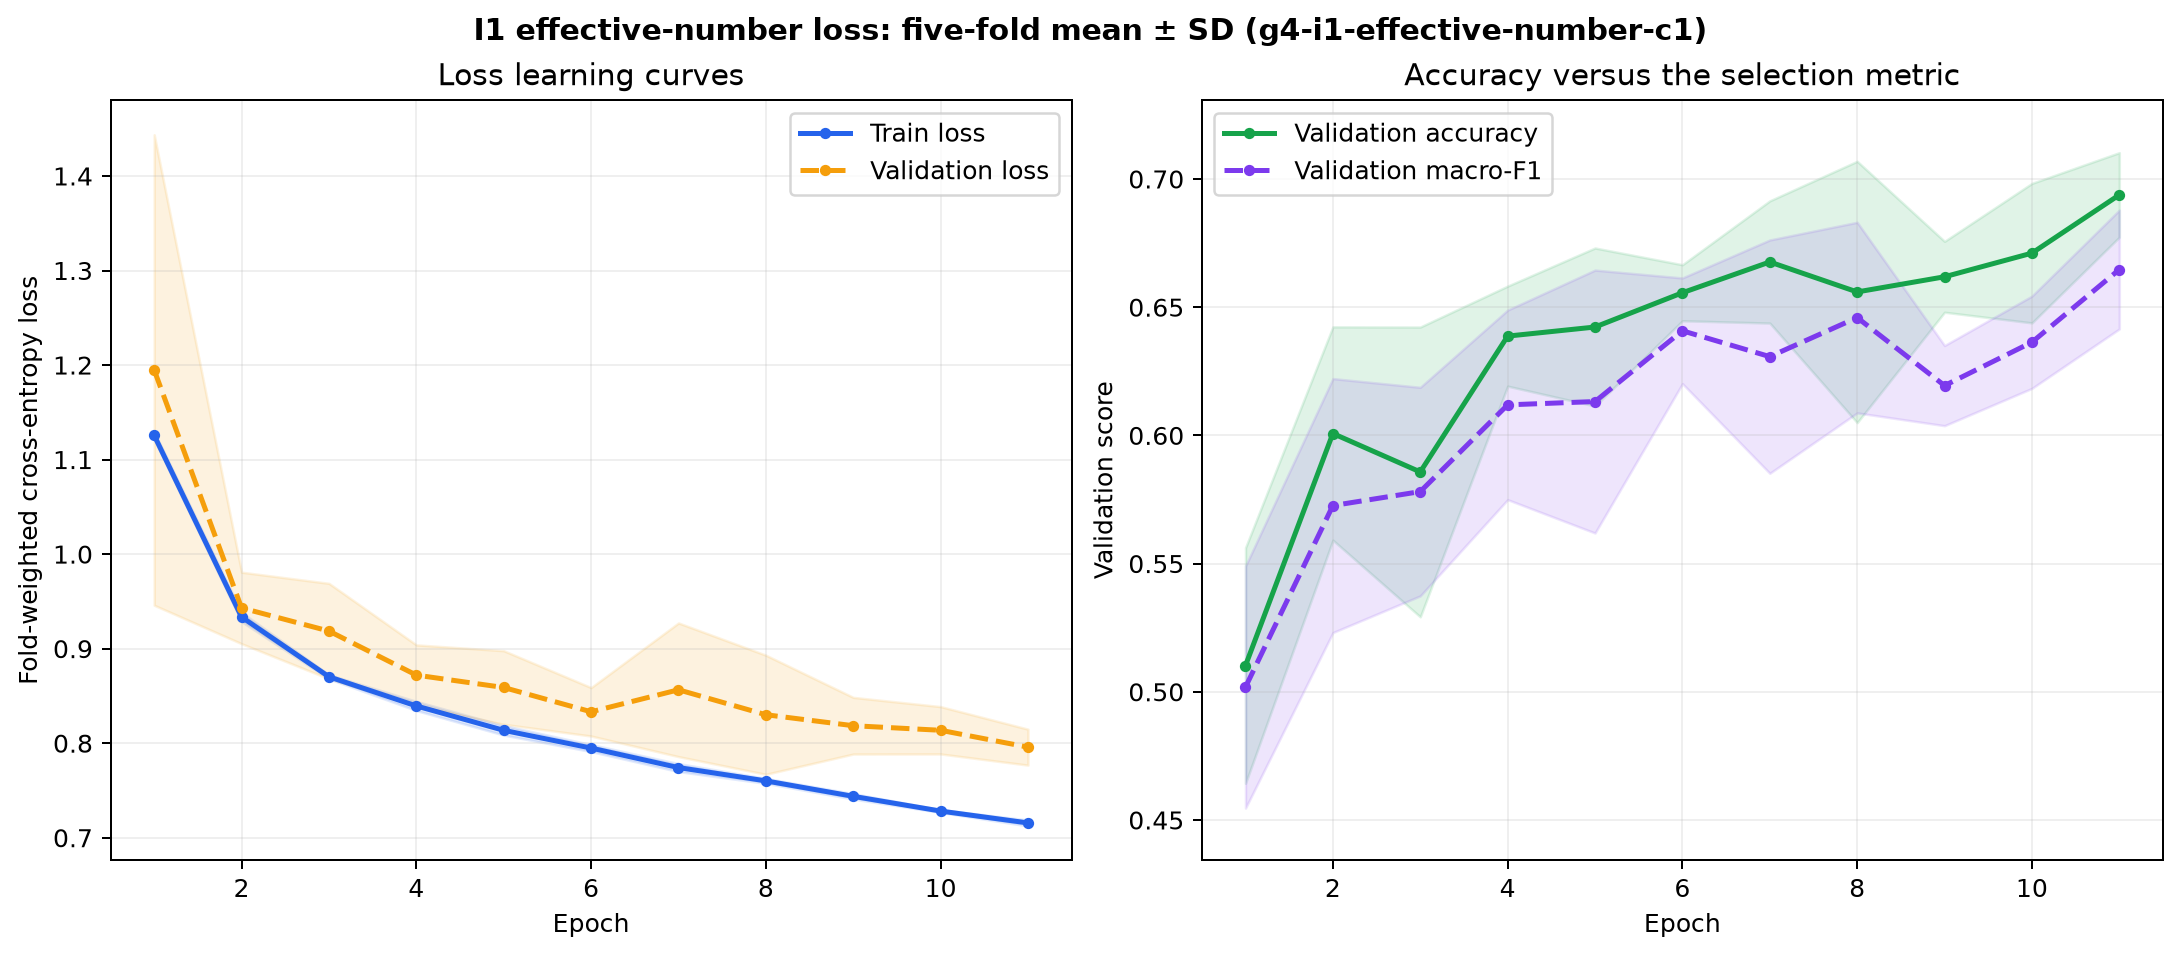

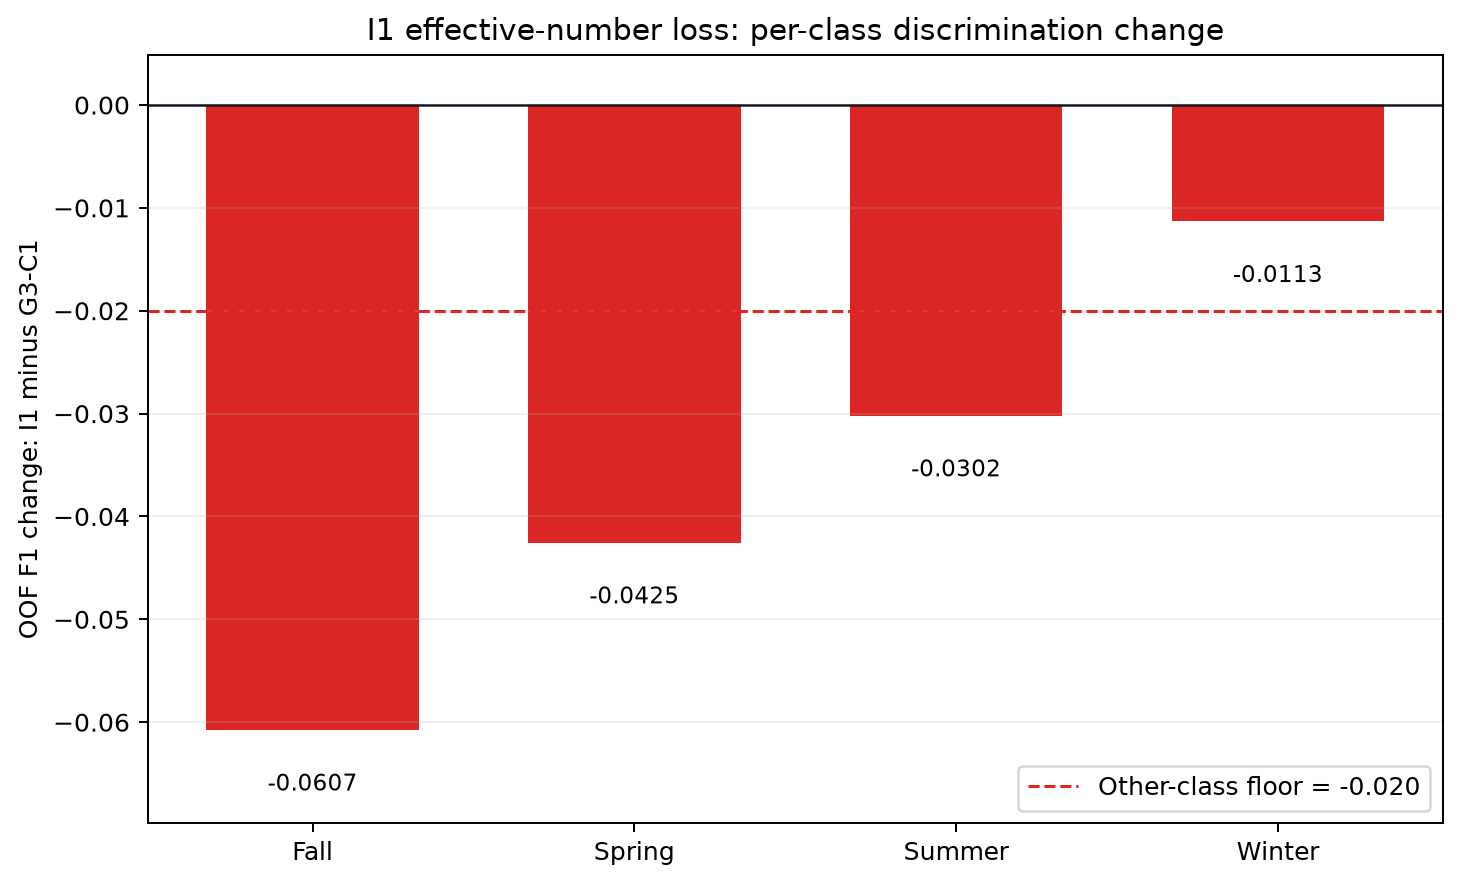

In [28]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.class_balance import run_or_load_i1_experiment
from fashion.task2.evidence import (
    build_experiment_evidence,
    build_i1_class_balance_evidence,
)
from fashion.train.registry import RunRegistry

i1_config_path = TASK2_CONFIG_DIR / "g4_i1_effective_number_c1.json"
i1_outputs = run_or_load_i1_experiment(
    i1_config_path,
    mode="run_or_load",
)
i1_probability_note = (
    "Uncalibrated softmax probabilities from the best validation macro-F1 "
    "checkpoint in each fold; calibration metrics are diagnostic only."
)
i1_experiment_manifest = build_experiment_evidence(
    i1_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=i1_probability_note,
    calibration_claim_allowed=False,
    evidence_directory=(
        TASK2_EVIDENCE_DIR / "g4_i1_effective_number_c1"
    ),
    figure_directory=TASK2_FIGURE_DIR,
)
i1_manifest = build_i1_class_balance_evidence(
    i1_manifest_path=(
        TASK2_EVIDENCE_DIR / "g4_i1_effective_number_c1/manifest.json"
    ),
    i1_config_path=i1_config_path,
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "i1_class_balance",
    figure_directory=TASK2_FIGURE_DIR,
)

current_run_ids = {output.run_id for output in i1_outputs}
assert len(current_run_ids) == 5
assert set(i1_experiment_manifest["run_ids"]) == current_run_ids
assert i1_experiment_manifest["coverage"]["row_count"] == len(
    season_development
)
assert i1_experiment_manifest["coverage"]["protected_id_count"] == 0

i1_registry = RunRegistry(RUNS_CSV)
i1_attempts = i1_registry.find(
    experiment_id="g4-i1-effective-number-c1"
)
i1_current_attempts = i1_attempts.loc[
    i1_attempts["run_id"].isin(current_run_ids)
].copy()
assert len(i1_current_attempts) == 5
assert i1_current_attempts["status"].eq("completed").all()
assert set(i1_current_attempts["fold"].astype(int)) == set(range(5))
assert not i1_attempts["status"].eq("running").any()

i1_comparison = pd.read_csv(
    ROOT / i1_manifest["artifacts"]["comparison"]["path"]
)
i1_paired_folds = pd.read_csv(
    ROOT / i1_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
i1_per_class = pd.read_csv(
    ROOT / i1_manifest["artifacts"]["per_class_comparison"]["path"]
)
i1_class_weights = pd.read_csv(
    ROOT / i1_manifest["artifacts"]["class_weights_by_fold"]["path"]
)
with (ROOT / i1_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    i1_decision = json.load(handle)

assert i1_manifest["gate"] == "G4-I1"
assert i1_manifest["keep_i1"] is False
assert i1_manifest["selected_experiment_id"] == "g3-c1-t1-smallcnn"
assert i1_decision["loss_values_comparable_to_reference"] is False
assert len(i1_paired_folds) == 5
assert len(i1_per_class) == len(SEASON_LABELS)
assert len(i1_class_weights) == 5 * len(SEASON_LABELS)

i1_weight_summary = (
    i1_class_weights.groupby("label", as_index=False, sort=False)
    .agg(
        training_count_min=("class_count", "min"),
        training_count_max=("class_count", "max"),
        class_weight_min=("class_weight", "min"),
        class_weight_max=("class_weight", "max"),
    )
)
display(
    i1_comparison.style.format(
        {
            "pooled_macro_f1": "{:.6f}",
            "fold_sd_macro_f1": "{:.6f}",
            "spring_f1": "{:.6f}",
            "delta_macro_f1_vs_reference": "{:+.6f}",
            "delta_spring_f1_vs_reference": "{:+.6f}",
        }
    )
)
display(i1_paired_folds)
display(
    i1_per_class.style.format(
        {
            "reference_precision": "{:.6f}",
            "reference_recall": "{:.6f}",
            "reference_f1": "{:.6f}",
            "i1_precision": "{:.6f}",
            "i1_recall": "{:.6f}",
            "i1_f1": "{:.6f}",
            "delta_i1_minus_reference_precision": "{:+.6f}",
            "delta_i1_minus_reference_recall": "{:+.6f}",
            "delta_i1_minus_reference_f1": "{:+.6f}",
        }
    )
)
display(
    i1_weight_summary.style.format(
        {
            "class_weight_min": "{:.6f}",
            "class_weight_max": "{:.6f}",
        }
    )
)
display(pd.json_normalize(i1_decision, sep=".").transpose())
display(
    i1_attempts.loc[:, [
        "fold",
        "run_id",
        "status",
        "error_type",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values(["fold", "status", "run_id"])
)
display(
    Image(
        filename=str(
            ROOT / i1_manifest["artifacts"]["learning_curves"]["path"]
        )
    )
)
display(
    Image(
        filename=str(
            ROOT / i1_manifest["artifacts"]["per_class_f1_delta"]["path"]
        )
    )
)

> **Interpretation:** **Incremental question:** B0 proved that class imbalance makes accuracy unsafe, B1 established usable shape-and-colour signal, and corrected G3 made C1-T1 the compact reference. I1 therefore changes only the loss: each training fold gives rare Spring about `2.511-2.513` weight and common Summer about `0.348` weight; the split, images, backbone, optimiser, seed, and data-preparation files stay fixed. **Result:** I1 reached `0.701471` pooled OOF macro-F1 versus G3-C1 `0.737661` (`-0.036191`). Spring F1 fell from `0.744975` to `0.702439` (`-0.042536`), and Fall was the worst other class at `-0.060738`. All three frozen criteria failed. **Why:** Spring recall did rise by `+0.022573`, but Spring precision fell by `-0.152558`; the model predicted Spring more often but created too many false positives, so minority F1 became worse. Fold SD also rose from `0.010013` to `0.034919`, with fold 4 only `0.644306`, so the intervention was less stable. **Learning curves:** fold-weighted training and validation loss generally decline, while validation accuracy and macro-F1 rise with wide fold bands. The five-fold mean stops at the common 11-epoch horizon so every point contains all folds. I1 and G3 loss values are not comparable because their loss functions use different scales. **EDA reflection:** the earlier imbalance finding was accurate, but the narrower hypothesis that this effective-number weighting would solve it was contradicted. Imbalance justifies macro-F1 and class-level analysis; it does not guarantee that reweighting helps. **Decision:** reject I1 and retain `g3-c1-t1-smallcnn`; test the separate I2 auxiliary-supervision question next. **Limitation:** this is one seed and one frozen `beta=0.9999` rule, so it does not prove that every class-balancing method fails; calibration is still untested. **Trace:** the five selected runs span `g4-i1-effective-number-c1-f0-s2753-9288633e212b` to `g4-i1-effective-number-c1-f4-s2753-a70502c769db`. The externally stopped fold-1 attempt remains `interrupted` in the local ledger but is excluded from evidence. `results/evidence/task2/i1_class_balance/manifest.json` hashes the OOF comparison, fold pairs, class weights, run IDs, histories, decision, learning curves, and per-class chart.

#### 8.3.2 I2 image-only multi-task training

I2 tests whether auxiliary ArticleType supervision improves shared visual features or causes negative transfer.

,variant,experiment_id,auxiliary_weight,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,spring_f1,aligned_macro_f1,conflict_macro_f1,aligned_support,conflict_support,unseen_article_type_support,five_fold_runtime_minutes,peak_vram_mb,parameter_count,median_best_epoch,delta_macro_f1_vs_reference,delta_spring_f1_vs_reference,delta_aligned_macro_f1_vs_reference,delta_conflict_macro_f1_vs_reference,config_sha256,split_sha256,label_map_sha256,implementation_sha256,transform_id,passes_overall_gain,passes_conflict_gain,passes_i2_gate,selected_by_i2_gate
0,G3-C1 reference,g3-c1-t1-smallcnn,0.000000,0.737661,0.737599,0.010013,0.744975,0.855221,0.402613,21115,11619,19,60.209847,191.358887,1174244,21.000000,+0.000000,+0.000000,+0.000000,+0.000000,1c54b8a3539f153f95ddae6aa0d871459673dd01490b2c31e8d7a7fed237f043,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1000b87a9806a2d09fe,a0-7dba8a62f166046d,False,False,False,False
1,I2 lambda=0.1,g4-i2-article-type-lambda-0-1-c1,0.100000,0.750758,0.750751,0.004995,0.762031,0.865686,0.434530,21115,11619,19,40.400259,190.102539,1206112,24.000000,+0.013097,+0.017055,+0.010465,+0.031917,45489223166e856554d728ea9676385167018391d7697d3aa4de817c0aacfcba,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,877706919db28f917632f9250b1b40d446695f941fd226211246d69efd7838de,a0-7dba8a62f166046d,True,True,True,False
2,I2 lambda=0.3,g4-i2-article-type-lambda-0-3-c1,0.300000,0.752687,0.752557,0.006752,0.764784,0.869013,0.430211,21115,11619,19,28.556091,190.102539,1206112,24.000000,+0.015026,+0.019809,+0.013792,+0.027598,28a122892bd80bf44b1dfa79abb6228e4160e430d25ec632386e3be68619eb4c,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,877706919db28f917632f9250b1b40d446695f941fd226211246d69efd7838de,a0-7dba8a62f166046d,True,True,True,True


,fold,reference_run_id,reference_macro_f1,reference_accuracy,lambda_0.1_run_id,lambda_0.1_macro_f1,lambda_0.1_accuracy,lambda_0.3_run_id,lambda_0.3_macro_f1,lambda_0.3_accuracy
0,0,g3-c1-t1-smallcnn-f0-s2753-1ce4f9978b12,0.738254,0.747939,g4-i2-article-type-lambda-0-1-c1-f0-s2753-1ffe...,0.749470,0.758931,g4-i2-article-type-lambda-0-3-c1-f0-s2753-902f...,0.748937,0.758473
1,1,g3-c1-t1-smallcnn-f1-s2753-ea0b61364ef4,0.740002,0.753320,g4-i2-article-type-lambda-0-1-c1-f1-s2753-c682...,0.744538,0.757289,g4-i2-article-type-lambda-0-3-c1-f1-s2753-1e4b...,0.757574,0.766448
2,2,g3-c1-t1-smallcnn-f2-s2753-8439c63a5bac,0.735770,0.750076,g4-i2-article-type-lambda-0-1-c1-f2-s2753-aac1...,0.749619,0.760916,g4-i2-article-type-lambda-0-3-c1-f2-s2753-e4b6...,0.743012,0.761527
3,3,g3-c1-t1-smallcnn-f3-s2753-16f0d6eb1cbc,0.750962,0.762595,g4-i2-article-type-lambda-0-1-c1-f3-s2753-20ed...,0.758308,0.766870,g4-i2-article-type-lambda-0-3-c1-f3-s2753-bc2e...,0.759774,0.768092
4,4,g3-c1-t1-smallcnn-f4-s2753-2b4a6d779fa3,0.723007,0.728938,g4-i2-article-type-lambda-0-1-c1-f4-s2753-6291...,0.751820,0.760073,g4-i2-article-type-lambda-0-3-c1-f4-s2753-8d21...,0.753486,0.757937


,variant,experiment_id,auxiliary_weight,label,precision,recall,f1,support,delta_f1_vs_reference
0,G3-C1 reference,g3-c1-t1-smallcnn,0.000000,Fall,0.720529,0.664763,0.691523,8928,+0.000000
1,G3-C1 reference,g3-c1-t1-smallcnn,0.000000,Spring,0.916484,0.627540,0.744975,1329,+0.000000
2,G3-C1 reference,g3-c1-t1-smallcnn,0.000000,Summer,0.748028,0.823591,0.783993,16235,+0.000000
3,G3-C1 reference,g3-c1-t1-smallcnn,0.000000,Winter,0.763916,0.699249,0.730153,6261,+0.000000
4,I2 lambda=0.1,g4-i2-article-type-lambda-0-1-c1,0.100000,Fall,0.744049,0.665211,0.702425,8928,+0.010901
5,I2 lambda=0.1,g4-i2-article-type-lambda-0-1-c1,0.100000,Spring,0.922009,0.649360,0.762031,1329,+0.017055
6,I2 lambda=0.1,g4-i2-article-type-lambda-0-1-c1,0.100000,Summer,0.755521,0.840776,0.795872,16235,+0.011879
7,I2 lambda=0.1,g4-i2-article-type-lambda-0-1-c1,0.100000,Winter,0.774445,0.713464,0.742705,6261,+0.012552
8,I2 lambda=0.3,g4-i2-article-type-lambda-0-3-c1,0.300000,Fall,0.744489,0.665771,0.702933,8928,+0.011409
9,I2 lambda=0.3,g4-i2-article-type-lambda-0-3-c1,0.300000,Spring,0.934783,0.647103,0.764784,1329,+0.019809


,variant,experiment_id,auxiliary_weight,shortcut_slice,support,macro_f1,accuracy
0,G3-C1 reference,g3-c1-t1-smallcnn,0.000000,aligned,21115,0.855221,0.868435
1,G3-C1 reference,g3-c1-t1-smallcnn,0.000000,conflict,11619,0.402613,0.531371
4,I2 lambda=0.1,g4-i2-article-type-lambda-0-1-c1,0.100000,aligned,21115,0.865686,0.878901
5,I2 lambda=0.1,g4-i2-article-type-lambda-0-1-c1,0.100000,conflict,11619,0.434530,0.546949
8,I2 lambda=0.3,g4-i2-article-type-lambda-0-3-c1,0.300000,aligned,21115,0.869013,0.883116
9,I2 lambda=0.3,g4-i2-article-type-lambda-0-3-c1,0.300000,conflict,11619,0.430211,0.543937


,0
decision_status,closed
gate,G4-I2
keep_i2,True
limitations,"[This gate uses the primary seed only., Articl..."
loss_values_comparable_to_reference,False
maximum_overall_loss,0.002
minimum_conflict_gain,0.01
minimum_overall_gain,0.003
next_question,Run the matched pretrained benchmark boundary ...
primary_metric,pooled_five_fold_oof_macro_f1


,experiment_id,fold,run_id,status,git_commit,git_dirty,primary_metric_value
0,g4-i2-article-type-lambda-0-1-c1,0,g4-i2-article-type-lambda-0-1-c1-f0-s2753-1ffe...,completed,7a6bb493f0d91f56aa075bb3d1f1c6e8a6e6f884,false,0.7494697306859952
1,g4-i2-article-type-lambda-0-1-c1,1,g4-i2-article-type-lambda-0-1-c1-f1-s2753-c682...,completed,7a6bb493f0d91f56aa075bb3d1f1c6e8a6e6f884,false,0.7445375849968889
2,g4-i2-article-type-lambda-0-1-c1,2,g4-i2-article-type-lambda-0-1-c1-f2-s2753-aac1...,completed,7a6bb493f0d91f56aa075bb3d1f1c6e8a6e6f884,false,0.7496190802927047
3,g4-i2-article-type-lambda-0-1-c1,3,g4-i2-article-type-lambda-0-1-c1-f3-s2753-20ed...,completed,7a6bb493f0d91f56aa075bb3d1f1c6e8a6e6f884,false,0.7583079902645908
4,g4-i2-article-type-lambda-0-1-c1,4,g4-i2-article-type-lambda-0-1-c1-f4-s2753-6291...,completed,7a6bb493f0d91f56aa075bb3d1f1c6e8a6e6f884,false,0.7518199961935825
5,g4-i2-article-type-lambda-0-3-c1,0,g4-i2-article-type-lambda-0-3-c1-f0-s2753-902f...,completed,7a6bb493f0d91f56aa075bb3d1f1c6e8a6e6f884,false,0.7489367875819454
6,g4-i2-article-type-lambda-0-3-c1,1,g4-i2-article-type-lambda-0-3-c1-f1-s2753-1e4b...,completed,7a6bb493f0d91f56aa075bb3d1f1c6e8a6e6f884,false,0.7575743989618585
7,g4-i2-article-type-lambda-0-3-c1,2,g4-i2-article-type-lambda-0-3-c1-f2-s2753-e4b6...,completed,7a6bb493f0d91f56aa075bb3d1f1c6e8a6e6f884,false,0.743012242110391
8,g4-i2-article-type-lambda-0-3-c1,3,g4-i2-article-type-lambda-0-3-c1-f3-s2753-bc2e...,completed,7a6bb493f0d91f56aa075bb3d1f1c6e8a6e6f884,false,0.7597741630370382
9,g4-i2-article-type-lambda-0-3-c1,4,g4-i2-article-type-lambda-0-3-c1-f4-s2753-8d21...,completed,7a6bb493f0d91f56aa075bb3d1f1c6e8a6e6f884,false,0.7534862811083198


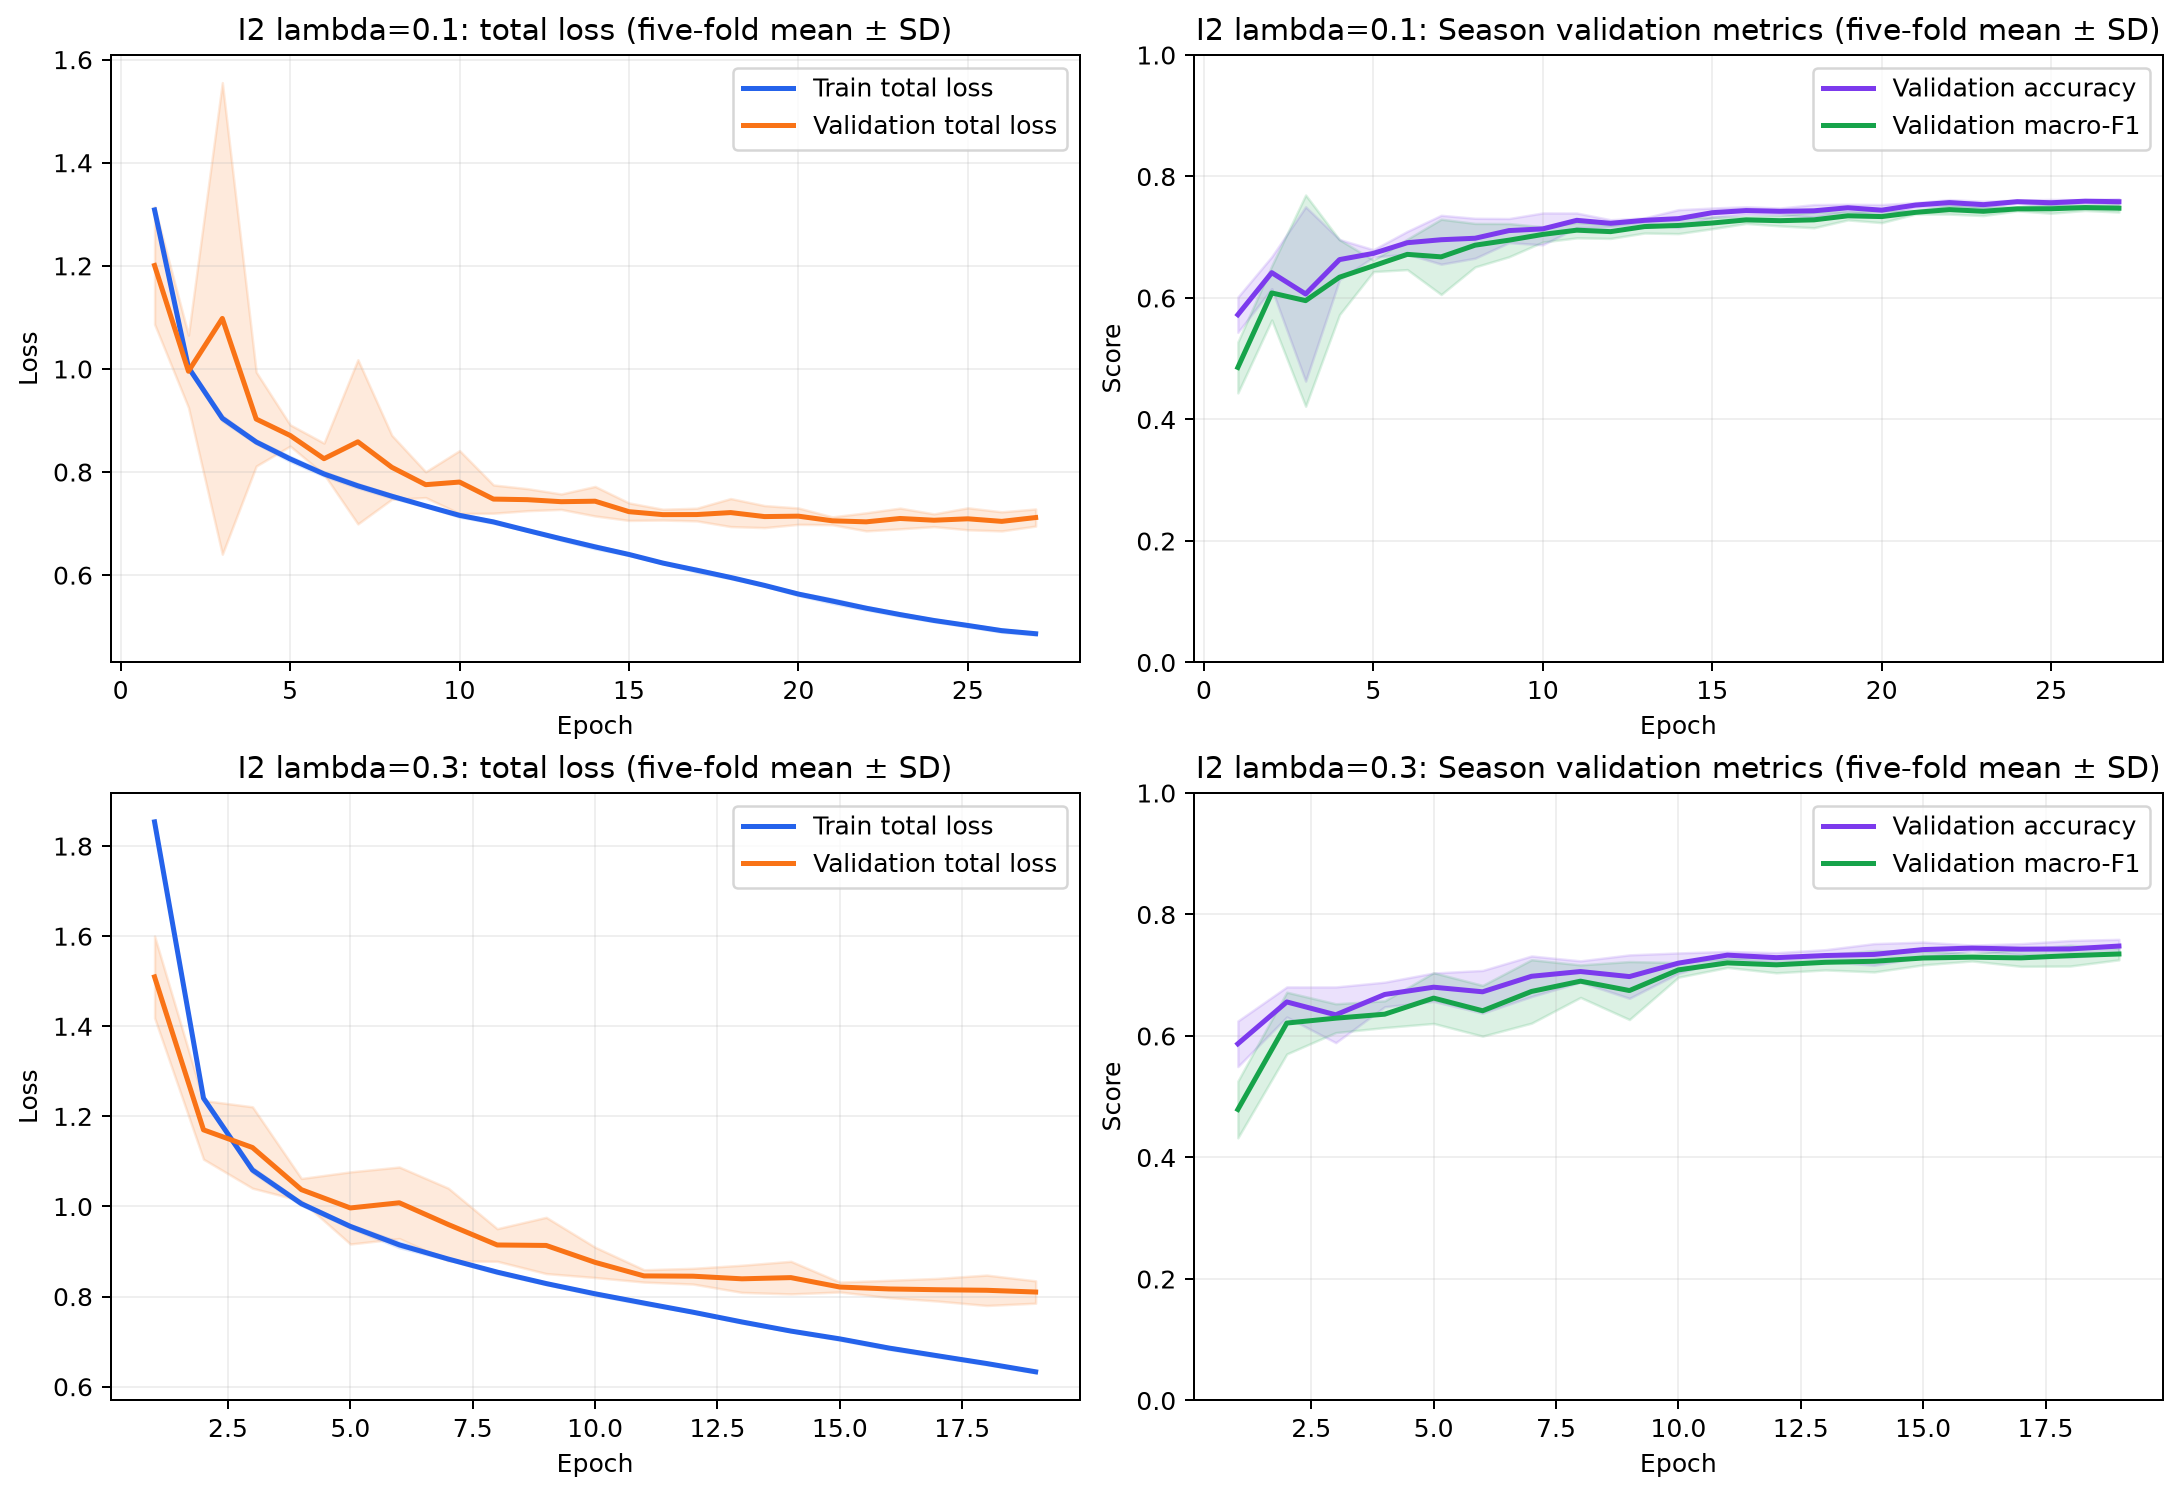

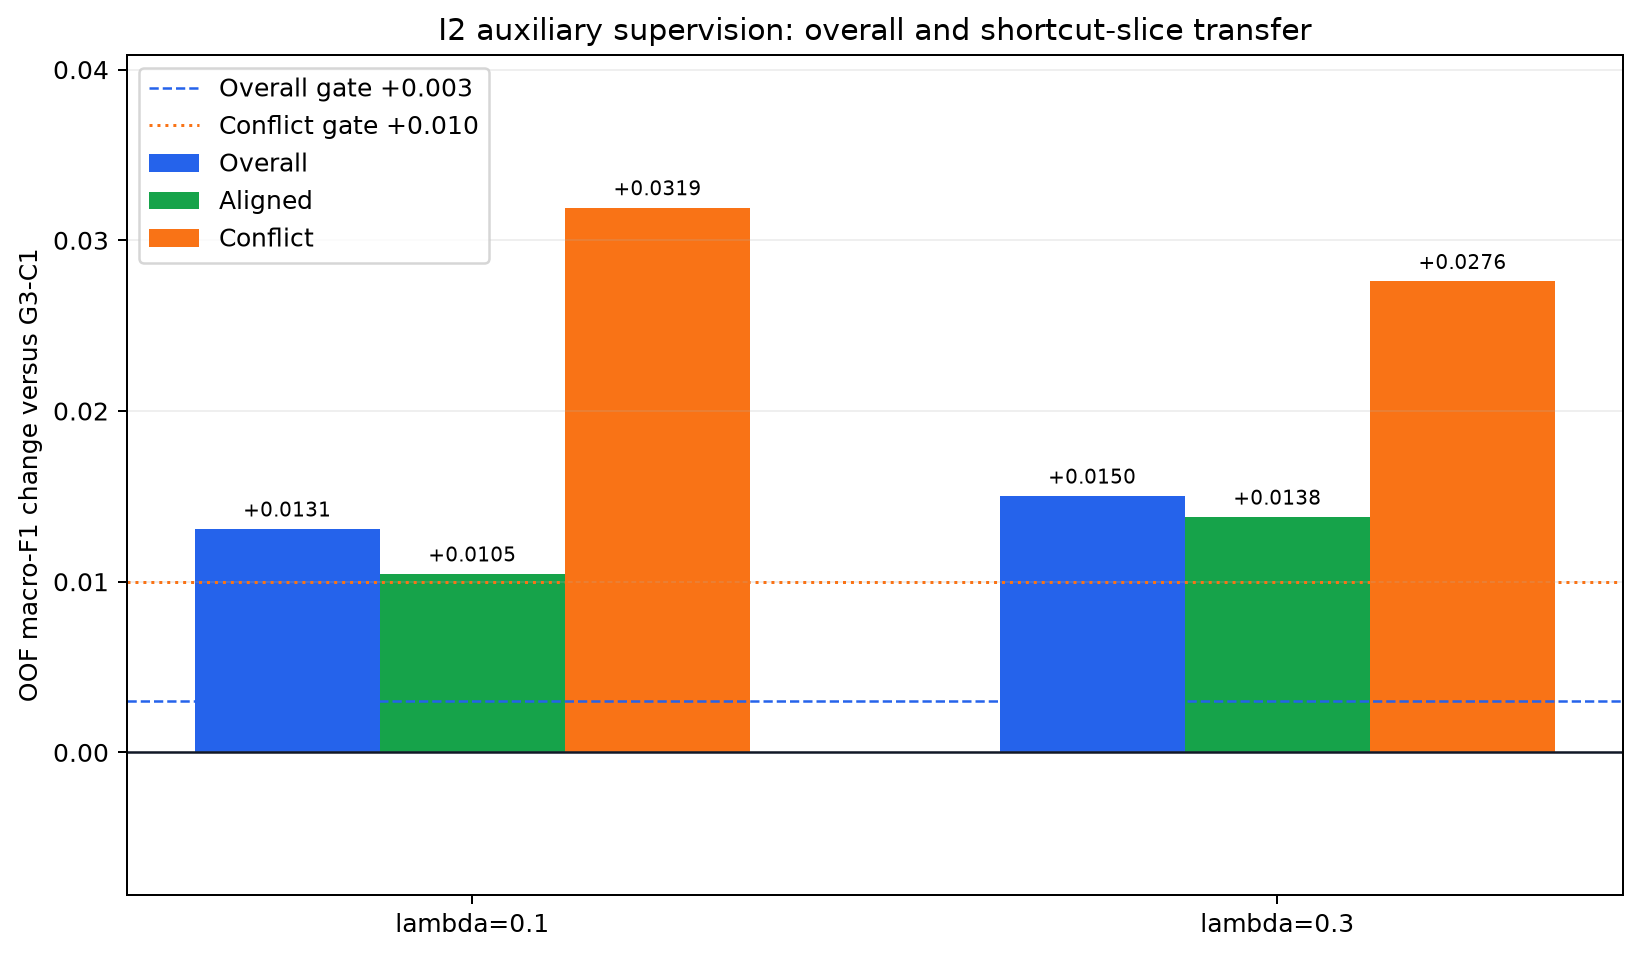

In [29]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.evidence import build_experiment_evidence
from fashion.task2.multitask import load_i2_config, run_i2_matrix
from fashion.task2.multitask_evidence import build_i2_transfer_evidence
from fashion.train.registry import RunRegistry

i2_config_paths = (
    TASK2_CONFIG_DIR / "g4_i2_article_type_lambda_0_1_c1.json",
    TASK2_CONFIG_DIR / "g4_i2_article_type_lambda_0_3_c1.json",
)
i2_configs = [load_i2_config(path) for path in i2_config_paths]
i2_outputs = run_i2_matrix(i2_configs, mode="run_or_load")
i2_probability_note = (
    "Uncalibrated softmax probabilities from the best validation Season "
    "macro-F1 checkpoint; ArticleType is training-only."
)
i2_experiment_manifests = {}
for config in i2_configs:
    config_outputs = [
        output
        for output in i2_outputs
        if output.experiment_id == config.experiment_id
    ]
    evidence_slug = config.experiment_id.replace("-", "_")
    i2_experiment_manifests[config.experiment_id] = (
        build_experiment_evidence(
            config_outputs,
            registry_path=RUNS_CSV,
            expected_ids=season_development["id"],
            protected_ids=protected_ids,
            probability_note=i2_probability_note,
            calibration_claim_allowed=False,
            evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
            figure_directory=TASK2_FIGURE_DIR,
        )
    )

i2_manifest_paths = tuple(
    TASK2_EVIDENCE_DIR
    / config.experiment_id.replace("-", "_")
    / "manifest.json"
    for config in i2_configs
)
i2_manifest = build_i2_transfer_evidence(
    i2_manifest_paths=i2_manifest_paths,
    i2_config_paths=i2_config_paths,
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "i2_multitask",
    figure_directory=TASK2_FIGURE_DIR,
)

current_run_ids = {output.run_id for output in i2_outputs}
assert len(current_run_ids) == 10
assert all(
    manifest["coverage"]["row_count"] == len(season_development)
    for manifest in i2_experiment_manifests.values()
)
assert all(
    manifest["coverage"]["protected_id_count"] == 0
    for manifest in i2_experiment_manifests.values()
)

i2_registry = RunRegistry(RUNS_CSV)
i2_attempts = pd.concat(
    [
        i2_registry.find(experiment_id=config.experiment_id)
        for config in i2_configs
    ],
    ignore_index=True,
)
i2_current_attempts = i2_attempts.loc[
    i2_attempts["run_id"].isin(current_run_ids)
].copy()
assert len(i2_current_attempts) == 10
assert i2_current_attempts["status"].eq("completed").all()
assert not i2_attempts["status"].eq("running").any()
assert set(i2_current_attempts["fold"].astype(int)) == set(range(5))
assert set(i2_current_attempts["seed"].astype(int)) == {2753}
assert (
    i2_current_attempts["git_dirty"].astype(str).str.lower().eq("false").all()
)

i2_comparison = pd.read_csv(
    ROOT / i2_manifest["artifacts"]["comparison"]["path"]
)
i2_paired_folds = pd.read_csv(
    ROOT / i2_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
i2_per_class = pd.read_csv(
    ROOT / i2_manifest["artifacts"]["per_class_comparison"]["path"]
)
i2_slices = pd.read_csv(
    ROOT / i2_manifest["artifacts"]["slice_metrics"]["path"]
)
with (ROOT / i2_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    i2_decision = json.load(handle)

assert i2_manifest["gate"] == "G4-I2"
assert i2_manifest["keep_i2"] is True
assert (
    i2_manifest["selected_experiment_id"]
    == "g4-i2-article-type-lambda-0-3-c1"
)
assert i2_decision["loss_values_comparable_to_reference"] is False
assert len(i2_paired_folds) == 5
assert set(i2_per_class["label"]) == set(SEASON_LABELS)
assert {"aligned", "conflict"} <= set(i2_slices["shortcut_slice"])

display(
    i2_comparison.style.format(
        {
            "pooled_macro_f1": "{:.6f}",
            "fold_sd_macro_f1": "{:.6f}",
            "spring_f1": "{:.6f}",
            "delta_macro_f1_vs_reference": "{:+.6f}",
            "delta_spring_f1_vs_reference": "{:+.6f}",
            "delta_aligned_macro_f1_vs_reference": "{:+.6f}",
            "delta_conflict_macro_f1_vs_reference": "{:+.6f}",
        }
    )
)
display(i2_paired_folds)
display(i2_per_class.style.format({"f1": "{:.6f}", "delta_f1_vs_reference": "{:+.6f}"}))
display(
    i2_slices.loc[
        i2_slices["shortcut_slice"].isin(["aligned", "conflict"])
    ].style.format({"accuracy": "{:.6f}", "macro_f1": "{:.6f}"})
)
display(pd.json_normalize(i2_decision, sep=".").transpose())
display(
    i2_current_attempts.loc[:, [
        "experiment_id",
        "fold",
        "run_id",
        "status",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values(["experiment_id", "fold"])
)
display(
    Image(
        filename=str(
            ROOT / i2_manifest["artifacts"]["learning_curves"]["path"]
        )
    )
)
display(
    Image(
        filename=str(
            ROOT / i2_manifest["artifacts"]["transfer_deltas"]["path"]
        )
    )
)

> **Interpretation:** **Incremental question:** B0 showed why accuracy alone is unsafe, B1 proved that simple shape-and-colour features carry some Season signal, C1/G3 supplied the strongest compact scratch reference, and I1 showed that changing only class weights made the result worse. I2 therefore keeps the G3 data, split, SmallCNN, optimiser, transform, and seed fixed, then adds one training-only ArticleType head; inference still receives only the image, and Notebook 01/data preparation is unchanged. **Result:** lambda `0.1` reached `0.750758` pooled five-fold OOF macro-F1 (`+0.013097` versus G3-C1), while lambda `0.3` reached `0.752687` (`+0.015026`) versus `0.737661`. For lambda `0.3`, Spring F1 rose from `0.744975` to `0.764784` (`+0.019809`), aligned-slice macro-F1 rose by `+0.013792`, and conflict-slice macro-F1 rose by `+0.027598`. Lambda `0.1` produced the larger conflict gain (`+0.031917`) but the lower overall score. Both candidates pass the frozen I2 gate; its stated priority selects lambda `0.3` because it has the highest overall pooled macro-F1. **Learning curves:** the teacher-style chart places train/validation total loss on the left and validation accuracy/macro-F1 on the right, using five-fold mean plus/minus one SD. Validation scores rise then flatten while training loss keeps falling, so the best validation macro-F1 checkpoint remains necessary. The common five-fold horizons are 27 epochs for lambda `0.1` and 19 for lambda `0.3`; total-loss values must be interpreted within a lambda because changing the auxiliary weight changes the loss scale. **EDA reflection:** the earlier EDA insight that ArticleType and Season are related was useful: auxiliary labels improved Spring and overall performance. The fear that I2 would only copy the ArticleType shortcut was too simple, because conflict rows also improved. However, this is still association, not proof that ArticleType causes Season; aligned/conflict is only one declared slice. **Decision:** keep I2 lambda `0.3` as the current candidate, but do not freeze the ultimate winner yet. Run the matched pretrained benchmark boundary and second-seed stability test next. **Limitations:** this conclusion uses one seed, only 19 unseen-ArticleType rows, no missing-ArticleType rows, and uncalibrated probabilities; robustness and uncertainty are still pending. **Trace:** the selected runs span `g4-i2-article-type-lambda-0-3-c1-f0-s2753-902fcc852d5f` to `g4-i2-article-type-lambda-0-3-c1-f4-s2753-8d210d54f01e`. `results/evidence/task2/i2_multitask/manifest.json` links all ten I2 run IDs, both configs, pooled OOF tables, shortcut slices, decision, learning curves, and transfer chart by SHA-256.

#### 8.3.3 P* pretrained benchmark execution

P* estimates the value of transferred representation while remaining ineligible for submission.

,variant,experiment_id,model_family,training_origin,weights,scratch,benchmark_only,final_eligible,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,spring_f1,five_fold_runtime_minutes,peak_vram_mb,parameter_count,median_best_epoch,config_sha256,implementation_sha256
0,P0S standard-stem scratch control,g4-p0s-resnet18-standard-scratch,resnet18_standard_scratch,scratch,none,True,True,False,0.731172,0.731063,0.006199,0.729537,32.47,279.0,11178564,22.000000,24927c703c0249060fcf62b768382662e0c935194c4e1aebcbdc56a80604f35c,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1000b87a9806a2d09fe
1,P* standard-stem ImageNet benchmark,g4-pstar-resnet18-standard-pretrained,resnet18_standard_pretrained,imagenet_pretrained,ResNet18_Weights.DEFAULT,False,True,False,0.754196,0.754113,0.008002,0.768366,22.69,279.0,11178564,11.000000,d020238845df149b0864e64fc14a128432287e09418c1c071cde149a4e29cf15,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1000b87a9806a2d09fe


,fold,p0s_run_id,p0s_macro_f1,p0s_accuracy,pstar_run_id,pstar_macro_f1,pstar_accuracy,pstar_minus_p0s_macro_f1,pstar_minus_p0s_accuracy
0,0,g4-p0s-resnet18-standard-scratch-f0-s2753-7db3...,0.726768,0.738626,g4-pstar-resnet18-standard-pretrained-f0-s2753...,0.766383,0.767481,0.039615,0.028855
1,1,g4-p0s-resnet18-standard-scratch-f1-s2753-7a22...,0.725752,0.739734,g4-pstar-resnet18-standard-pretrained-f1-s2753...,0.750023,0.761105,0.024271,0.021371
2,2,g4-p0s-resnet18-standard-scratch-f2-s2753-cfcc...,0.733040,0.749313,g4-pstar-resnet18-standard-pretrained-f2-s2753...,0.744729,0.760153,0.011689,0.010840
3,3,g4-p0s-resnet18-standard-scratch-f3-s2753-6ba1...,0.740963,0.750534,g4-pstar-resnet18-standard-pretrained-f3-s2753...,0.754568,0.761221,0.013605,0.010687
4,4,g4-p0s-resnet18-standard-scratch-f4-s2753-3a66...,0.728794,0.735958,g4-pstar-resnet18-standard-pretrained-f4-s2753...,0.754863,0.760684,0.026068,0.024725


,label,precision_p0s,precision_pstar,recall_p0s,recall_pstar,f1_p0s,f1_pstar,support_p0s,support_pstar,pstar_minus_p0s_f1
0,Fall,0.706325,0.739002,0.661626,0.671707,0.683246,0.703749,8928.000000,8928.000000,+0.020504
1,Spring,0.892274,0.902538,0.617005,0.668924,0.729537,0.768366,1329.000000,1329.000000,+0.038829
2,Summer,0.751841,0.766712,0.804866,0.827964,0.777451,0.796162,16235.000000,16235.000000,+0.018711
3,Winter,0.744705,0.757066,0.724485,0.740137,0.734456,0.748506,6261.000000,6261.000000,+0.014050


,0
benchmark_experiment_id,g4-pstar-resnet18-standard-pretrained
candidate_selection_affected,False
control_experiment_id,g4-p0s-resnet18-standard-scratch
decision_status,closed
gate,G4-PSTAR
interpretation_rule,P* minus P0S estimates only the initialisation...
limitations,"[This gate uses the primary seed only., The fi..."
next_question,Run the frozen scratch finalist with seed 2026...
observed_pstar_minus_p0s_macro_f1,0.023024
observed_pstar_minus_p0s_spring_f1,0.038829


,experiment_id,fold,run_id,status,git_commit,git_dirty,primary_metric_value
0,g4-p0s-resnet18-standard-scratch,0,g4-p0s-resnet18-standard-scratch-f0-s2753-7db3...,completed,e74d0fdbce1ab9f6c6cce7ad7376f0d256ca6468,false,0.7267681301901548
1,g4-p0s-resnet18-standard-scratch,1,g4-p0s-resnet18-standard-scratch-f1-s2753-7a22...,completed,e74d0fdbce1ab9f6c6cce7ad7376f0d256ca6468,false,0.725752398304514
2,g4-p0s-resnet18-standard-scratch,2,g4-p0s-resnet18-standard-scratch-f2-s2753-cfcc...,completed,e74d0fdbce1ab9f6c6cce7ad7376f0d256ca6468,false,0.7330398640472745
3,g4-p0s-resnet18-standard-scratch,3,g4-p0s-resnet18-standard-scratch-f3-s2753-6ba1...,completed,e74d0fdbce1ab9f6c6cce7ad7376f0d256ca6468,false,0.7409625643353914
4,g4-p0s-resnet18-standard-scratch,4,g4-p0s-resnet18-standard-scratch-f4-s2753-3a66...,completed,e74d0fdbce1ab9f6c6cce7ad7376f0d256ca6468,false,0.7287943142927247
5,g4-pstar-resnet18-standard-pretrained,0,g4-pstar-resnet18-standard-pretrained-f0-s2753...,completed,e74d0fdbce1ab9f6c6cce7ad7376f0d256ca6468,false,0.766382701392384
6,g4-pstar-resnet18-standard-pretrained,1,g4-pstar-resnet18-standard-pretrained-f1-s2753...,completed,e74d0fdbce1ab9f6c6cce7ad7376f0d256ca6468,false,0.7500230133581898
7,g4-pstar-resnet18-standard-pretrained,2,g4-pstar-resnet18-standard-pretrained-f2-s2753...,completed,e74d0fdbce1ab9f6c6cce7ad7376f0d256ca6468,false,0.7447289767065994
8,g4-pstar-resnet18-standard-pretrained,3,g4-pstar-resnet18-standard-pretrained-f3-s2753...,completed,e74d0fdbce1ab9f6c6cce7ad7376f0d256ca6468,false,0.7545676208709297
9,g4-pstar-resnet18-standard-pretrained,4,g4-pstar-resnet18-standard-pretrained-f4-s2753...,completed,e74d0fdbce1ab9f6c6cce7ad7376f0d256ca6468,false,0.7548627996860352


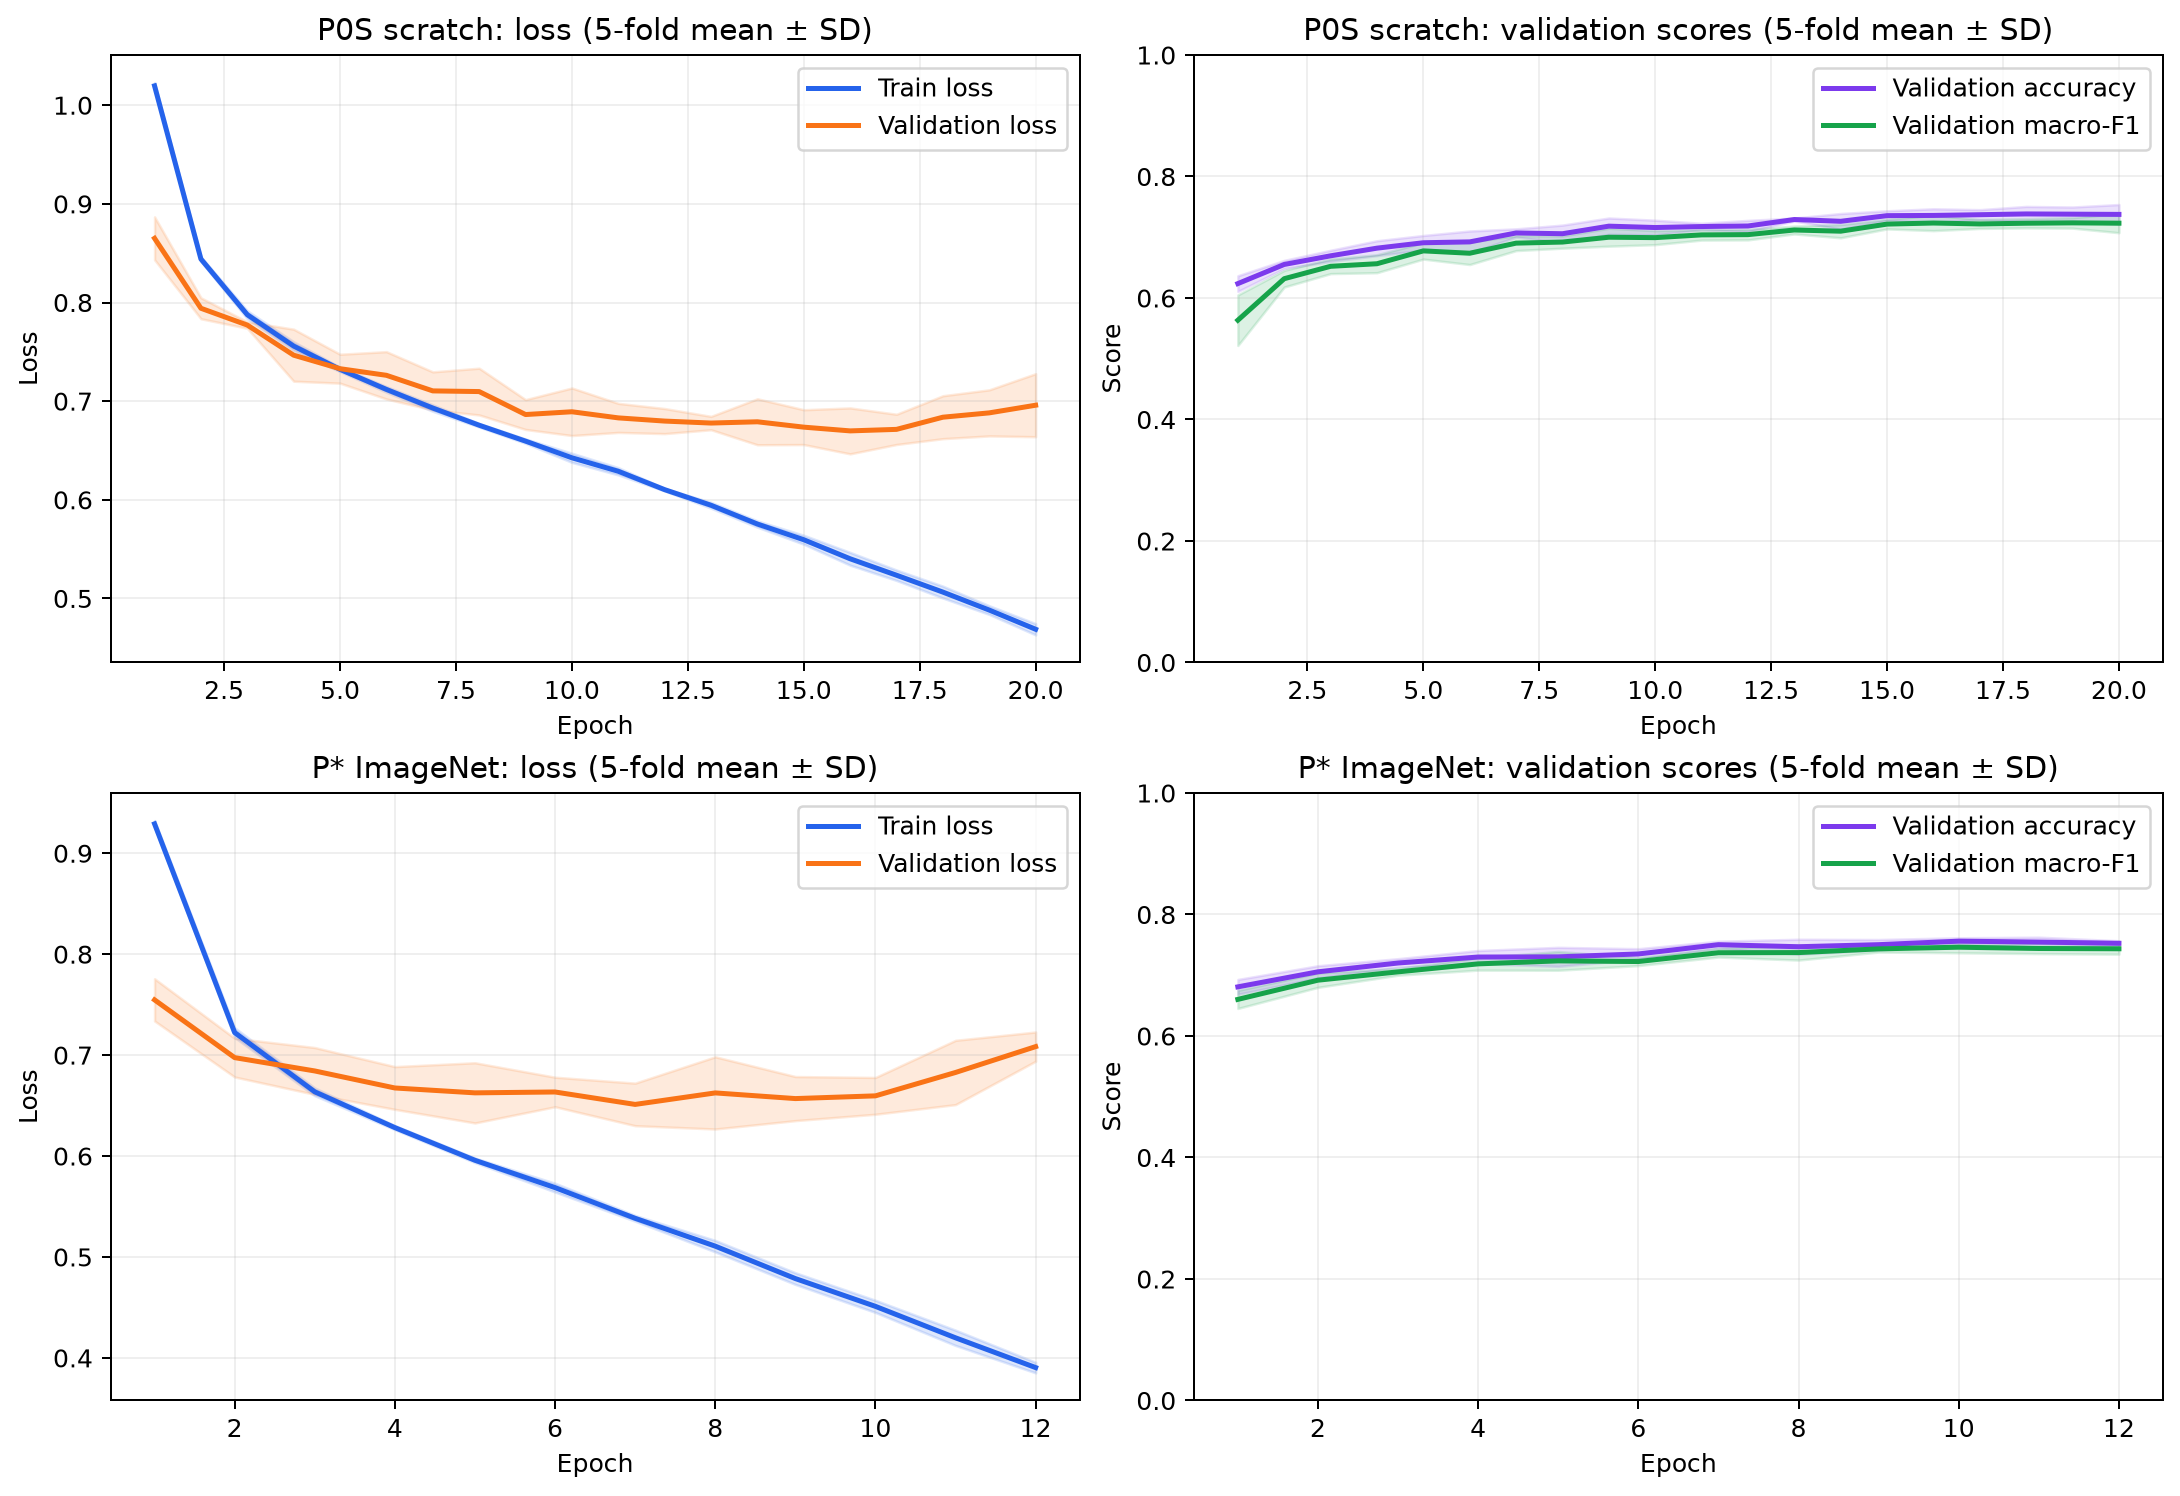

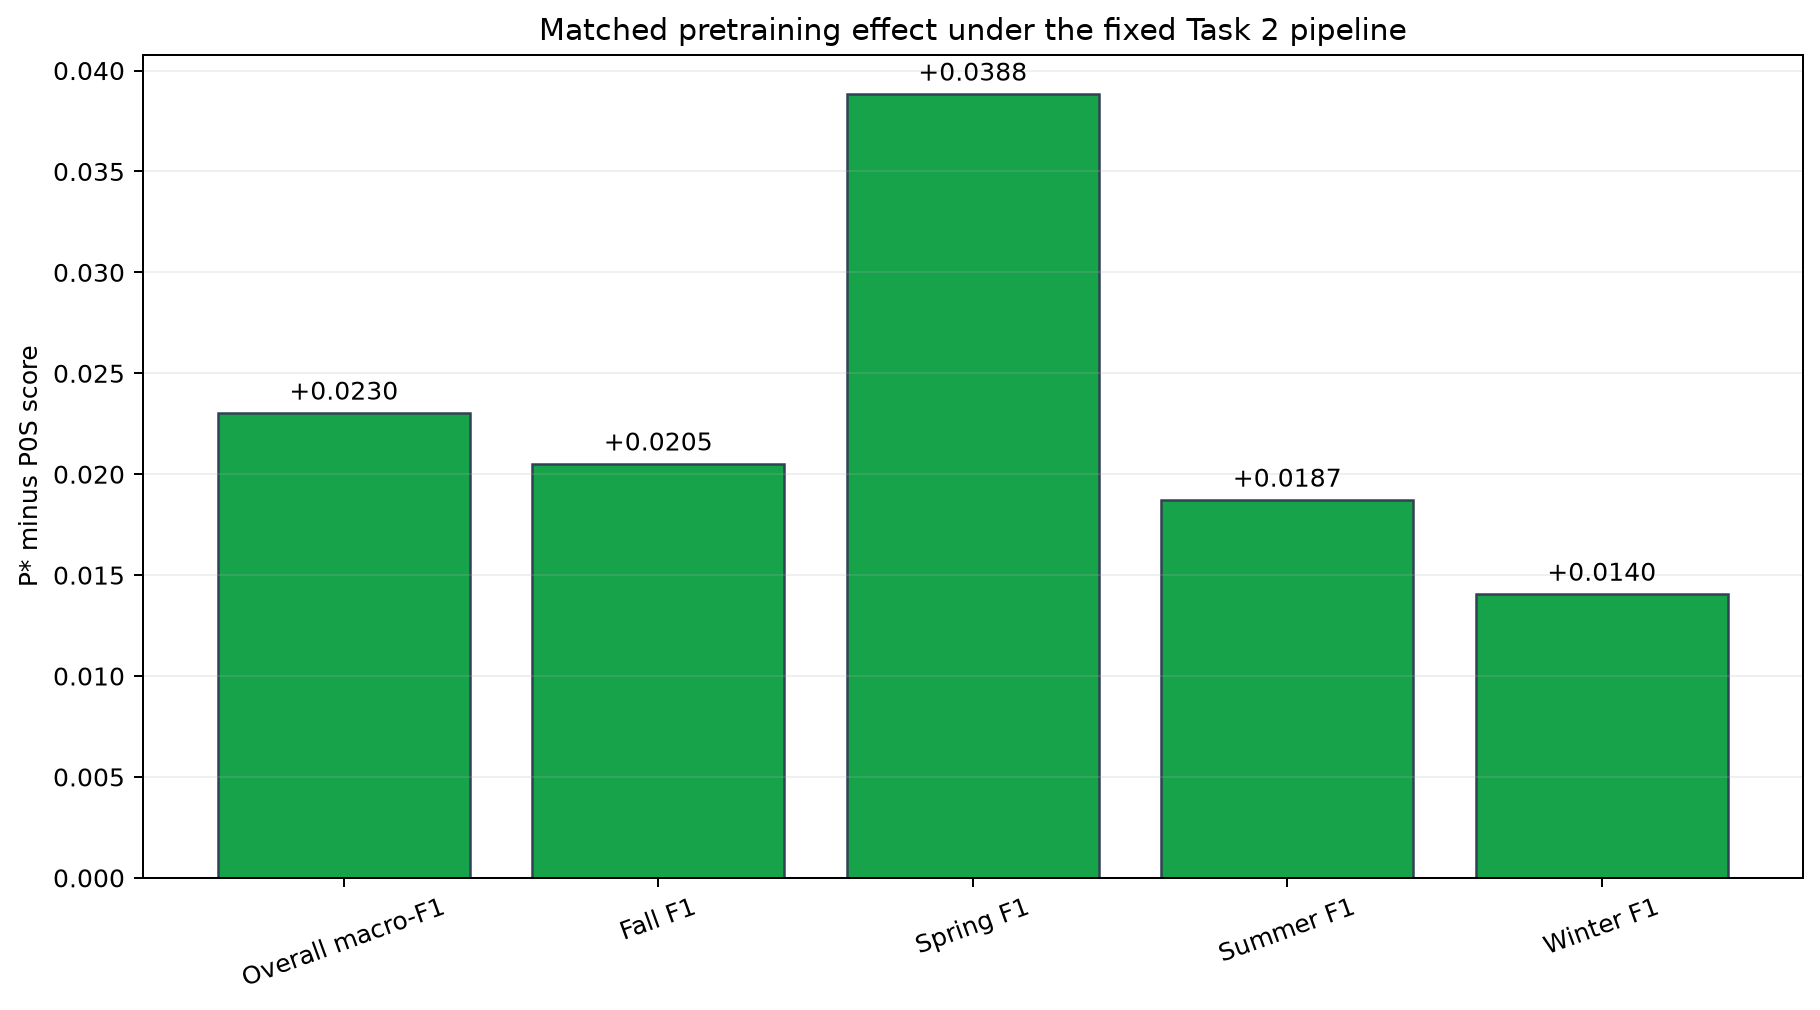

In [30]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.evidence import build_experiment_evidence
from fashion.task2.experiments import load_experiment_config
from fashion.task2.pretraining import run_pretraining_matrix
from fashion.task2.pretraining_evidence import (
    build_pretraining_benchmark_evidence,
)
from fashion.train.registry import RunRegistry

pretraining_config_paths = (
    TASK2_CONFIG_DIR / "g4_p0s_resnet18_standard_scratch.json",
    TASK2_CONFIG_DIR / "g4_pstar_resnet18_standard_pretrained.json",
)
pretraining_configs = [
    load_experiment_config(path) for path in pretraining_config_paths
]
pretraining_outputs = run_pretraining_matrix(
    pretraining_configs,
    mode="run_or_load",
)
pretraining_probability_note = (
    "Uncalibrated softmax probabilities from the checkpoint selected by "
    "validation Season macro-F1."
)
pretraining_experiment_manifests = {}
for config in pretraining_configs:
    config_outputs = [
        output
        for output in pretraining_outputs
        if output.experiment_id == config.experiment_id
    ]
    evidence_slug = config.experiment_id.replace("-", "_")
    pretraining_experiment_manifests[config.experiment_id] = (
        build_experiment_evidence(
            config_outputs,
            registry_path=RUNS_CSV,
            expected_ids=season_development["id"],
            protected_ids=protected_ids,
            probability_note=pretraining_probability_note,
            calibration_claim_allowed=False,
            evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
            figure_directory=TASK2_FIGURE_DIR,
        )
    )

pretraining_manifest_paths = tuple(
    TASK2_EVIDENCE_DIR
    / config.experiment_id.replace("-", "_")
    / "manifest.json"
    for config in pretraining_configs
)
pretraining_manifest = build_pretraining_benchmark_evidence(
    experiment_manifest_paths=pretraining_manifest_paths,
    experiment_config_paths=pretraining_config_paths,
    project_root=ROOT,
    expected_row_count=len(season_development),
    evidence_directory=TASK2_EVIDENCE_DIR / "pretraining_benchmark",
    figure_directory=TASK2_FIGURE_DIR,
)

current_run_ids = {output.run_id for output in pretraining_outputs}
assert len(current_run_ids) == 10
assert all(
    manifest["coverage"]["row_count"] == len(season_development)
    for manifest in pretraining_experiment_manifests.values()
)
assert all(
    manifest["coverage"]["protected_id_count"] == 0
    for manifest in pretraining_experiment_manifests.values()
)

pretraining_registry = RunRegistry(RUNS_CSV)
pretraining_attempts = pd.concat(
    [
        pretraining_registry.find(experiment_id=config.experiment_id)
        for config in pretraining_configs
    ],
    ignore_index=True,
)
pretraining_current_attempts = pretraining_attempts.loc[
    pretraining_attempts["run_id"].isin(current_run_ids)
].copy()
assert len(pretraining_current_attempts) == 10
assert pretraining_current_attempts["status"].eq("completed").all()
assert not pretraining_attempts["status"].eq("running").any()
assert set(pretraining_current_attempts["fold"].astype(int)) == set(range(5))
assert set(pretraining_current_attempts["seed"].astype(int)) == {2753}
assert (
    pretraining_current_attempts["git_dirty"]
    .astype(str)
    .str.lower()
    .eq("false")
    .all()
)

pretraining_comparison = pd.read_csv(
    ROOT / pretraining_manifest["artifacts"]["comparison"]["path"]
)
pretraining_paired_folds = pd.read_csv(
    ROOT
    / pretraining_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
pretraining_per_class = pd.read_csv(
    ROOT
    / pretraining_manifest["artifacts"]["per_class_comparison"]["path"]
)
with (
    ROOT / pretraining_manifest["artifacts"]["decision"]["path"]
).open(encoding="utf-8") as handle:
    pretraining_decision = json.load(handle)

assert pretraining_manifest["gate"] == "G4-PSTAR"
assert pretraining_manifest["candidate_selection_affected"] is False
assert pretraining_manifest["ultimate_winner_frozen"] is False
assert pretraining_decision["p0s_benchmark_only"] is True
assert pretraining_decision["pstar_benchmark_only"] is True
assert pretraining_decision["pstar_final_eligible"] is False
assert len(pretraining_paired_folds) == 5
assert set(pretraining_per_class["label"]) == set(SEASON_LABELS)

display(
    pretraining_comparison.style.format(
        {
            "pooled_macro_f1": "{:.6f}",
            "fold_mean_macro_f1": "{:.6f}",
            "fold_sd_macro_f1": "{:.6f}",
            "spring_f1": "{:.6f}",
            "five_fold_runtime_minutes": "{:.2f}",
            "peak_vram_mb": "{:.1f}",
        }
    )
)
display(pretraining_paired_folds)
display(
    pretraining_per_class.style.format(
        {
            "f1_p0s": "{:.6f}",
            "f1_pstar": "{:.6f}",
            "pstar_minus_p0s_f1": "{:+.6f}",
        }
    )
)
display(pd.json_normalize(pretraining_decision, sep=".").transpose())
display(
    pretraining_current_attempts.loc[:, [
        "experiment_id",
        "fold",
        "run_id",
        "status",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values(["experiment_id", "fold"])
)
display(
    Image(
        filename=str(
            ROOT
            / pretraining_manifest["artifacts"]["learning_curves"]["path"]
        )
    )
)
display(
    Image(
        filename=str(
            ROOT
            / pretraining_manifest["artifacts"]["effect_figure"]["path"]
        )
    )
)

> **Interpretation:** **Incremental question:** B0 exposed class imbalance, B1 proved that hand-built shape and colour features contain real Season signal, and the scratch C1/C2 path then learned stronger image features. The matched P0S/P* pair now isolates one further question: with the same standard-stem ResNet18, folds, P0/A0 transform, optimiser, loss, budget, and seed, what changes when only the initial weights come from ImageNet? Both rows are benchmark-only and final-ineligible; Notebook 01/data preparation is unchanged. **Result:** P0S reached `0.731172` pooled five-fold OOF macro-F1 and P* reached `0.754196`, an observed `+0.023024` effect. Spring F1 improved by `+0.038829`, the largest class gain, and all five paired folds favoured P*. Median best epoch fell from `22` to `11`, while five-fold runtime fell from `32.47` to `22.69` minutes because early stopping ended the pretrained runs sooner; parameter count and peak VRAM stayed matched. **Learning curves:** the teacher-style chart shows train/validation loss on the left and validation accuracy/macro-F1 on the right, with five-fold mean plus/minus one SD. It uses common horizons of 20 epochs for P0S and 12 for P*, so late curves are not biased toward folds that simply ran longer. In both rows, training loss keeps falling after validation scores flatten, and validation loss eventually rises; this supports best-macro-F1 checkpointing and early stopping. P* reaches its plateau sooner and higher. **EDA reflection:** the earlier EDA view that colour and shape provide useful but incomplete Season evidence was accurate: learned representations beat B1, and P* improves every class. The expectation that the development set alone would let the standard-stem scratch model close the representation gap was too optimistic. This matched pair estimates an initialisation effect only inside the fixed `80x60` pipeline; it does not prove that P* is better than I2 because their architecture and loss differ. **Decision:** use P* only as a benchmark ceiling. It cannot enter the eligible winner table, so candidate selection is unchanged and I2 lambda `0.3` remains the current scratch candidate. The ultimate winner is still open until seed `2026` stability and later analysis finish. **Limitations:** this gate uses one seed, the project transform is not the standard 224x224 ImageNet recipe, and probabilities remain uncalibrated. `ResNet18_Weights.DEFAULT` resolved to `ResNet18_Weights.IMAGENET1K_V1`. **Trace:** runs span `g4-p0s-resnet18-standard-scratch-f0-s2753-7db32dfd4d00` through `g4-p0s-resnet18-standard-scratch-f4-s2753-3a6604ca32a6` and `g4-pstar-resnet18-standard-pretrained-f0-s2753-ebc35155ebef` through `g4-pstar-resnet18-standard-pretrained-f4-s2753-a15e79285ae2`. `results/evidence/task2/pretraining_benchmark/manifest.json` links both configs, all ten runs, OOF metrics, boundaries, learning curves, and effect chart by SHA-256.

### 8.4 G5 second-seed stability

A second seed checks whether the final ordering depends on random initialisation.

,candidate,variant,experiment_id,seed,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,accuracy,balanced_accuracy,spring_precision,spring_recall,spring_f1,five_fold_runtime_minutes,peak_vram_mb,parameter_count,median_best_epoch,implementation_sha256,config_sha256
0,C2,C2 ResNet18,g5-c2-t0-resnet18-s2026,2026,0.733137,0.732990,0.020605,0.742253,0.699451,0.928571,0.626035,0.747865,60.92,606.389160,11170884,15.000000,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1000b87a9806a2d09fe,7854db82a980c621ea430b8111036083e178d403f7e371a188996d9a1e31899d
2,I2,I2 SmallCNN,g5-i2-article-type-lambda-0-3-c1-s2026,2026,0.744743,0.744764,0.015412,0.753855,0.712122,0.943503,0.628292,0.754291,26.44,189.508789,1206112,24.000000,877706919db28f917632f9250b1b40d446695f941fd226211246d69efd7838de,c1be80945739beccb3d47189ed79ab79592523105776e3898c82f645773879d7
1,C2,C2 ResNet18,g3-c2-t0-resnet18,2753,0.735036,0.734958,0.006340,0.747779,0.698980,0.917853,0.630549,0.747547,91.58,606.389160,11170884,24.000000,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1000b87a9806a2d09fe,1867b18890a586c213cedcb902344be3fab99d9c3f0f8bc0d854efbc55bc5887
3,I2,I2 SmallCNN,g4-i2-article-type-lambda-0-3-c1,2753,0.752687,0.752557,0.006752,0.762495,0.717178,0.934783,0.647103,0.764784,28.56,190.102539,1206112,24.000000,877706919db28f917632f9250b1b40d446695f941fd226211246d69efd7838de,28a122892bd80bf44b1dfa79abb6228e4160e430d25ec632386e3be68619eb4c


,candidate,macro_f1_s2753,macro_f1_s2026,macro_f1_s2026_minus_s2753,spring_recall_s2753,spring_recall_s2026,spring_recall_s2026_minus_s2753,spring_f1_s2753,spring_f1_s2026,spring_f1_s2026_minus_s2753
0,C2,0.735036,0.733137,-0.001899,0.630549,0.626035,-0.004515,0.747547,0.747865,+0.000318
1,I2,0.752687,0.744743,-0.007944,0.647103,0.628292,-0.018811,0.764784,0.754291,-0.010493


,fold,c2_s2753_run_id,c2_s2753_macro_f1,c2_s2026_run_id,c2_s2026_macro_f1,i2_s2753_run_id,i2_s2753_macro_f1,i2_s2026_run_id,i2_s2026_macro_f1,i2_minus_c2_macro_f1_s2753,i2_minus_c2_macro_f1_s2026
0,0,g3-c2-t0-resnet18-f0-s2753-66ee7a85d5c6,0.734677,g5-c2-t0-resnet18-s2026-f0-s2026-5444e94d7f03,0.745280,g4-i2-article-type-lambda-0-3-c1-f0-s2753-902f...,0.748937,g5-i2-article-type-lambda-0-3-c1-s2026-f0-s202...,0.741096,0.014259,-0.004184
1,1,g3-c2-t0-resnet18-f1-s2753-dc728952f19f,0.730164,g5-c2-t0-resnet18-s2026-f1-s2026-4a70c208e6c1,0.696869,g4-i2-article-type-lambda-0-3-c1-f1-s2753-1e4b...,0.757574,g5-i2-article-type-lambda-0-3-c1-s2026-f1-s202...,0.749180,0.027410,0.052311
2,2,g3-c2-t0-resnet18-f2-s2753-80377ad03917,0.729693,g5-c2-t0-resnet18-s2026-f2-s2026-8a316de3c09e,0.738895,g4-i2-article-type-lambda-0-3-c1-f2-s2753-e4b6...,0.743012,g5-i2-article-type-lambda-0-3-c1-s2026-f2-s202...,0.755568,0.013320,0.016673
3,3,g3-c2-t0-resnet18-f3-s2753-7e8c480bec75,0.745444,g5-c2-t0-resnet18-s2026-f3-s2026-00bc83e754cd,0.737107,g4-i2-article-type-lambda-0-3-c1-f3-s2753-bc2e...,0.759774,g5-i2-article-type-lambda-0-3-c1-s2026-f3-s202...,0.758140,0.014330,0.021033
4,4,g3-c2-t0-resnet18-f4-s2753-7b3a3bf2d06e,0.734810,g5-c2-t0-resnet18-s2026-f4-s2026-b9ac258333f7,0.746800,g4-i2-article-type-lambda-0-3-c1-f4-s2753-8d21...,0.753486,g5-i2-article-type-lambda-0-3-c1-s2026-f4-s202...,0.719834,0.018677,-0.026967


,0
candidate_experiment_id_seed_2026,g5-i2-article-type-lambda-0-3-c1-s2026
candidate_experiment_id_seed_2753,g4-i2-article-type-lambda-0-3-c1
candidate_selection_affected,False
candidate_status,supported_across_two_seeds
comparator_experiment_id_seed_2026,g5-c2-t0-resnet18-s2026
comparator_experiment_id_seed_2753,g3-c2-t0-resnet18
current_candidate,I2
decision_status,closed
gate,G5-SEED
i2_minus_c2_macro_f1_seed_2026,0.011607


,candidate,seed,fold,run_id,git_commit,implementation_sha256
0,C2,2026,0,g5-c2-t0-resnet18-s2026-f0-s2026-5444e94d7f03,04ef69dfd72f1722638b7274f9f6e7bbac590a86,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1...
1,C2,2026,1,g5-c2-t0-resnet18-s2026-f1-s2026-4a70c208e6c1,04ef69dfd72f1722638b7274f9f6e7bbac590a86,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1...
2,C2,2026,2,g5-c2-t0-resnet18-s2026-f2-s2026-8a316de3c09e,04ef69dfd72f1722638b7274f9f6e7bbac590a86,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1...
3,C2,2026,3,g5-c2-t0-resnet18-s2026-f3-s2026-00bc83e754cd,04ef69dfd72f1722638b7274f9f6e7bbac590a86,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1...
4,C2,2026,4,g5-c2-t0-resnet18-s2026-f4-s2026-b9ac258333f7,04ef69dfd72f1722638b7274f9f6e7bbac590a86,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1...
5,C2,2753,0,g3-c2-t0-resnet18-f0-s2753-66ee7a85d5c6,47442a2bff0aa97561bd34e16322a9af987937c7,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1...
6,C2,2753,1,g3-c2-t0-resnet18-f1-s2753-dc728952f19f,47442a2bff0aa97561bd34e16322a9af987937c7,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1...
7,C2,2753,2,g3-c2-t0-resnet18-f2-s2753-80377ad03917,47442a2bff0aa97561bd34e16322a9af987937c7,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1...
8,C2,2753,3,g3-c2-t0-resnet18-f3-s2753-7e8c480bec75,47442a2bff0aa97561bd34e16322a9af987937c7,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1...
9,C2,2753,4,g3-c2-t0-resnet18-f4-s2753-7b3a3bf2d06e,47442a2bff0aa97561bd34e16322a9af987937c7,2887c38cd5653b64b57c880880a7fdf9d6aa590a4e4bd1...


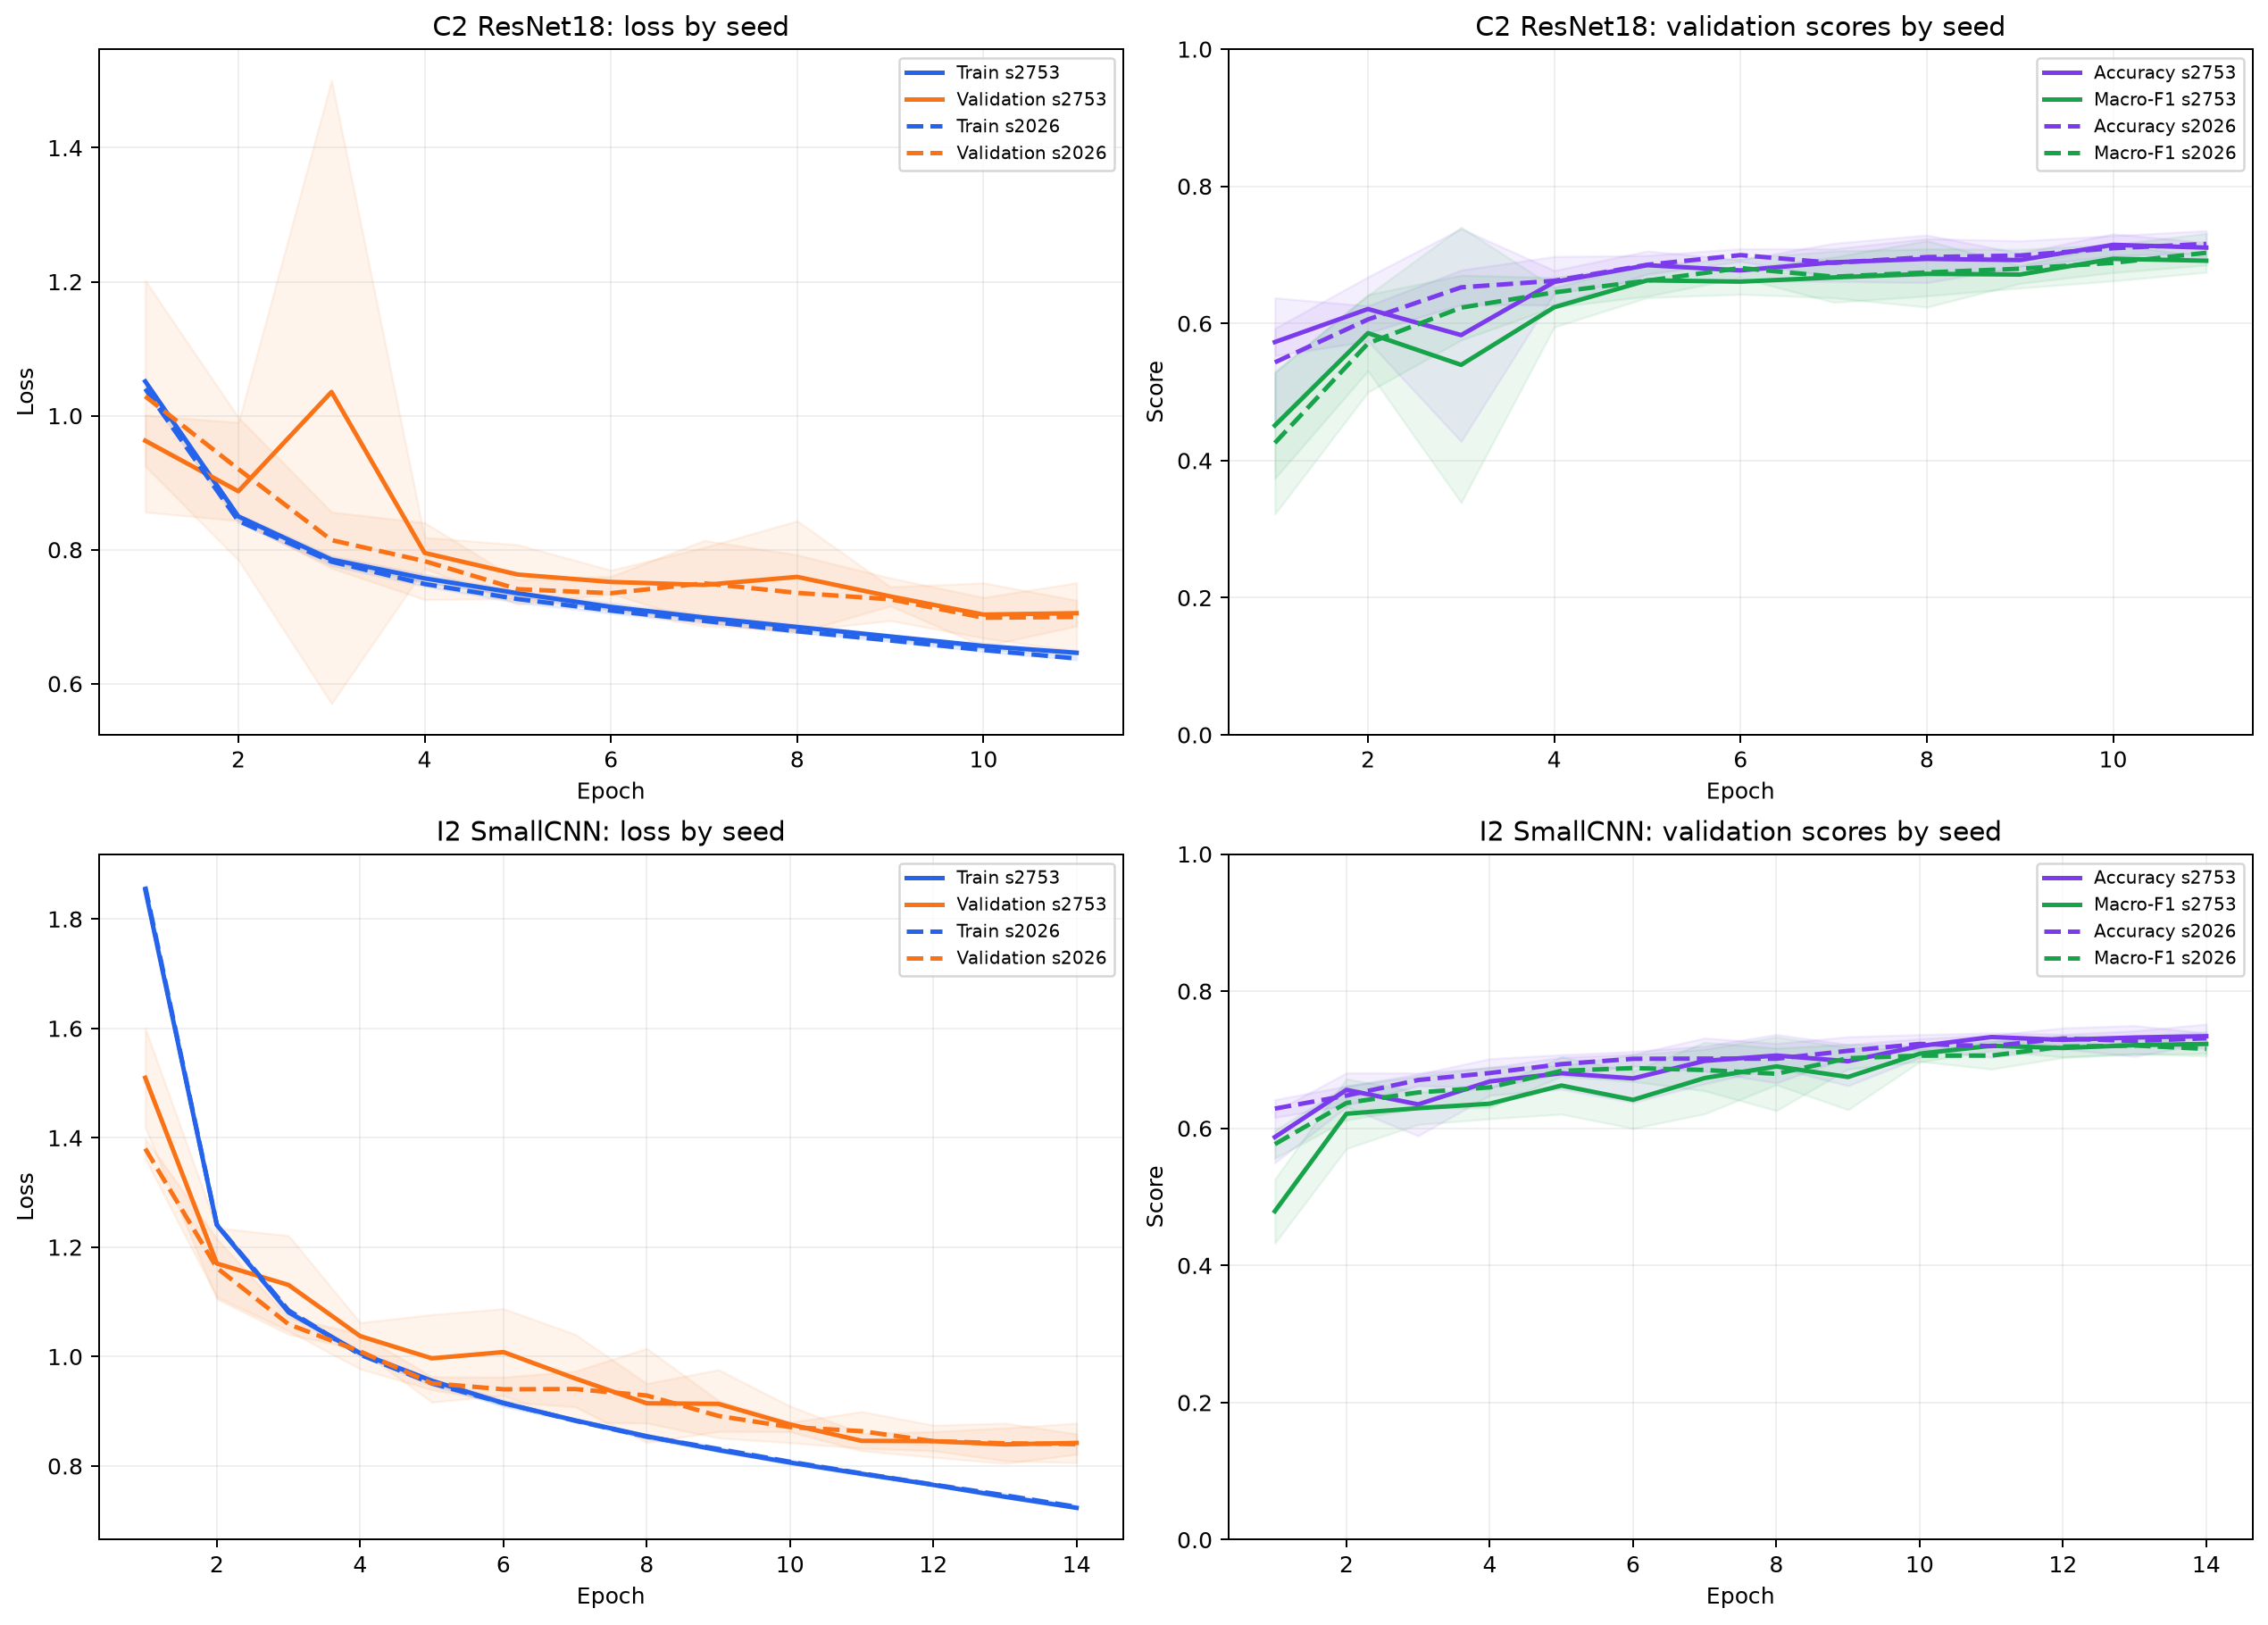

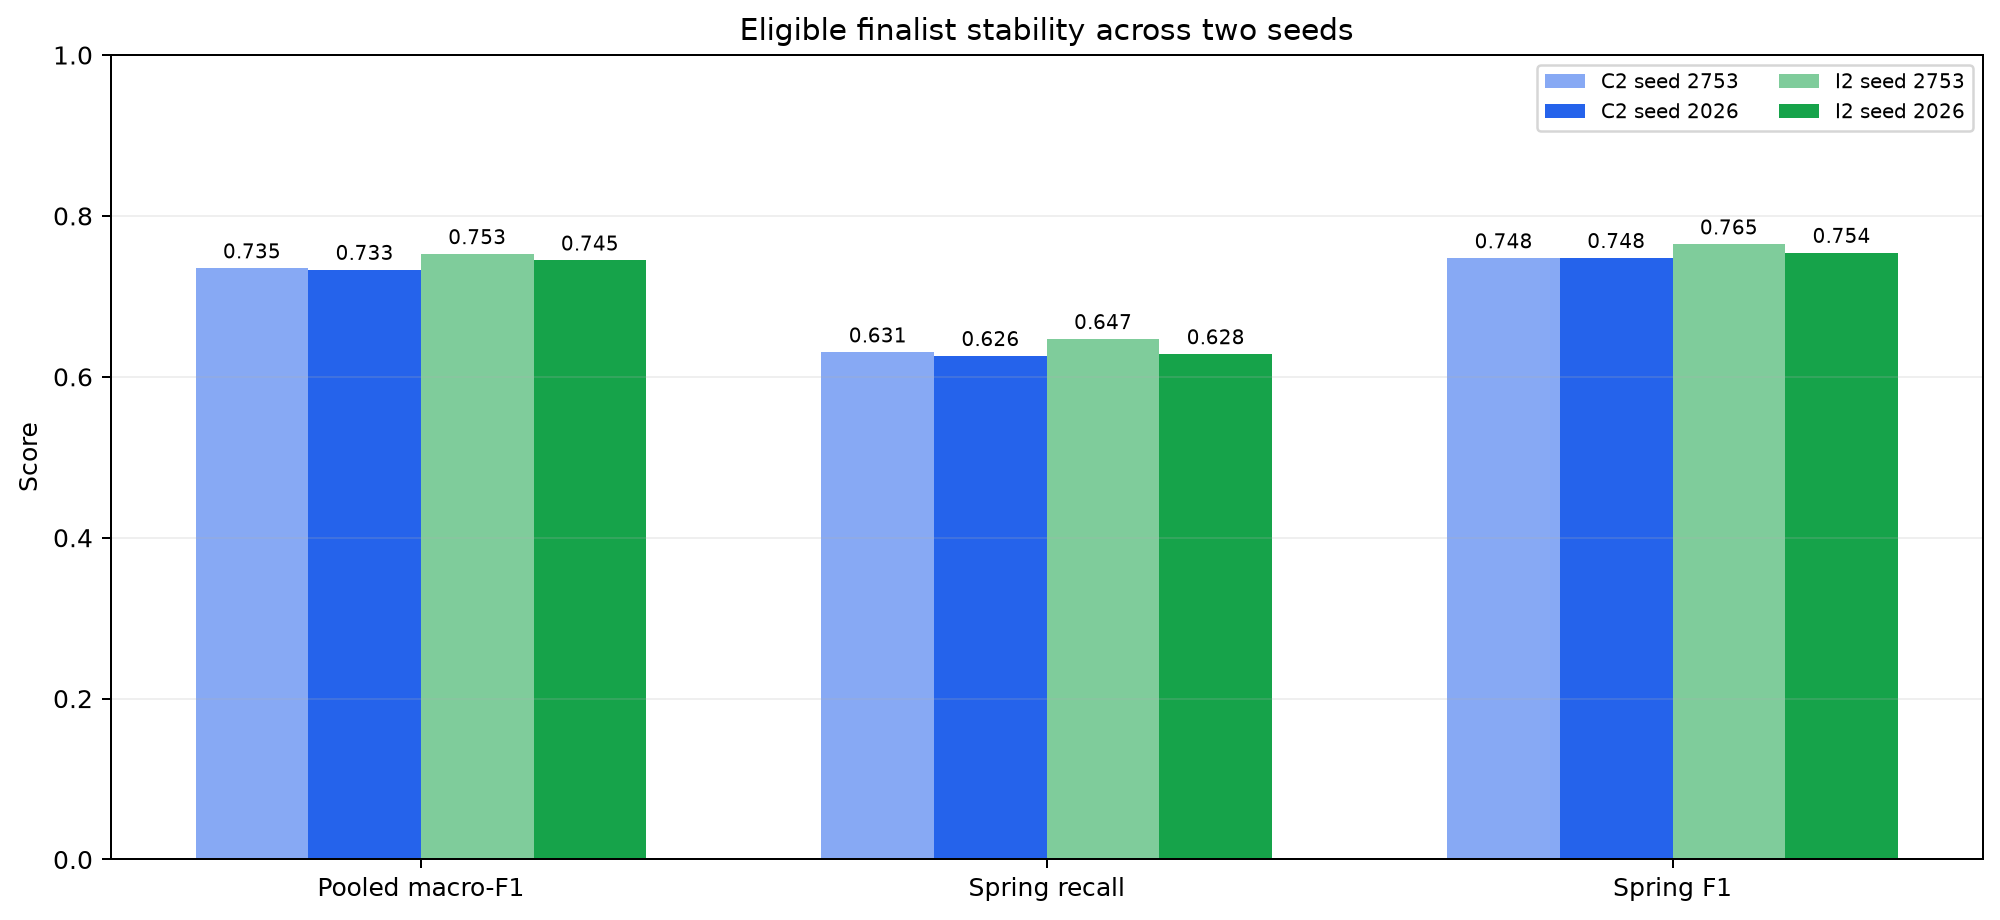

In [31]:
from IPython.display import Image

from fashion.train.artifacts import verify_artifact

stability_root = TASK2_EVIDENCE_DIR / "seed_stability"
stability_manifest_path = stability_root / "manifest.json"
with stability_manifest_path.open(encoding="utf-8") as handle:
    stability_manifest = json.load(handle)

for artifact_group in ("artifacts", "input_configs", "input_manifests"):
    for artifact in stability_manifest[artifact_group].values():
        verify_artifact(ROOT / artifact["path"], artifact["sha256"])

input_manifests = {}
for experiment_id, artifact in stability_manifest["input_manifests"].items():
    with (ROOT / artifact["path"]).open(encoding="utf-8") as handle:
        input_manifests[experiment_id] = json.load(handle)
assert all(
    manifest["coverage"]["row_count"] == len(season_development)
    for manifest in input_manifests.values()
)
assert all(
    manifest["coverage"]["protected_id_count"] == 0
    for manifest in input_manifests.values()
)

artifact_paths = {
    name: ROOT / artifact["path"]
    for name, artifact in stability_manifest["artifacts"].items()
}
seed_stability = pd.read_csv(artifact_paths["seed_stability"])
seed_drift = pd.read_csv(artifact_paths["seed_drift"])
paired_folds = pd.read_csv(artifact_paths["paired_fold_metrics"])
stability_registry = pd.read_csv(artifact_paths["registry_snapshot"])
with artifact_paths["decision"].open(encoding="utf-8") as handle:
    stability_decision = json.load(handle)

assert stability_manifest["gate"] == "G5-SEED"
assert stability_manifest["ordering_stable"] is True
assert stability_manifest["ultimate_winner_frozen"] is False
assert stability_decision["current_candidate"] == "I2"
assert stability_decision["candidate_selection_affected"] is False
assert len(seed_stability) == 4
assert set(seed_stability["candidate"]) == {"C2", "I2"}
assert set(seed_stability["seed"].astype(int)) == {2753, 2026}
assert len(paired_folds) == 5
assert len(stability_registry) == 20
assert stability_registry["status"].eq("completed").all()
assert stability_registry["git_dirty"].astype(str).str.lower().eq("false").all()
assert set(stability_registry["fold"].astype(int)) == set(range(5))
for seed in (2753, 2026):
    scores = (
        seed_stability.loc[seed_stability["seed"].eq(seed)]
        .set_index("candidate")["pooled_macro_f1"]
    )
    assert scores["I2"] > scores["C2"]

display(
    seed_stability.sort_values(["seed", "candidate"]).style.format({
        "pooled_macro_f1": "{:.6f}",
        "fold_mean_macro_f1": "{:.6f}",
        "fold_sd_macro_f1": "{:.6f}",
        "spring_recall": "{:.6f}",
        "spring_f1": "{:.6f}",
        "five_fold_runtime_minutes": "{:.2f}",
    })
)
drift_formats = {
    column: "{:+.6f}"
    for column in seed_drift.columns
    if "minus" in column
}
display(seed_drift.style.format(drift_formats))
display(paired_folds)
display(pd.json_normalize(stability_decision, sep=".").transpose())
display(
    stability_registry.loc[:, [
        "candidate",
        "seed",
        "fold",
        "run_id",
        "git_commit",
        "implementation_sha256",
    ]].sort_values(["candidate", "seed", "fold"])
)
display(Image(filename=str(artifact_paths["learning_curves"])))
display(Image(filename=str(artifact_paths["comparison_figure"])))

> **Interpretation — result:** The pre-registered G5 rule is satisfied: I2 remains above the retained C2 comparator at both complete five-fold seeds. At seed `2753`, pooled OOF macro-F1 is `0.752687` for I2 and `0.735036` for C2 (`+0.017651`). At seed `2026`, it is `0.744743` versus `0.733137` (`+0.011607`). All four OOF packs contain exactly `32,753` development IDs, no protected ID, and five clean folds. The extra ten G5 runs are stored under commit `04ef69d`; the table above exposes every run ID and implementation hash.
>
> **Seed drift and honest limitation:** C2 changes by `-0.001899` macro-F1 across seeds, while I2 changes by `-0.007944`; therefore I2 keeps the lead but is more seed-sensitive. I2 beats C2 on three of five paired folds at seed `2026`, not all five. Its Spring F1 remains higher (`0.754291` versus `0.747865`), but the Spring-recall advantage narrows to only `+0.002257`. Two seeds support the direction of the decision; they do not prove that every random start will preserve it. Grouped bootstrap uncertainty is still pending.
>
> **Learning curves:** The teacher-style figure places train/validation loss on the left and validation accuracy/macro-F1 on the right. Solid lines are seed `2753`; dashed lines are seed `2026`; shaded bands show fold spread. Both models learn quickly and then plateau while training loss continues to fall, supporting best-macro-F1 checkpointing and early stopping. I2 is much smaller (`1,206,112` parameters versus `11,170,884`) and the seed-2026 five-fold run is faster (`26.44` versus `60.92` minutes), but cost is not yet the selection metric.
>
> **EDA reflection and incremental decision:** The EDA hypothesis that ArticleType carries useful Season-related visual structure was directionally accurate: the image-only auxiliary task improves pooled macro-F1 at both seeds. The stronger assumption that this gain would be uniform was inaccurate: two seed-2026 folds reverse, and the minority-class recall gain nearly disappears. This remains an association, not proof that ArticleType causes better Season representations, and aligned/conflict shortcut slices must still be tested. Keep I2 lambda `0.3` as the current eligible scratch candidate, add no new architecture after G5, and do **not** freeze the ultimate winner yet. Next run shortcut/error, robustness/cost, calibration, grouped-bootstrap, and Grad-CAM analysis. Trace: `results/evidence/task2/seed_stability/manifest.json` links the four configs, twenty runs, tables, and both figures by SHA-256.

## 9. Cross-validated results

Turn registry-backed OOF artifacts into the main comparison evidence.

### 9.1 OOF leaderboard and fold stability

The leaderboard must be generated from artifacts, not typed by hand.

In [ ]:
import json

import pandas as pd
from IPython.display import Image, display

from fashion.config import ROOT
from fashion.train.artifacts import verify_artifact


def load_verified_notebook_manifest(relative_path):
    manifest_path = ROOT / relative_path
    with manifest_path.open(encoding="utf-8") as handle:
        manifest = json.load(handle)
    artifact_paths = {}
    for name, declaration in manifest["artifacts"].items():
        assert set(declaration) == {"path", "sha256"}
        artifact_path = ROOT / declaration["path"]
        verify_artifact(artifact_path, declaration["sha256"])
        artifact_paths[name] = artifact_path
    return manifest, artifact_paths


stability_manifest, stability_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/seed_stability/manifest.json"
)
assert stability_manifest["gate"] == "G5-SEED"
assert stability_manifest["ordering_stable"] is True
assert stability_manifest["ultimate_winner_frozen"] is False

finalist_leaderboard = pd.read_csv(stability_artifacts["seed_stability"])
stability_registry = pd.read_csv(
    stability_artifacts["registry_snapshot"], dtype=str, keep_default_na=False
)
assert len(finalist_leaderboard) == 4
assert set(finalist_leaderboard["candidate"]) == {"C2", "I2"}
assert set(finalist_leaderboard["seed"]) == {2753, 2026}
assert len(stability_registry) == stability_registry["run_id"].nunique() == 20
assert stability_registry["status"].eq("completed").all()
assert stability_registry["git_dirty"].str.lower().eq("false").all()
for _, rows in stability_registry.groupby(["candidate", "seed"]):
    assert set(rows["fold"].astype(int)) == set(range(5))

finalist_scorecard = finalist_leaderboard.loc[
    :,
    [
        "candidate",
        "seed",
        "pooled_macro_f1",
        "accuracy",
        "balanced_accuracy",
        "fold_sd_macro_f1",
        "spring_f1",
        "parameter_count",
        "five_fold_runtime_minutes",
        "median_best_epoch",
    ],
].sort_values(["seed", "pooled_macro_f1"], ascending=[True, False])
display(finalist_scorecard)
display(Image(filename=str(stability_artifacts["comparison_figure"])))

> **Interpretation — measured evidence:** Every candidate/seed pack contains five completed, clean folds and exactly 32,753 OOF IDs; the 20 run IDs are in the verified registry snapshot. I2 leads C2 at both seeds: `0.752687` versus `0.735036` at seed `2753`, and `0.744743` versus `0.733137` at seed `2026`. The smaller second-seed margin and I2 drift of `-0.007944` stop this from becoming an all-seeds claim. I2 is also the practical model: `1,206,112` parameters versus C2's `11,170,884`, and primary-seed five-fold runtime `28.56` versus `91.58` minutes. I2 remains the current candidate; the ultimate winner is not frozen here. Trace: `results/evidence/task2/seed_stability/manifest.json`.

### 9.2 Per-class performance and confusion matrices

Per-class evidence shows whether overall improvement is real or only comes from Summer.

In [ ]:
candidate_evidence = {
    "C2": "results/evidence/task2/g3_c2_t0_resnet18/manifest.json",
    "I2": (
        "results/evidence/task2/g4_i2_article_type_lambda_0_3_c1/manifest.json"
    ),
}
per_class_parts = []
confusion_tables = {}
for candidate, manifest_path in candidate_evidence.items():
    candidate_manifest, candidate_artifacts = load_verified_notebook_manifest(
        manifest_path
    )
    assert candidate_manifest["coverage"]["row_count"] == 32753
    assert candidate_manifest["coverage"]["protected_id_count"] == 0
    assert len(candidate_manifest["run_ids"]) == 5
    metrics = pd.read_csv(candidate_artifacts["per_class_metrics"])
    assert metrics["label"].tolist() == ["Fall", "Spring", "Summer", "Winter"]
    metrics.insert(0, "candidate", candidate)
    per_class_parts.append(metrics)
    confusion_tables[candidate] = pd.read_csv(
        candidate_artifacts["confusion_matrix"]
    ).set_index("true_label")
    display(Image(filename=str(candidate_artifacts["figure"])))

per_class_finalists = pd.concat(per_class_parts, ignore_index=True)
display(per_class_finalists)
for candidate, confusion in confusion_tables.items():
    print(f"{candidate} count confusion matrix")
    display(confusion)

> **Interpretation — measured evidence:** I2 improves every class F1 over C2 at seed `2753`: Fall `+0.023211`, Spring `+0.017238`, Summer `+0.010526`, and Winter `+0.019631`. The largest error remains Fall -> Summer, reduced from `3,041` C2 rows to `2,685` I2 rows. Winter -> Summer also falls from `1,583` to `1,453`. Spring is still the hardest recall problem: I2 recovers `860/1,329` Spring rows (`0.647103` recall), while `314` go to Summer. The gain is therefore broad, but it does not remove the weak-visual-signal and minority-class limits. Each figure and table is tied to five run IDs in its verified manifest.

### 9.3 Calibration and learning behaviour

Confidence quality and epoch behaviour require different figures, so they are split below.

#### 9.3.1 Calibration and risk-coverage

Reliable confidence supports the app's human-review decision.

In [ ]:
calibration_manifest, calibration_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/calibration/manifest.json"
)
assert calibration_manifest["gate"] == "G6-CALIBRATION"
assert calibration_manifest["holdout_opened"] is False
assert calibration_manifest["cross_fitted_evaluation_claim_allowed"] is True
assert calibration_manifest["deployment_temperature_evaluation_claim_allowed"] is False
assert calibration_manifest["app_threshold_frozen"] is False
assert calibration_manifest["ultimate_winner_frozen"] is False

calibration_summary = pd.read_csv(calibration_artifacts["calibration_summary"])
review_budgets = pd.read_csv(calibration_artifacts["review_budget_summary"])
assert set(calibration_summary["support"]) == {32753}
assert set(calibration_summary["candidate"]) == {"C2", "I2"}
assert set(calibration_summary["calibration_method"]) == {
    "uncalibrated",
    "cross_fitted_temperature",
}
diagnostic_budget_20 = review_budgets.loc[
    review_budgets["calibration_method"].eq("cross_fitted_temperature")
    & review_budgets["review_budget"].eq(0.2)
].copy()
display(calibration_summary)
display(
    diagnostic_budget_20.loc[
        :,
        [
            "candidate",
            "review_rate",
            "coverage",
            "confidence_threshold",
            "selective_macro_f1",
            "selective_risk",
        ],
    ]
)
display(Image(filename=str(calibration_artifacts["calibration_reliability_figure"])))
display(Image(filename=str(calibration_artifacts["risk_coverage_figure"])))

> **Interpretation — measured evidence:** Both raw models are overconfident. Five-fold cross-fitted temperature scaling leaves labels and macro-F1 unchanged but improves C2 NLL `0.665736 -> 0.638867` and ECE `0.057456 -> 0.011701`; I2 improves from NLL `0.632467 -> 0.608241` and ECE `0.046210 -> 0.016767`. At a diagnostic 20% review budget, retained-row macro-F1 is `0.808008` for C2 and `0.825837` for I2. This is a risk-coverage example, not an app policy: the threshold is not frozen because no business error cost was supplied. Only cross-fitted temperatures support evaluation claims; the scalar fitted on all OOF rows is future bundle metadata, and holdout remains sealed.

#### 9.3.2 Learning curves and epoch behaviour

Train and validation curves explain whether the fixed budget and refit epoch rule are reasonable.

In [ ]:
learning_curve_summary = pd.read_csv(
    stability_artifacts["learning_curve_summary"]
)
assert learning_curve_summary["fold_count"].eq(5).all()
assert set(learning_curve_summary["candidate"]) == {"C2", "I2"}
primary_seed_epochs = finalist_leaderboard.loc[
    finalist_leaderboard["seed"].eq(2753),
    ["candidate", "median_best_epoch", "fold_sd_macro_f1"],
].sort_values("candidate")
assert primary_seed_epochs["median_best_epoch"].tolist() == [24.0, 24.0]
common_horizons = (
    learning_curve_summary.groupby(["candidate", "seed"], observed=True)
    ["common_five_fold_horizon"]
    .first()
    .rename("common_five_fold_horizon")
    .reset_index()
)
display(primary_seed_epochs)
display(common_horizons)
display(Image(filename=str(stability_artifacts["learning_curves"])))

> **Interpretation — measured evidence:** The teacher-style chart keeps all five folds at every shown epoch: common horizons are 11 epochs for C2 and 14 for I2 across both seeds. Training loss keeps falling after validation loss and validation macro-F1 begin to flatten or vary, so the best-validation-macro-F1 checkpoint and patience rule are justified. The median best epoch is `24` for both primary-seed candidates. If the scorecard selects either one, refit therefore uses 24 development epochs; this value comes only from CV history, never holdout. Train and validation loss are not compared numerically across C2 and I2 because I2 includes an auxiliary loss.

## 10. Error and shortcut analysis

Test the exact weaknesses identified by EDA using OOF predictions only.

### 10.1 Spring and ArticleType shortcut slices

Minority-class failure and shortcut conflict are distinct analyses, so each has its own code cell.

#### 10.1.1 Spring minority analysis

Spring needs direct evidence because it represents only 4.06% of valid labels.

In [ ]:
slice_manifest, slice_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/shortcut_error_slices/manifest.json"
)
assert slice_manifest["gate"] == "G6-SLICE"
assert slice_manifest["decision_status"] == "closed"
assert slice_manifest["analysis_role"] == "development_oof_diagnosis_only"
assert slice_manifest["candidate_selection_affected"] is False
assert slice_manifest["ultimate_winner_frozen"] is False

spring_metrics = pd.read_csv(slice_artifacts["spring_metrics"])
spring_destinations = pd.read_csv(slice_artifacts["spring_destinations"])
assert set(spring_metrics["candidate"]) == {"C2", "I2"}
assert set(spring_metrics["seed"]) == {2753, 2026}
assert spring_metrics["support"].eq(1329).all()
assert spring_metrics["main_error_destination"].eq("Summer").all()

baseline_manifests = {
    "B0 majority": "results/evidence/task2/b0_majority/manifest.json",
    "B1 HOG+HSV SVM": "results/evidence/task2/b1_hog_hsv_svm/manifest.json",
}
spring_progression_rows = []
for stage, manifest_path in baseline_manifests.items():
    _, artifacts = load_verified_notebook_manifest(manifest_path)
    spring_row = pd.read_csv(artifacts["per_class_metrics"]).query(
        "label == 'Spring'"
    ).iloc[0]
    spring_progression_rows.append(
        {
            "stage": stage,
            "precision": spring_row["precision"],
            "recall": spring_row["recall"],
            "f1": spring_row["f1"],
            "support": spring_row["support"],
        }
    )
_, i1_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/i1_class_balance/manifest.json"
)
i1_spring = pd.read_csv(i1_artifacts["per_class_comparison"]).query(
    "label == 'Spring'"
).iloc[0]
for prefix, stage in (("reference", "C1 unweighted"), ("i1", "I1 balanced")):
    spring_progression_rows.append(
        {
            "stage": stage,
            "precision": i1_spring[f"{prefix}_precision"],
            "recall": i1_spring[f"{prefix}_recall"],
            "f1": i1_spring[f"{prefix}_f1"],
            "support": i1_spring[f"{prefix}_support"],
        }
    )
for candidate in ("C2", "I2"):
    row = spring_metrics.query("candidate == @candidate and seed == 2753").iloc[0]
    spring_progression_rows.append(
        {
            "stage": f"{candidate} seed 2753",
            "precision": row["precision"],
            "recall": row["recall"],
            "f1": row["f1"],
            "support": row["support"],
        }
    )
spring_progression = pd.DataFrame(spring_progression_rows)
display(spring_progression)
display(
    spring_metrics.loc[
        :,
        [
            "candidate",
            "seed",
            "precision",
            "recall",
            "f1",
            "mean_confidence",
            "error_mean_confidence",
            "main_error_destination",
            "main_error_count",
        ],
    ].sort_values(["seed", "candidate"])
)
display(Image(filename=str(slice_artifacts["spring_destinations_figure"])))

> **Interpretation — measured evidence:** The class-imbalance EDA warning was accurate: B0 ignores all `1,329` Spring rows (`F1 = 0`), while B1 proves that visual features can recover Spring (`F1 = 0.486901`). C1 reaches `0.744975`; I1 raises recall by `0.022573` but loses precision and falls to `0.702439`, so imbalance was real but class weighting was the wrong remedy. I2 reaches Spring F1 `0.764784` at seed `2753` and `0.754291` at seed `2026`, beating C2 by `+0.017238` and `+0.006426`. It still sends `314` and `332` Spring rows to Summer. The model no longer ignores Spring, but Spring remains visually ambiguous and needs class-specific reporting. Trace: `results/evidence/task2/shortcut_error_slices/manifest.json`.

#### 10.1.2 ArticleType aligned versus conflict

The conflict slice tests whether image performance survives when the ArticleType shortcut is wrong.

In [ ]:
slice_metrics = pd.read_csv(slice_artifacts["slice_metrics"])
slice_deltas = pd.read_csv(slice_artifacts["candidate_slice_deltas"])
article_type_audit = pd.read_csv(slice_artifacts["article_type_fold_audit"])
article_type_rows = slice_deltas.loc[
    slice_deltas["slice_family"].eq("article_type_shortcut"),
    [
        "seed",
        "slice_name",
        "c2_support",
        "c2_macro_f1",
        "i2_macro_f1",
        "i2_minus_c2_macro_f1",
        "c2_mean_confidence",
        "i2_mean_confidence",
    ],
].copy()
assert set(article_type_rows["slice_name"]) == {
    "aligned",
    "conflict",
    "missing_article_type",
    "unseen_article_type",
}
missing_article_type = article_type_rows.loc[
    article_type_rows["slice_name"].eq("missing_article_type")
]
assert missing_article_type["c2_support"].eq(0).all()
assert missing_article_type[["c2_macro_f1", "i2_macro_f1"]].isna().all().all()
assert len(article_type_audit) == 5
assert set(article_type_audit["fold"]) == set(range(5))
assert article_type_audit["training_id_sha256"].nunique() == 5
assert (
    article_type_audit["training_products"]
    == article_type_audit["auxiliary_training_products"]
).all()
display(article_type_audit)
display(article_type_rows.sort_values(["seed", "slice_name"]))
display(Image(filename=str(slice_artifacts["slice_macro_f1_figure"])))

> **Interpretation — measured evidence:** The EDA shortcut warning is accurate: aligned rows score about `0.85-0.87` macro-F1, but the same frozen models fall to `0.40-0.43` on `11,619` conflict rows. I2 nevertheless improves both groups at both seeds. Its conflict gain over C2 is `+0.024830` at seed `2753` and `+0.026993` at seed `2026`, larger than its aligned gains (`+0.008887` and `+0.009981`). This weakens the claim that I2 only memorises the ArticleType shortcut; it does not remove shortcut risk because conflict performance remains poor. The `19` unseen-ArticleType rows are too small to judge. Every mapping was fitted on the matching training fold, and true ArticleType is never an inference input.

### 10.2 Acquisition year and compression slices

Acquisition era and file compression are separate shortcut warnings and are analysed independently.

#### 10.2.1 Acquisition-year slice

The year slice tests the strong collection-era association found in development EDA.

In [ ]:
year_rows = slice_deltas.loc[
    slice_deltas["slice_family"].eq("acquisition_year")
    & slice_deltas["slice_name"].ne("missing_year"),
    [
        "seed",
        "slice_name",
        "c2_support",
        "c2_accuracy",
        "i2_accuracy",
        "c2_macro_f1",
        "i2_macro_f1",
        "i2_minus_c2_macro_f1",
        "c2_mean_confidence",
        "i2_mean_confidence",
    ],
].copy()
assert set(year_rows["slice_name"]) == {"dominant_2011_2012", "other_years"}
assert set(year_rows["c2_support"]) == {22896, 9857}
year_contrasts = pd.read_csv(slice_artifacts["slice_contrasts"]).query(
    "slice_family == 'acquisition_year'"
)
assert len(year_contrasts) == 4
display(year_rows.sort_values(["seed", "slice_name"]))
display(
    year_contrasts.loc[
        :,
        [
            "candidate",
            "seed",
            "reference_macro_f1",
            "comparison_macro_f1",
            "comparison_minus_reference_macro_f1",
        ],
    ]
)

> **Interpretation — measured evidence:** The acquisition-era EDA warning is supported, but its simple story is not. The `22,896` rows from 2011-2012 have higher accuracy yet much lower macro-F1 than the `9,857` other-year rows: I2 seed `2753` is `0.774764` versus `0.733996` accuracy, but `0.591334` versus `0.682438` macro-F1. This metric reversal shows that era and class mix interact; it does not show that old images cause a prediction. I2 improves the dominant-era macro-F1 by `+0.042406` at seed `2753` and `+0.034396` at seed `2026`, while other-year gains are smaller. Year was joined only after OOF prediction and is never a model feature.

#### 10.2.2 Training-fitted file-size slice

File-size quartiles test sensitivity to compression traces without using file bytes as a feature.

In [ ]:
file_size_boundaries = pd.read_csv(slice_artifacts["file_size_boundaries"])
file_size_rows = slice_deltas.loc[
    slice_deltas["slice_family"].eq("file_size_quartile"),
    [
        "seed",
        "slice_name",
        "c2_support",
        "c2_macro_f1",
        "i2_macro_f1",
        "i2_minus_c2_macro_f1",
        "c2_mean_confidence",
        "i2_mean_confidence",
    ],
].copy()
assert len(file_size_boundaries) == 5
assert set(file_size_boundaries["fold"]) == set(range(5))
assert file_size_boundaries["training_id_sha256"].nunique() == 5
assert file_size_boundaries["training_products"].between(26201, 26203).all()
assert set(file_size_rows["slice_name"]) == {
    "q1_smallest",
    "q2",
    "q3",
    "q4_largest",
}
display(file_size_boundaries)
display(file_size_rows.sort_values(["seed", "slice_name"]))

> **Interpretation — measured evidence:** The file-size EDA warning is supported as a risk, not as causation. The smallest-file quartile is consistently harder than the largest: at seed `2753`, C2 rises from `0.651847` to `0.708408` macro-F1 and I2 from `0.682055` to `0.720897`; the I2 gap is `0.038842` (`0.043815` at seed `2026`). The middle quartiles are not monotonic, so file size is not a simple quality scale. Each fold uses only its `26,201-26,203` training rows to fit q25/q50/q75 boundaries; file bytes are never supplied to the CNN. The result motivates the controlled JPEG probe in Section 11, not a metadata feature.

### 10.3 Family-size and image-mode slices

Related-product structure and rare image mode answer different generalisation questions.

#### 10.3.1 Product-family size slice

This slice checks whether results are stronger for products with related rows.

In [ ]:
family_rows = slice_deltas.loc[
    slice_deltas["slice_family"].eq("product_family_size"),
    [
        "seed",
        "slice_name",
        "c2_support",
        "c2_accuracy",
        "i2_accuracy",
        "c2_macro_f1",
        "i2_macro_f1",
        "i2_minus_c2_macro_f1",
    ],
].copy()
family_contrasts = pd.read_csv(slice_artifacts["slice_contrasts"]).query(
    "slice_family == 'product_family_size'"
)
assert set(family_rows["slice_name"]) == {"singleton", "multirow"}
assert set(family_rows["c2_support"]) == {19023, 13730}
assert len(family_contrasts) == 4
display(family_rows.sort_values(["seed", "slice_name"]))
display(
    family_contrasts.loc[
        :,
        [
            "candidate",
            "seed",
            "reference_macro_f1",
            "comparison_macro_f1",
            "comparison_minus_reference_macro_f1",
        ],
    ]
)

> **Interpretation — measured evidence:** Quality does not improve on the multi-row family slice. I2 scores `0.750922` on `19,023` singleton rows versus `0.741507` on `13,730` multi-row rows at seed `2753`; the multi-row-minus-singleton gap is `-0.009415` and repeats as `-0.011120` at seed `2026`. C2 shows the same small direction. This weakens the concern that aggregate quality depends on related products. It does not prove independence: `product_family_group` is a conservative split group, not a verified SKU identity, and the folds already prevent a group from crossing training and validation.

#### 10.3.2 Greyscale versus RGB slice

Rare greyscale images may reveal colour dependence or transform problems.

In [ ]:
image_mode_rows = slice_deltas.loc[
    slice_deltas["slice_family"].eq("image_mode"),
    [
        "seed",
        "slice_name",
        "c2_support",
        "c2_accuracy",
        "i2_accuracy",
        "c2_macro_f1",
        "i2_macro_f1",
        "i2_minus_c2_macro_f1",
        "c2_mean_confidence",
        "i2_mean_confidence",
    ],
].copy()
assert set(image_mode_rows["slice_name"]) == {"greyscale", "rgb", "other_mode"}
assert set(image_mode_rows["c2_support"]) == {0, 294, 32459}
other_mode = image_mode_rows.loc[image_mode_rows["slice_name"].eq("other_mode")]
assert other_mode["c2_support"].eq(0).all()
assert other_mode[["c2_macro_f1", "i2_macro_f1"]].isna().all().all()
greyscale_deltas = image_mode_rows.loc[
    image_mode_rows["slice_name"].eq("greyscale"),
    "i2_minus_c2_macro_f1",
]
assert (greyscale_deltas.min() < 0) and (greyscale_deltas.max() > 0)
display(image_mode_rows.sort_values(["seed", "slice_name"]))

> **Interpretation — measured evidence:** Greyscale is harder than RGB for both candidates, but only `294` greyscale rows exist. More importantly, I2 versus C2 reverses across seeds: `-0.045315` macro-F1 at seed `2753`, then `+0.080164` at seed `2026`. The EDA colour/transform warning therefore remains plausible, while any winner claim from this rare slice is rejected. Together with A1 colour jitter hurting the main score, the safe conclusion is that colour may carry real Season signal and should not be aggressively distorted. All images are still converted to RGB by the shared transform; this slice uses the structural audit only after prediction.

## 11. Robustness and efficiency

Measure controlled image degradation and the practical cost of the final candidates.

### 11.1 Deterministic perturbation tests

JPEG, brightness, and blur tests check whether mild real-world changes break the same frozen model.

In [ ]:
robustness_manifest, robustness_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/robustness_cost/manifest.json"
)
assert robustness_manifest["gate"] == "G6-ROBUSTNESS-COST"
assert robustness_manifest["decision_status"] == "closed"
assert robustness_manifest["git_dirty"] is False
assert (
    robustness_manifest["analysis_role"]
    == "development_stress_and_machine_cost_diagnosis_only"
)
assert robustness_manifest["candidate_selection_affected"] is False
assert robustness_manifest["ultimate_winner_frozen"] is False

robustness_metrics = pd.read_csv(robustness_artifacts["pooled_metrics"])
robustness_comparison = pd.read_csv(
    robustness_artifacts["candidate_comparison"]
)
clean_reconciliation = pd.read_csv(
    robustness_artifacts["clean_reconciliation"]
)
probe_registry = pd.read_csv(
    robustness_artifacts["probe_registry"], dtype=str, keep_default_na=False
)
expected_conditions = {
    "clean",
    "jpeg_quality_85",
    "brightness_0_85",
    "brightness_1_15",
    "gaussian_blur_radius_1",
}
assert set(robustness_metrics["candidate"]) == {"C2", "I2"}
assert set(robustness_metrics["condition"]) == expected_conditions
assert robustness_metrics["support"].eq(32753).all()
assert len(probe_registry) == probe_registry["probe_id"].nunique() == 50
assert probe_registry["status"].eq("completed").all()
assert clean_reconciliation["prediction_agreement"].eq(1.0).all()
assert clean_reconciliation["maximum_probability_delta"].eq(0.0).all()
display(
    robustness_metrics.loc[
        :,
        [
            "candidate",
            "condition",
            "macro_f1",
            "delta_macro_f1_vs_clean",
            "spring_recall",
            "prediction_agreement_with_clean",
            "material_macro_f1_degradation",
        ],
    ]
)
display(robustness_comparison)
display(Image(filename=str(robustness_artifacts["robustness_figure"])))

> **Interpretation — measured evidence:** Darkening to brightness `0.85` is the worst stress for both models: C2 falls from `0.735036` to `0.337542` macro-F1 and I2 from `0.752687` to `0.363961`; clean-label agreement is only `0.512625` and `0.614112`. JPEG quality 85 is mildest, but still costs `0.012671` C2 and `0.022496` I2 macro-F1. Blur and brightness `1.15` also cause material drops. I2 remains above C2 in every condition, yet its Spring recall almost vanishes under darkening (`0.003010`). This supports the EDA acquisition/colour warning and keeps I2 as the practical candidate, but it also requires a human-review path for shifted images. These are synthetic primary-seed stresses, not proof of all real-world robustness, and they do not reopen G5 selection or freeze a winner.

### 11.2 Deployment cost

Inference latency and resource size use different measurement protocols, so they are separated below. Seed stability is already handled in Section 8.4.

#### 11.2.1 Batch-one inference latency

The app serves one uploaded image at a time, so batch-one timing is the relevant cost.

In [ ]:
deployment_cost = pd.read_csv(robustness_artifacts["deployment_cost"])
with robustness_artifacts["runtime"].open(encoding="utf-8") as handle:
    robustness_runtime = json.load(handle)
assert len(deployment_cost) == 4
assert deployment_cost["available"].all()
assert set(deployment_cost["candidate"]) == {"C2", "I2"}
assert set(deployment_cost["device"]) == {"cpu", "cuda"}
assert deployment_cost["batch_size"].eq(1).all()
assert deployment_cost["model_only_warmups"].eq(30).all()
assert deployment_cost["model_only_repeats"].eq(200).all()
assert deployment_cost["end_to_end_warmups"].eq(10).all()
assert deployment_cost["end_to_end_repeats"].eq(50).all()
latency_view = deployment_cost.loc[
    :,
    [
        "candidate",
        "device",
        "model_only_median_ms",
        "model_only_p95_ms",
        "end_to_end_median_ms",
        "end_to_end_p95_ms",
        "model_only_throughput_per_second_at_median",
    ],
].sort_values(["device", "candidate"])
hardware_view = pd.DataFrame(
    [
        {
            "platform": robustness_runtime["platform"],
            "python": robustness_runtime["python"],
            "cpu_threads": robustness_runtime["logical_cpu_count"],
            "gpu": robustness_runtime["gpu"]["name"],
            "cuda_runtime": robustness_runtime["cuda_runtime"],
        }
    ]
)
display(hardware_view)
display(latency_view)

> **Interpretation — measured evidence:** Both models are fast enough for one-image interaction on the recorded machine, and I2 is clearly faster. Warm batch-one end-to-end median/p95 is `6.493/7.069 ms` on one CPU thread for I2 versus `47.357/51.721 ms` for C2. On the RTX 4070 Laptop GPU it is `1.882/2.198 ms` versus `3.052/3.301 ms`. Model-only medians show the same order: `6.547` versus `47.976 ms` on CPU and `1.312` versus `2.246 ms` on CUDA. Preprocessing is included only in the end-to-end columns; training and data loading are excluded. These warm-cache numbers are machine-specific, not universal service latency.

#### 11.2.2 Model and training resource cost

Model size, RAM/VRAM, and training time complete the practical comparison.

In [ ]:
primary_resources = finalist_leaderboard.loc[
    finalist_leaderboard["seed"].eq(2753),
    [
        "candidate",
        "pooled_macro_f1",
        "parameter_count",
        "peak_vram_mb",
        "five_fold_runtime_minutes",
    ],
].copy()
storage_cost = (
    deployment_cost.loc[
        deployment_cost["device"].eq("cpu"),
        [
            "candidate",
            "parameter_and_buffer_bytes",
            "training_checkpoint_bytes",
            "process_rss_before_bytes",
            "process_rss_after_inference_bytes",
            "process_rss_delta_bytes",
        ],
    ]
    .drop_duplicates("candidate")
    .copy()
)
cuda_memory = deployment_cost.loc[
    deployment_cost["device"].eq("cuda"),
    ["candidate", "peak_cuda_allocated_bytes"],
].copy()
resource_scorecard = (
    primary_resources.merge(storage_cost, on="candidate", validate="one_to_one")
    .merge(cuda_memory, on="candidate", validate="one_to_one")
    .sort_values("candidate")
)
for _, row in resource_scorecard.iterrows():
    expected = deployment_cost.loc[
        deployment_cost["candidate"].eq(row["candidate"]),
        "parameter_count",
    ]
    assert expected.eq(row["parameter_count"]).all()
assert resource_scorecard["candidate"].tolist() == ["C2", "I2"]
display(resource_scorecard)
display(Image(filename=str(robustness_artifacts["deployment_cost_figure"])))

> **Interpretation — measured evidence:** I2 improves primary-seed macro-F1 by `0.017651` while using less of every stable resource measure. It has `1,206,112` parameters versus `11,170,884`; parameter/buffer storage is `4,832,192` versus `44,722,096` bytes (`0.108x`), and its training checkpoint is `14,521,135` versus `134,179,223` bytes. Five-fold training took `28.56` versus `91.58` minutes and peak training VRAM was `190.10` versus `606.39 MiB`. The isolated CUDA latency probe also peaks at about `15.9` versus `61.7 MiB`. Process RSS is shown for completeness but is not used to rank models because separate Python processes start with different allocator state. Here the quality gain does not need to justify extra cost: I2 is both better and cheaper.

## 12. Explainability and failure cases

Use deterministic examples to understand where the model looks and why it fails.

### 12.1 Select representative examples deterministically

Fixed selection prevents cherry-picking attractive successes or dramatic failures.

In [ ]:
gradcam_manifest, gradcam_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/gradcam_failure_review/manifest.json"
)
assert gradcam_manifest["gate"] == "G6-GRADCAM-FAILURE-REVIEW"
assert gradcam_manifest["decision_status"] == "closed"
assert gradcam_manifest["git_dirty"] is False
assert gradcam_manifest["holdout_opened"] is False
assert gradcam_manifest["causal_failure_claim_allowed"] is False
assert gradcam_manifest["candidate_selection_affected"] is False
assert gradcam_manifest["ultimate_winner_frozen"] is False

selected_examples = pd.read_csv(gradcam_artifacts["selected_examples"])
heatmap_index = pd.read_csv(gradcam_artifacts["heatmap_index"])
gradcam_checkpoints = pd.read_csv(gradcam_artifacts["checkpoint_audit"])
assert len(selected_examples) == len(heatmap_index) == 48
assert selected_examples["id"].nunique() == 44
assert set(selected_examples["candidate"]) == {"C2", "I2"}
assert set(selected_examples["true_label"]) == {
    "Fall",
    "Spring",
    "Summer",
    "Winter",
}
assert set(selected_examples["selection_group"]) == {"correct", "incorrect"}
selection_counts = (
    selected_examples.groupby(
        ["candidate", "true_label", "selection_group"], observed=True
    )
    .size()
    .rename("selected_examples")
    .reset_index()
)
assert len(selection_counts) == 16
assert selection_counts["selected_examples"].eq(3).all()
assert heatmap_index["array_index"].tolist() == list(range(48))
assert gradcam_checkpoints["run_id"].nunique() == 8
display(selection_counts)
display(
    selected_examples.loc[
        :,
        [
            "candidate",
            "true_label",
            "selection_group",
            "selection_rank",
            "id",
            "fold",
            "predicted_label",
            "calibrated_confidence",
            "run_id",
        ],
    ]
)

> **Interpretation — measured evidence:** The predeclared rule selects exactly three high-confidence correct and three high-confidence incorrect OOF rows for every class and each candidate: `48` rows, `44` distinct images, and no class shortage. Confidence rank then ID fixes ties before any heatmap is viewed, preventing attractive maps from driving selection. Eight hash-verified checkpoint run IDs cover the folds containing these extremes; fold 2 simply contributes no selected extreme. This is balanced diagnostic coverage, not a random sample: the error counts below must never be read as population prevalence, and holdout remains sealed.

### 12.2 Generate Grad-CAM diagnostics

Grad-CAM can reveal whether the model attends to the product or to borders and background.

In [ ]:
attention_metrics = pd.read_csv(gradcam_artifacts["attention_metrics"])
assert len(attention_metrics) == 48
assert attention_metrics["zero_heatmap"].eq(False).all()
assert attention_metrics["attention_review_flag"].eq(False).all()
assert attention_metrics["probability_max_absolute_delta"].max() <= 1e-4
assert (
    attention_metrics["gradcam_target_label"]
    == attention_metrics["predicted_label"]
).all()
attention_summary = (
    attention_metrics.groupby("candidate", observed=True)
    .agg(
        examples=("id", "size"),
        mean_foreground_attention_share=("foreground_attention_share", "mean"),
        mean_foreground_attention_lift=("foreground_attention_lift", "mean"),
        mean_border_attention_lift=("border_attention_lift", "mean"),
        max_probability_delta=("probability_max_absolute_delta", "max"),
        zero_heatmaps=("zero_heatmap", "sum"),
        review_flags=("attention_review_flag", "sum"),
    )
    .reset_index()
)
display(attention_summary)
display(Image(filename=str(gradcam_artifacts["c2_contact_sheet"])))
display(Image(filename=str(gradcam_artifacts["i2_contact_sheet"])))

> **Interpretation — measured evidence:** All `48` predicted-class Grad-CAM maps are non-zero and reconcile to the frozen OOF probabilities within `1e-4`. Mean foreground attention share/lift is `0.633160/1.490200` for C2 and `0.642716/1.719056` for I2; mean border lift is below area share for both (`0.674038` and `0.623785`). No map crosses the declared empty-map or border/background review rule. The sheets therefore show useful product-focused sensitivity in these fixed cases, but zero flags do not prove that shortcuts are absent. Grad-CAM is coarse, the non-white foreground mask misses some white products, and a heatmap cannot establish why a prediction occurred or whether a region is causal.

### 12.3 Build the failure taxonomy

The rubric rewards honest analysis of limitations, not only successful examples.

In [ ]:
failure_taxonomy = pd.read_csv(gradcam_artifacts["failure_taxonomy"])
failure_summary = pd.read_csv(gradcam_artifacts["failure_taxonomy_summary"])
assert len(failure_taxonomy) == 24
assert failure_taxonomy["selection_group"].eq("incorrect").all()
assert failure_taxonomy["human_label_ambiguity_review_required"].eq(True).all()
assert set(failure_taxonomy["primary_failure_hypothesis"]) == {
    "article_type_shortcut_conflict",
    "weak_data_proxy",
}
assert failure_summary["selected_error_count"].sum() == 24
assert (
    failure_summary.groupby("candidate", observed=True)["selected_error_count"]
    .sum()
    .eq(12)
).all()
display(failure_summary)
display(
    failure_taxonomy.loc[
        :,
        [
            "candidate",
            "id",
            "true_label",
            "predicted_label",
            "calibrated_confidence",
            "articleType",
            "article_type_shortcut",
            "primary_failure_hypothesis",
            "diagnostic_tags",
            "run_id",
        ],
    ]
)

> **Interpretation — measured evidence:** Among the `12` deliberately severe errors per model, C2 is split between `6` ArticleType-shortcut conflicts and `6` weak-data proxies; I2 has `9` conflicts and `3` weak-data proxies. Every selected error also requires human ambiguity review because a catalogue image often cannot make Season objectively clear. The real-use problem is therefore not only model capacity: label ambiguity and metadata associations can produce very confident wrong answers. The app should show probabilities and flag uncertain or shifted cases for a person. These tags are review hypotheses, not causal labels or frequency estimates; human causal adjudication is not complete, and the failure review does not change candidate selection.

## 13. Statistical and external comparison

Measure uncertainty between finalists and compare literature only when assumptions are made explicit.

### 13.1 Paired family bootstrap

Rows inside a product family may be related, so uncertainty should preserve those blocks.

In [ ]:
bootstrap_manifest, bootstrap_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/paired_bootstrap/manifest.json"
)
assert bootstrap_manifest["gate"] == "G6-PAIRED-BOOTSTRAP"
assert bootstrap_manifest["decision_status"] == "closed"
assert bootstrap_manifest["git_dirty"] is False
assert bootstrap_manifest["holdout_opened"] is False
assert bootstrap_manifest["new_candidates_allowed"] is False
assert bootstrap_manifest["random_seed_generalisability_claim_allowed"] is False
assert bootstrap_manifest["candidate_selection_affected"] is False
assert bootstrap_manifest["ultimate_winner_frozen"] is False

bootstrap_intervals = pd.read_csv(bootstrap_artifacts["interval_summary"])
bootstrap_observed = pd.read_csv(bootstrap_artifacts["observed_metrics"])
bootstrap_groups = pd.read_csv(bootstrap_artifacts["group_audit"])
bootstrap_registry = pd.read_csv(
    bootstrap_artifacts["registry_snapshot"], dtype=str, keep_default_na=False
)
macro_intervals = bootstrap_intervals.loc[
    bootstrap_intervals["metric_scope"].eq("overall")
    & bootstrap_intervals["metric"].eq("macro_f1")
].copy()
assert len(bootstrap_intervals) == 12
assert len(macro_intervals) == 2
assert macro_intervals["replicates"].eq(10000).all()
assert macro_intervals["confidence_level"].eq(0.95).all()
assert macro_intervals["interval_contains_zero"].eq(False).all()
assert macro_intervals["observed_within_practical_tie"].eq(False).all()
assert bootstrap_groups.loc[0, "row_count"] == 32753
assert bootstrap_groups.loc[0, "unique_group_count"] == 22885
assert (
    bootstrap_groups.loc[0, "group_semantics"]
    == "conservative_dependency_block_not_verified_sku"
)
assert len(bootstrap_registry) == bootstrap_registry["run_id"].nunique() == 20
display(bootstrap_observed)
display(
    macro_intervals.loc[
        :,
        [
            "comparison_id",
            "seed",
            "observed_delta",
            "ci_lower",
            "ci_upper",
            "fraction_replicates_above_zero",
            "replicates",
            "practical_tie_threshold",
        ],
    ]
)
display(bootstrap_groups)
display(Image(filename=str(bootstrap_artifacts["paired_bootstrap_figure"])))

> **Interpretation — measured evidence:** The paired family bootstrap supports I2 over C2 for both already-fitted seed pairs. Seed `2753` gives observed delta `+0.017651` with 95% percentile interval `[0.013050, 0.022453]`; seed `2026` gives `+0.011607` with `[0.005793, 0.017341]`. Neither interval includes zero or the predeclared `0.005` practical-tie region. Each interval uses `10,000` resamples of the same `22,885` conservative family blocks, not independent rows. This supports a positive fitted-pair difference; it does not prove I2 wins under every training seed. At seed `2026`, the separate Fall and Spring class intervals include zero, so class-level gains are less certain even though overall macro-F1 is separated.

### 13.2 Qualified literature comparison

Published work uses different targets, splits, pretraining, resolution, or multimodal inputs, so scores are not direct benchmarks.

In [ ]:
literature_comparison = pd.DataFrame(
    [
        {
            "study": "This Task 2",
            "dataset": "Fashion Product Images; 32,753 labelled development rows",
            "target": "4-class Season",
            "split": "5 fixed family-safe OOF folds",
            "image_size": "80x60 aspect-preserved",
            "training": "scratch; ArticleType auxiliary label only for I2",
            "inference_input": "image only",
            "metric": "pooled OOF macro-F1",
            "direct_score_comparison": "reference row",
            "source": "verified manifests in this notebook",
        },
        {
            "study": "Seo et al. (2025), ResNet-BERT",
            "dataset": "same public source; under-sampled to 9,250 rows",
            "target": "37 product categories",
            "split": "6,475 train / 925 validation / 1,850 test",
            "image_size": "resize 256 then centre crop 224",
            "training": "pretrained ResNet50 and pretrained BERT",
            "inference_input": "image plus product-title text",
            "metric": "accuracy and training time",
            "direct_score_comparison": "no",
            "source": (
                "https://journals.plos.org/plosone/article?"
                "id=10.1371/journal.pone.0324621"
            ),
        },
        {
            "study": "Kolisnik et al. (2021), Condition-CNN",
            "dataset": "same public source; 41,027 images",
            "target": "masterCategory / subCategory / articleType hierarchy",
            "split": "65% train / 10% validation / 25% test",
            "image_size": "224x224",
            "training": "custom VGG16-like conditional hierarchy",
            "inference_input": "image only",
            "metric": "level-wise accuracy",
            "direct_score_comparison": "no",
            "source": (
                "https://www.sciencedirect.com/science/article/pii/"
                "S0957417421006291"
            ),
        },
    ]
)
assert literature_comparison["direct_score_comparison"].tolist() == [
    "reference row",
    "no",
    "no",
]
method_citations = pd.DataFrame(
    [
        {
            "method": "Grad-CAM",
            "role_here": "coarse predicted-class sensitivity map",
            "boundary": "post-hoc and non-causal",
            "source": (
                "https://openaccess.thecvf.com/content_iccv_2017/html/"
                "Selvaraju_Grad-CAM_Visual_Explanations_ICCV_2017_paper.html"
            ),
        },
        {
            "method": "Saliency sanity checks",
            "role_here": "limits claims made from heatmaps",
            "boundary": "visual plausibility is not validation",
            "source": (
                "https://proceedings.neurips.cc/paper/2018/hash/"
                "294a8ed24b1ad22ec2e7efea049b8737-Abstract.html"
            ),
        },
        {
            "method": "Cluster bootstrap",
            "role_here": "resample related product-family blocks",
            "boundary": "blocks are conservative, not verified SKUs",
            "source": "https://doi.org/10.1111/j.1467-9868.2007.00593.x",
        },
    ]
)
display(literature_comparison)
display(method_citations)

> **Interpretation — measured evidence:** The two fashion papers support architecture ideas, not a numeric benchmark. Condition-CNN shows that hierarchical fashion labels can structure visual learning, which makes the I2 auxiliary-head test reasonable. ResNet-BERT shows that pretrained image features plus title text can help product-category recognition, which explains why P* is useful as a representation ceiling. Their targets, row subsets, splits, resolution, pretraining, inputs, and accuracy metrics all differ from this four-class, image-only, scratch Season protocol; their scores therefore cannot validate or rank our macro-F1. The method papers also bound our claims: grouped bootstrap respects dependence, while Grad-CAM and saliency sanity checks require non-causal, human-reviewed interpretation.

## 14. Ultimate Judgement and freeze

Apply the predeclared rule, reject alternatives explicitly, and freeze all choices before holdout.

### 14.1 Apply the final decision scorecard

The selected model must balance class quality, robustness, calibration, and deployment cost.

In [ ]:
from fashion.task2.ultimate_judgement import (
    load_verified_selection_freeze,
    load_verified_ultimate_judgement_manifest,
)

ultimate_manifest, ultimate_manifest_path, ultimate_artifacts = (
    load_verified_ultimate_judgement_manifest(
        "results/evidence/task2/ultimate_judgement/manifest.json",
        project_root=ROOT,
    )
)
assert ultimate_manifest["gate"] == "G7-ULTIMATE-JUDGEMENT"
assert ultimate_manifest["decision_status"] == "closed"
assert ultimate_manifest["git_dirty"] is False
assert ultimate_manifest["ultimate_winner_frozen"] is True
assert ultimate_manifest["holdout_opened"] is False
assert ultimate_manifest["holdout_metrics_present"] is False
assert ultimate_manifest["selected_candidate"] == "I2"
assert (
    ultimate_manifest["selected_experiment_id"]
    == "g4-i2-article-type-lambda-0-3-c1"
)

scorecard = pd.read_csv(ultimate_artifacts["scorecard"])
rejected_alternatives = pd.read_csv(
    ultimate_artifacts["rejected_alternatives"]
)
with ultimate_artifacts["decision"].open(encoding="utf-8") as handle:
    decision = json.load(handle)
assert len(scorecard) == 2
assert scorecard["selected"].sum() == 1
assert scorecard.loc[scorecard["selected"], "candidate"].item() == "I2"
assert len(rejected_alternatives) == 12
assert decision["direct_selection_rule_passed"] is True
assert decision["cost_tie_break_used"] is False
assert all(decision["selection_checks"].values())
assert decision["holdout_opened"] is False
assert decision["holdout_metrics_present"] is False

display(
    scorecard.loc[
        :,
        [
            "candidate",
            "primary_macro_f1",
            "stability_macro_f1",
            "primary_spring_f1",
            "worst_stress_macro_f1",
            "cpu_end_to_end_median_ms",
            "parameter_count",
            "selected",
        ],
    ]
)
display(
    rejected_alternatives.loc[
        :, ["alternative", "role", "final_eligible", "reason"]
    ]
)

> **Interpretation — measured evidence:** I2 is the frozen Task 2 winner. Its primary-seed pooled OOF macro-F1 is `0.752687`, versus `0.735036` for C2, a `+0.017651` lead; it also leads at both seeds, passes both grouped-bootstrap intervals and every declared shortcut, JPEG, and robustness guard. The practical-tie rule was not needed. I2 is also smaller and faster than C2, so quality and deployment cost point to the same choice. The strongest limitation is brightness `0.85`: it reduces I2 macro-F1 to `0.363961` and Spring recall to `0.003010`. This is development evidence from two fixed seeds, not proof for every seed or real-world shift.

### 14.2 Write the freeze manifest

The manifest proves that model choices were locked before independent evaluation.

In [ ]:
selection_freeze, selection_freeze_path = load_verified_selection_freeze(
    TASK2_SELECTION_FREEZE_JSON,
    project_root=ROOT,
)
assert ultimate_artifacts["selection_freeze"] == selection_freeze_path
assert selection_freeze["status"] == "frozen"
assert selection_freeze["holdout_opened"] is False
assert selection_freeze["holdout_metrics_present"] is False
assert selection_freeze["selected_model"]["candidate"] == "I2"
assert selection_freeze["selected_model"]["scratch"] is True
assert selection_freeze["selected_model"]["weights"] is None
assert selection_freeze["selected_model"]["benchmark_only"] is False
assert selection_freeze["selected_model"]["final_eligible"] is True
assert selection_freeze["selected_model"]["inference_inputs"] == ["image"]
assert selection_freeze["refit_rule"]["dataset"] == (
    "all_development_rows_with_valid_season"
)
assert selection_freeze["refit_rule"]["epochs"] == 24
assert selection_freeze["refit_rule"]["seed"] == RANDOM_SEED
assert (
    selection_freeze["refit_rule"]["validation_or_holdout_early_stopping"]
    is False
)
assert selection_freeze["calibration"]["evaluation_claim_allowed"] is False
assert selection_freeze["calibration"]["app_review_threshold"] is None
assert len(selection_freeze["primary_development_evidence"]["run_ids"]) == 5
assert (
    selection_freeze["decision_provenance"]["implementation_sha256"]
    == ultimate_manifest["implementation_sha256"]
)

freeze_summary = pd.DataFrame(
    [
        {
            "freeze_id": selection_freeze["freeze_id"],
            "candidate": selection_freeze["selected_model"]["candidate"],
            "experiment_id": selection_freeze["selected_model"]["experiment_id"],
            "development_rows": selection_freeze["primary_development_evidence"]["valid_development_rows"],
            "refit_epochs": selection_freeze["refit_rule"]["epochs"],
            "refit_seed": selection_freeze["refit_rule"]["seed"],
            "temperature": selection_freeze["calibration"]["temperature"],
            "holdout_opened": selection_freeze["holdout_opened"],
            "decision_timestamp_utc": selection_freeze["decision_recorded_at_utc"],
            "freeze_sha256": ultimate_manifest["artifacts"]["selection_freeze"]["sha256"],
        }
    ]
)
display(freeze_summary.T)

> **Interpretation — frozen handoff:** The refit decision is now complete before holdout: train the scratch I2 configuration on all `32,753` valid development rows for exactly `24` epochs with seed `2753`, recompute normalisation from development content pixels, mask missing ArticleType labels, and use no validation or holdout early stopping. Inference remains image-only; ArticleType is never required at prediction time. The scalar temperature is frozen only for future bundle confidence, and no app review threshold is claimed without a business cost. Notebook 06 may evaluate only this hashed bundle after refit; the holdout remains sealed here and cannot change the model.

### 14.3 Refit the frozen model on all development data

Final refit uses all labelled development rows only after CV selection is complete.

In [ ]:
# TODO:
# - Refit fold-learned preprocessing values and class weights on all valid development rows.
# - Train the frozen scratch configuration for the median best epoch from CV.
# - Apply development-OOF temperature scaling if it was selected.
# - Save models/task2_season.pt plus config, label map, and hashes.
#
# Expected output:
# - One final scratch-trained checkpoint and inference bundle.
# - Hashes matching the freeze manifest and no holdout-based early stopping.

> **Interpretation to write after running:** State the exact refit rule and verify that nothing was changed after the freeze.

## 15. Handoff to final evaluation

Audit every artifact and hand the frozen Task 2 component to Notebook 06 without opening holdout here.

### 15.1 Audit final artifacts and notebook evidence

Artifact traceability and clean notebook export are separate final checks.

#### 15.1.1 Artifact and traceability audit

Every final claim must map back to a run, configuration, prediction file, table, figure, or checkpoint.

In [ ]:
# TODO:
# - Check registry completeness, OOF coverage, and figure/table paths.
# - Check checkpoint hashes and inference smoke tests.
# - Verify that report numbers are generated rather than hand-copied.
# - Display a pass/fail definition-of-done checklist.
#
# Expected output:
# - All Task 2 artifacts exist and hashes match.
# - No missing run-to-claim link.

> **Interpretation to write after running:** List any unresolved artifact. The handoff remains blocked until all required evidence passes.

#### 15.1.2 Clean Run All and HTML export

A fresh execution proves that Notebook 03 is reproducible and presentation-ready.

In [ ]:
# TODO:
# - Restart the kernel and run all cells in order in the locked environment.
# - Check for stale outputs, hidden state, errors, and manual result edits.
# - Export results/notebooks/03_task2_season.html and record its digest.
#
# Expected output:
# - A clean successful Run All.
# - A fresh HTML export with a traceable digest.

> **Interpretation to write after running:** Confirm that the notebook is self-contained as a narrative and that every displayed result was regenerated.

### 15.2 Verify the sealed-holdout handoff

Notebook 03 prepares the final model but must never open protected evaluation labels.

In [ ]:
# TODO:
# - Assert that this notebook used only redacted loaders and development OOF evidence.
# - Package the frozen checkpoint, manifest, inference function, and allowed labels.
# - Include unresolved risks for Notebook 06.
# - Display the handoff summary with status READY only when every audit passes.
#
# Expected output:
# - A complete Notebook 06 handoff with holdout still sealed.
# - No holdout metric, prediction, or model change in this notebook.

> **Interpretation to write after running:** State whether the handoff is ready and name the remaining risks that Notebook 06 must report after its single evaluation.